In [1]:
# ============================================================
# Notebook setup: imports, device selection, plotting defaults
# ============================================================

import subprocess
import time
import threading

import numpy as np
import matplotlib.pyplot as plt
import torch

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

def format_seconds(seconds):
    seconds = max(0, int(seconds))
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f'{hours:d}:{minutes:02d}:{seconds:02d}'
    return f'{minutes:02d}:{seconds:02d}'

class SimpleProgressBar:
    """Small fallback progress bar with ETA when tqdm is unavailable."""

    def __init__(self, iterable, desc='', total=None, unit='it', mininterval=1.0, bar_width=28, **_):
        self.iterable = iterable
        self.desc = desc
        self.total = total if total is not None else len(iterable)
        self.unit = unit
        self.mininterval = mininterval
        self.bar_width = bar_width
        self.postfix = {}
        self.n = 0
        self.start_time = None
        self.last_print = 0.0

    def __iter__(self):
        self.start_time = time.monotonic()
        self.last_print = self.start_time
        self._print(self.start_time)
        for self.n, item in enumerate(self.iterable, 1):
            yield item
            now = time.monotonic()
            if self.n == self.total or now - self.last_print >= self.mininterval:
                self._print(now)
        print()

    def set_postfix(self, refresh=True, **kwargs):
        self.postfix.update(kwargs)
        if refresh and self.start_time is not None:
            self._print(time.monotonic())

    def _print(self, now):
        elapsed = now - self.start_time if self.start_time is not None else 0.0
        frac = self.n / self.total if self.total else 0.0
        filled = int(self.bar_width * frac)
        bar = '#' * filled + '-' * (self.bar_width - filled)
        rate = self.n / elapsed if elapsed > 0 else 0.0
        eta = (self.total - self.n) / rate if rate > 0 else 0.0
        postfix = ', '.join(f'{key}={value}' for key, value in self.postfix.items())
        postfix = f' | {postfix}' if postfix else ''
        print(
            f'\r{self.desc}: |{bar}| {self.n}/{self.total} '
            f'[{format_seconds(elapsed)}<{format_seconds(eta)}, {rate:.2f} {self.unit}/s]{postfix}',
            end='',
            flush=True,
        )
        self.last_print = now

def progress_range(iterable, **kwargs):
    if tqdm is not None:
        return tqdm(iterable, **kwargs)
    return SimpleProgressBar(iterable, **kwargs)



def run_with_elapsed_timer(description, func, update_interval=5.0):
    """Run a blocking operation while showing elapsed time in notebook output."""
    start = time.monotonic()
    stop_event = threading.Event()
    progress = tqdm(total=None, desc=description, unit='elapsed', dynamic_ncols=True) if tqdm is not None else None

    def report_elapsed():
        while not stop_event.wait(update_interval):
            elapsed = format_seconds(time.monotonic() - start)
            if progress is not None:
                progress.set_postfix_str(f'elapsed={elapsed}')
                progress.refresh()
            else:
                print(f'\r{description}: running, elapsed {elapsed}', end='', flush=True)

    reporter = threading.Thread(target=report_elapsed, daemon=True)
    reporter.start()
    try:
        return func()
    finally:
        stop_event.set()
        reporter.join(timeout=update_interval)
        elapsed = format_seconds(time.monotonic() - start)
        if progress is not None:
            progress.set_postfix_str(f'elapsed={elapsed}')
            progress.close()
        else:
            print(f'\r{description}: done in {elapsed}' + ' ' * 20)

# ------------------------------------------------------------
# KSWGD global parameters shared by DMPS and Koopman(SDMD)
# ------------------------------------------------------------
n_iter_kswgd = 10000           # Total gradient descent iterations
h_kswgd = 0.02                 # Step size / learning rate
record_interval = 100          # Record metrics every N steps

n_init_particles = 2000        # Number of particles to initialize

n_skip = 1                     # Skip first eigenvalue (stationary mode)
eig_threshold = 0.001          # Backup threshold, unused when fixed mode counts are set
c_epsilon = 0.5                # Adaptive kernel bandwidth coefficient

# Set either fixed mode count to None to use eig_threshold instead.
k_modes_dm_fixed = 480         # DMPS modes retained after skipping n_skip
k_modes_sdmd_fixed = 250       # Koopman(SDMD) modes retained after skipping n_skip

trajectory_seed = 42           # Seed for Langevin training trajectory generation
random_seed = 2                # Seed for KSWGD particle initialization; set None for random

# ------------------------------------------------------------
# Plotting profile tuned for PDF reading at about 150% zoom
# ------------------------------------------------------------
PLOT_DPI = 160
SAVEFIG_DPI = 300
LAYOUT_PAD = 1.35

FONT_TINY = 10
FONT_SMALL = 11
FONT_TICK = 11
FONT_BASE = 13
FONT_LABEL = 14
FONT_TITLE = 16
FONT_SUPTITLE = 18
FONT_PANEL_TITLE = 20
FONT_LEGEND = 11

FIGSIZE_SINGLE = (7.0, 5.2)
FIGSIZE_SINGLE_WIDE = (11.5, 6.5)
FIGSIZE_SQUARE = (6.2, 6.0)
FIGSIZE_TWO_PANEL = (15.0, 6.3)
FIGSIZE_TWO_PANEL_TALL = (15.5, 7.0)
FIGSIZE_THREE_PANEL = (18.0, 5.8)
FIGSIZE_THREE_METRICS = (17.0, 5.8)
FIGSIZE_FOUR_PANEL = (16.0, 4.3)

plt.rcParams.update({
    'figure.dpi': PLOT_DPI,
    'savefig.dpi': SAVEFIG_DPI,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': FONT_BASE,
    'axes.titlesize': FONT_TITLE,
    'axes.labelsize': FONT_LABEL,
    'axes.titlepad': 10,
    'axes.labelpad': 7,
    'xtick.labelsize': FONT_TICK,
    'ytick.labelsize': FONT_TICK,
    'legend.fontsize': FONT_LEGEND,
    'figure.titlesize': FONT_SUPTITLE,
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
})


def get_most_free_gpu():
    """Return the CUDA GPU index with the lightest combined utilization/memory load."""
    try:
        result = subprocess.run(
            [
                'nvidia-smi',
                '--query-gpu=index,memory.used,memory.total,utilization.gpu',
                '--format=csv,noheader,nounits',
            ],
            capture_output=True,
            text=True,
            check=True,
        )
        rows = [row.strip() for row in result.stdout.splitlines() if row.strip()]
        if not rows:
            raise RuntimeError('nvidia-smi returned no GPU rows')

        best_gpu = 0
        best_score = float('inf')

        print('=' * 70)
        print('GPU STATUS')
        print('=' * 70)
        for row in rows:
            idx_raw, mem_used_raw, mem_total_raw, util_raw = [part.strip() for part in row.split(',')]
            idx = int(idx_raw)
            mem_used = float(mem_used_raw)
            mem_total = float(mem_total_raw)
            util = float(util_raw)
            mem_usage_pct = 100.0 * mem_used / mem_total
            score = util + mem_usage_pct
            print(f'  GPU-{idx}: util={util:5.1f}% | mem={mem_used:7.0f}/{mem_total:.0f} MiB ({mem_usage_pct:4.1f}%)')
            if score < best_score:
                best_gpu = idx
                best_score = score

        print(f'>>> Selected GPU-{best_gpu}')
        return best_gpu
    except Exception as exc:
        print(f'Warning: could not query GPU status ({exc}); defaulting to GPU-0.')
        return 0


if torch.cuda.is_available():
    best_gpu_idx = get_most_free_gpu()
    device_compute = torch.device(f'cuda:{best_gpu_idx}')
    device = str(device_compute)  # String version for solver_sdmd_torch_gpu compatibility
    gpu_props = torch.cuda.get_device_properties(best_gpu_idx)
else:
    best_gpu_idx = -1
    device_compute = torch.device('cpu')
    device = 'cpu'
    gpu_props = None

np.random.seed(trajectory_seed)
torch.manual_seed(trajectory_seed)
if device_compute.type == 'cuda':
    torch.cuda.manual_seed_all(trajectory_seed)

print('=' * 70)
print('NOTEBOOK SETUP')
print('=' * 70)
print(f'Compute device:        {device_compute}')
if gpu_props is not None:
    print(f'GPU name:              {torch.cuda.get_device_name(best_gpu_idx)}')
    print(f'GPU memory:            {gpu_props.total_memory / 1024**3:.1f} GB')
    print(f'CUDA version:          {torch.version.cuda}')
else:
    print('GPU status:            not available; using CPU')
print(f'Trajectory seed:       {trajectory_seed}')
print(f'KSWGD init seed:       {random_seed if random_seed is not None else "None (random)"}')
print(f'Initial particles:     {n_init_particles}')
print(f'Iterations:            {n_iter_kswgd}')
print(f'Record interval:       {record_interval}')
print(f'Eigenvalue threshold:  {eig_threshold}')
print(f'Kernel bandwidth coef: {c_epsilon}')
print(f'Plot DPI / save DPI:   {PLOT_DPI} / {SAVEFIG_DPI}')
print('=' * 70)


# ------------------------------------------------------------
# Shared experiment constants and helper functions
# ------------------------------------------------------------
WELL_CENTERS = np.array([[-1.0, -1.0], [-1.0, 1.0], [1.0, -1.0], [1.0, 1.0]])
WELL_RADIUS = 0.4
WELL_LABELS = ['Well 1 (-1,-1)', 'Well 2 (-1,+1)', 'Well 3 (+1,-1)', 'Well 4 (+1,+1)']
WELL_LABELS_SHORT = ['Well 1\n(-1,-1)', 'Well 2\n(-1,+1)', 'Well 3\n(+1,-1)', 'Well 4\n(+1,+1)']
WELL_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']


def step_index(metrics_dict, step):
    """Return the index of a recorded step in a metrics dictionary."""
    matches = np.where(np.asarray(metrics_dict['steps']) == step)[0]
    if len(matches) == 0:
        raise ValueError(f'Step {step} is not recorded in metrics["steps"].')
    return int(matches[0])


def compute_well_counts(X, centers=WELL_CENTERS, radius=WELL_RADIUS):
    """Count particles/samples within each well and return counts plus the outside count."""
    counts = []
    for center in centers:
        distances = np.linalg.norm(X - center, axis=1)
        counts.append(int(np.sum(distances <= radius)))
    total_in = int(sum(counts))
    outside = int(len(X) - total_in)
    return counts, outside


def compute_particle_metrics(X_current, potential_obj, X_previous=None,
                             centers=WELL_CENTERS, radius=WELL_RADIUS):
    """Compute well coverage, average potential, and mean per-step movement."""
    counts, _ = compute_well_counts(X_current, centers=centers, radius=radius)
    coverage = 100.0 * sum(counts) / len(X_current)
    avg_V = float(np.mean(potential_obj.V(X_current)))
    if X_previous is None:
        movement = 0.0
    else:
        movement = float(np.mean(np.linalg.norm(X_current - X_previous, axis=1)))
    return coverage, avg_V, movement


def compute_well_densities(X_traj, time_steps, centers=WELL_CENTERS, radius=WELL_RADIUS):
    """Compute percentage of particles in each well at selected time steps."""
    n_particles = X_traj.shape[0]
    densities = np.zeros((len(centers), len(time_steps)))
    for t_idx, step in enumerate(time_steps):
        X_current = X_traj[:, :, step]
        counts, _ = compute_well_counts(X_current, centers=centers, radius=radius)
        densities[:, t_idx] = 100.0 * np.asarray(counts) / n_particles
    return densities


def add_well_markers(ax, centers=WELL_CENTERS, radius=WELL_RADIUS,
                     circle_color='green', star_color='green'):
    """Add well-radius circles and center markers to an axis."""
    from matplotlib.patches import Circle

    for center in centers:
        circle = Circle(center, radius, fill=False, edgecolor=circle_color,
                        linewidth=2, linestyle='--', label='_nolegend_')
        ax.add_patch(circle)
    ax.scatter(centers[:, 0], centers[:, 1], s=100, c=star_color,
               marker='*', zorder=10, label='_nolegend_')


def set_phase_axis(ax, xlabel=True, ylabel=False, title=None,
                   xlim=(-2, 2), ylim=(-2, 2), grid=True):
    """Apply consistent 2D phase-space axis formatting."""
    if xlabel:
        ax.set_xlabel('x', fontsize=FONT_SUPTITLE)
    if ylabel:
        ax.set_ylabel('y', fontsize=FONT_SUPTITLE)
    if title is not None:
        ax.set_title(title, fontsize=FONT_PANEL_TITLE)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.grid(grid, alpha=0.3)


def plot_particle_snapshots(X_traj, steps, title_prefix, density_background,
                            X_grid_vals, Y_grid_vals, X_reference=None,
                            metrics=None, point_color='magenta'):
    """Plot initial/intermediate/final particle snapshots for one method."""
    fig, axes = plt.subplots(1, len(steps), figsize=FIGSIZE_THREE_PANEL)
    if len(steps) == 1:
        axes = [axes]

    for idx, (ax, step) in enumerate(zip(axes, steps)):
        ax.contourf(X_grid_vals, Y_grid_vals, density_background, levels=30,
                    cmap='Blues', alpha=0.7)
        if X_reference is not None:
            ax.scatter(X_reference[:, 0], X_reference[:, 1], s=3,
                       c='lightgray', alpha=0.2, label='_nolegend_')

        label = 'Initial' if step == 0 else None
        if metrics is not None and step != 0:
            try:
                label = f'Coverage: {metrics["well_coverage"][step_index(metrics, step)]:.1f}%'
            except ValueError:
                label = None

        ax.scatter(X_traj[:, 0, step], X_traj[:, 1, step],
                   s=25, c=point_color, marker='o', label='_nolegend_', zorder=15)
        add_well_markers(ax)

        if step == 0:
            step_title = 'Initial (Step 0)'
        else:
            step_title = f'Step {step}'
        set_phase_axis(
            ax,
            ylabel=(idx == 0),
            title=f'{title_prefix}: {step_title}',
        )
        if label:
            from matplotlib.lines import Line2D

            text_handle = Line2D([], [], linestyle='None', marker=None, color='none', label=label)
            legend = ax.legend(
                handles=[text_handle],
                loc='upper right',
                fontsize=FONT_LABEL,
                framealpha=0.95,
                facecolor='white',
                edgecolor='0.75',
                handlelength=0,
                handletextpad=0,
                borderpad=0.45,
            )
            legend.set_zorder(1000)

    fig.tight_layout(pad=LAYOUT_PAD)
    plt.show()
    return fig, axes


def kde_density_on_grid(particles, positions, grid_shape, fallback_value=0.01):
    """Evaluate a KDE on a prepared grid with robust fallbacks."""
    from scipy.stats import gaussian_kde

    kde = None
    if particles.shape[0] < 2 or np.std(particles) < 1e-6:
        return np.ones(grid_shape) * fallback_value, kde

    try:
        kde = gaussian_kde(particles.T, bw_method='scott')
        density = kde(positions).reshape(grid_shape)
    except np.linalg.LinAlgError:
        particles = particles + np.random.randn(*particles.shape) * 1e-4
        kde = gaussian_kde(particles.T, bw_method='scott')
        density = kde(positions).reshape(grid_shape)
    return density, kde


def finalize_axis(ax, xlabel, ylabel, yscale=None, ylim=None, xlim=None,
                  legend_kwargs=None):
    """Shared formatting for one-dimensional diagnostic plots."""
    ax.set_xlabel(xlabel, fontsize=FONT_LABEL)
    ax.set_ylabel(ylabel, fontsize=FONT_LABEL)
    if yscale is not None:
        ax.set_yscale(yscale)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.margins(x=0)
    ax.tick_params(axis='both', labelsize=FONT_TICK)
    ax.grid(True, alpha=0.3, linestyle='--')
    if legend_kwargs is None:
        legend_kwargs = dict(loc='upper right', fontsize=FONT_LEGEND, framealpha=0.9)
    ax.legend(**legend_kwargs)


def print_caption(text):
    print("Caption text:")
    print(text)
    print("-" * 80)

GPU STATUS
  GPU-0: util=100.0% | mem=   6912/24564 MiB (28.1%)
>>> Selected GPU-0
NOTEBOOK SETUP
Compute device:        cuda:0
GPU name:              NVIDIA GeForce RTX 4090
GPU memory:            23.6 GB
CUDA version:          12.4
Trajectory seed:       42
KSWGD init seed:       2
Initial particles:     2000
Iterations:            10000
Record interval:       100
Eigenvalue threshold:  0.001
Kernel bandwidth coef: 0.5
Plot DPI / save DPI:   160 / 300


/workspace/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Quadruple-Well Potential System: SDMD + KSWGD

## Objective
1. Define 2D quadruple-well potential system V(x,y) = (x^2-1)^2 + (y^2-1)^2
2. Compute corresponding Boltzmann stationary distribution $\pi(x) \propto \exp(-V(x))$
3. Learn Langevin generator using SDMD
4. Use KSWGD to transport particles from outside wells into the four potential wells

## Theoretical Background
- Langevin dynamics: $dX = -\nabla V(X)dt + \sqrt{2}dW$
- Stationary distribution: $\pi(x) \propto \exp(-V(x))$
- Four potential wells located at $(\pm 1, \pm 1)$
- Goal: Learn generator from data, transport particles to stationary distribution

## Define Four-Well Potential Function

We define a 2D four-well potential:
$$V(x, y) = (x^2 - 1)^2 + (y^2 - 1)^2$$

This potential has four local minima:
- Well 1: (x, y) $\approx$ (-1, -1)
- Well 2: (x, y) $\approx$ (1, -1)
- Well 3: (x, y) $\approx$ (-1, 1)
- Well 4: (x, y) $\approx$ (1, 1)
- Central saddle point: (0, 0)

In [2]:
class FourWellPotential:
    """
    2D Four-Well Potential System
    
    Potential function: V(x, y) = a*(x^2 - 1)^2 + b*(y^2 - 1)^2
    
    This creates four potential wells at approximately (\pm 1, \pm 1)
    
    Parameters:
        a: Controls double-well depth in x-direction (default 1.0)
        b: Controls double-well depth in y-direction (default 1.0)
        temperature: Temperature parameter (default 1.0), affects Boltzmann distribution width
    """
    
    def __init__(self, a=1.0, b=1.0, temperature=1.0):
        self.a = a
        self.b = b
        self.T = temperature  # Temperature (kT in units where k_B = 1)
        self._Z = None  # Partition function cache
        
    def V(self, x, y=None):
        """
        Compute potential energy
        
        Parameters:
            x: If y is None, x is array of shape (n, 2)
               Otherwise x is x-coordinate, y is y-coordinate
        Returns:
            Potential energy value(s)
        """
        if y is None:
            # x is (n, 2) array
            x_coord = x[:, 0] if x.ndim > 1 else x[0]
            y_coord = x[:, 1] if x.ndim > 1 else x[1]
        else:
            x_coord = x
            y_coord = y
            
        return self.a * (x_coord**2 - 1)**2 + self.b * (y_coord**2 - 1)**2
    
    def grad_V(self, X):
        """
        Compute potential gradient \nabla V(x, y)
        
        Parameters:
            X: Array of shape (n, 2), each row is a point (x, y)
        Returns:
            Gradient array of shape (n, 2)
        """
        x = X[:, 0]
        y = X[:, 1]
        
        # \partial V / \partial x = 4*a*x*(x^2 - 1)
        dV_dx = 4 * self.a * x * (x**2 - 1)
        
        # \partial V / \partial y = 4*b*y*(y^2 - 1)
        dV_dy = 4 * self.b * y * (y**2 - 1)
        
        return np.stack([dV_dx, dV_dy], axis=1)
    
    def stationary_density(self, x, y=None, x_range=(-3, 3), y_range=(-3, 3), n_grid=500):
        """
        Compute normalized Boltzmann stationary distribution \pi(x) = exp(-V(x)/T) / Z
        
        Parameters:
            x, y: Coordinates (can be scalar, array, or grid)
            x_range, y_range: Range for numerical integration to compute Z
            n_grid: Grid size for numerical integration
            
        Returns:
            Normalized density values
        """
        # Compute unnormalized density
        V_val = self.V(x, y)
        unnormalized_density = np.exp(-V_val / self.T)
        
        # Compute partition function Z if not cached
        if self._Z is None:
            x_int = np.linspace(x_range[0], x_range[1], n_grid)
            y_int = np.linspace(y_range[0], y_range[1], n_grid)
            dx = (x_range[1] - x_range[0]) / n_grid
            dy = (y_range[1] - y_range[0]) / n_grid
            X_int, Y_int = np.meshgrid(x_int, y_int)
            V_int = self.V(X_int, Y_int)
            self._Z = np.sum(np.exp(-V_int / self.T)) * dx * dy
        
        return unnormalized_density / self._Z

# Create four-well system instance
potential = FourWellPotential(a=1.0, b=1.0, temperature=1)

print("Four-well potential system created!")
print(f"Parameters: a={potential.a}, b={potential.b}, T={potential.T}")
print(f"Energy minima locations: (+/-1, +/-1)")
print(f"Minimum energy value: V(1, 1) = {potential.V(np.array([[1.0, 1.0]]))[0]:.4f}")
print(f"Saddle point value: V(0, 0) = {potential.V(np.array([[0.0, 0.0]]))[0]:.4f}")


Four-well potential system created!
Parameters: a=1.0, b=1.0, T=1
Energy minima locations: (+/-1, +/-1)
Minimum energy value: V(1, 1) = 0.0000
Saddle point value: V(0, 0) = 2.0000


## Visualize Potential Landscape and Stationary Distribution

In [3]:
# Create grid for visualization
x_range = np.linspace(-2, 2, 240)
y_range = np.linspace(-2, 2, 240)
X_grid, Y_grid = np.meshgrid(x_range, y_range)

# Compute potential and stationary density
V_grid = potential.V(X_grid, Y_grid)
density_grid = potential.stationary_density(X_grid, Y_grid)

extent = [x_range.min(), x_range.max(), y_range.min(), y_range.max()]


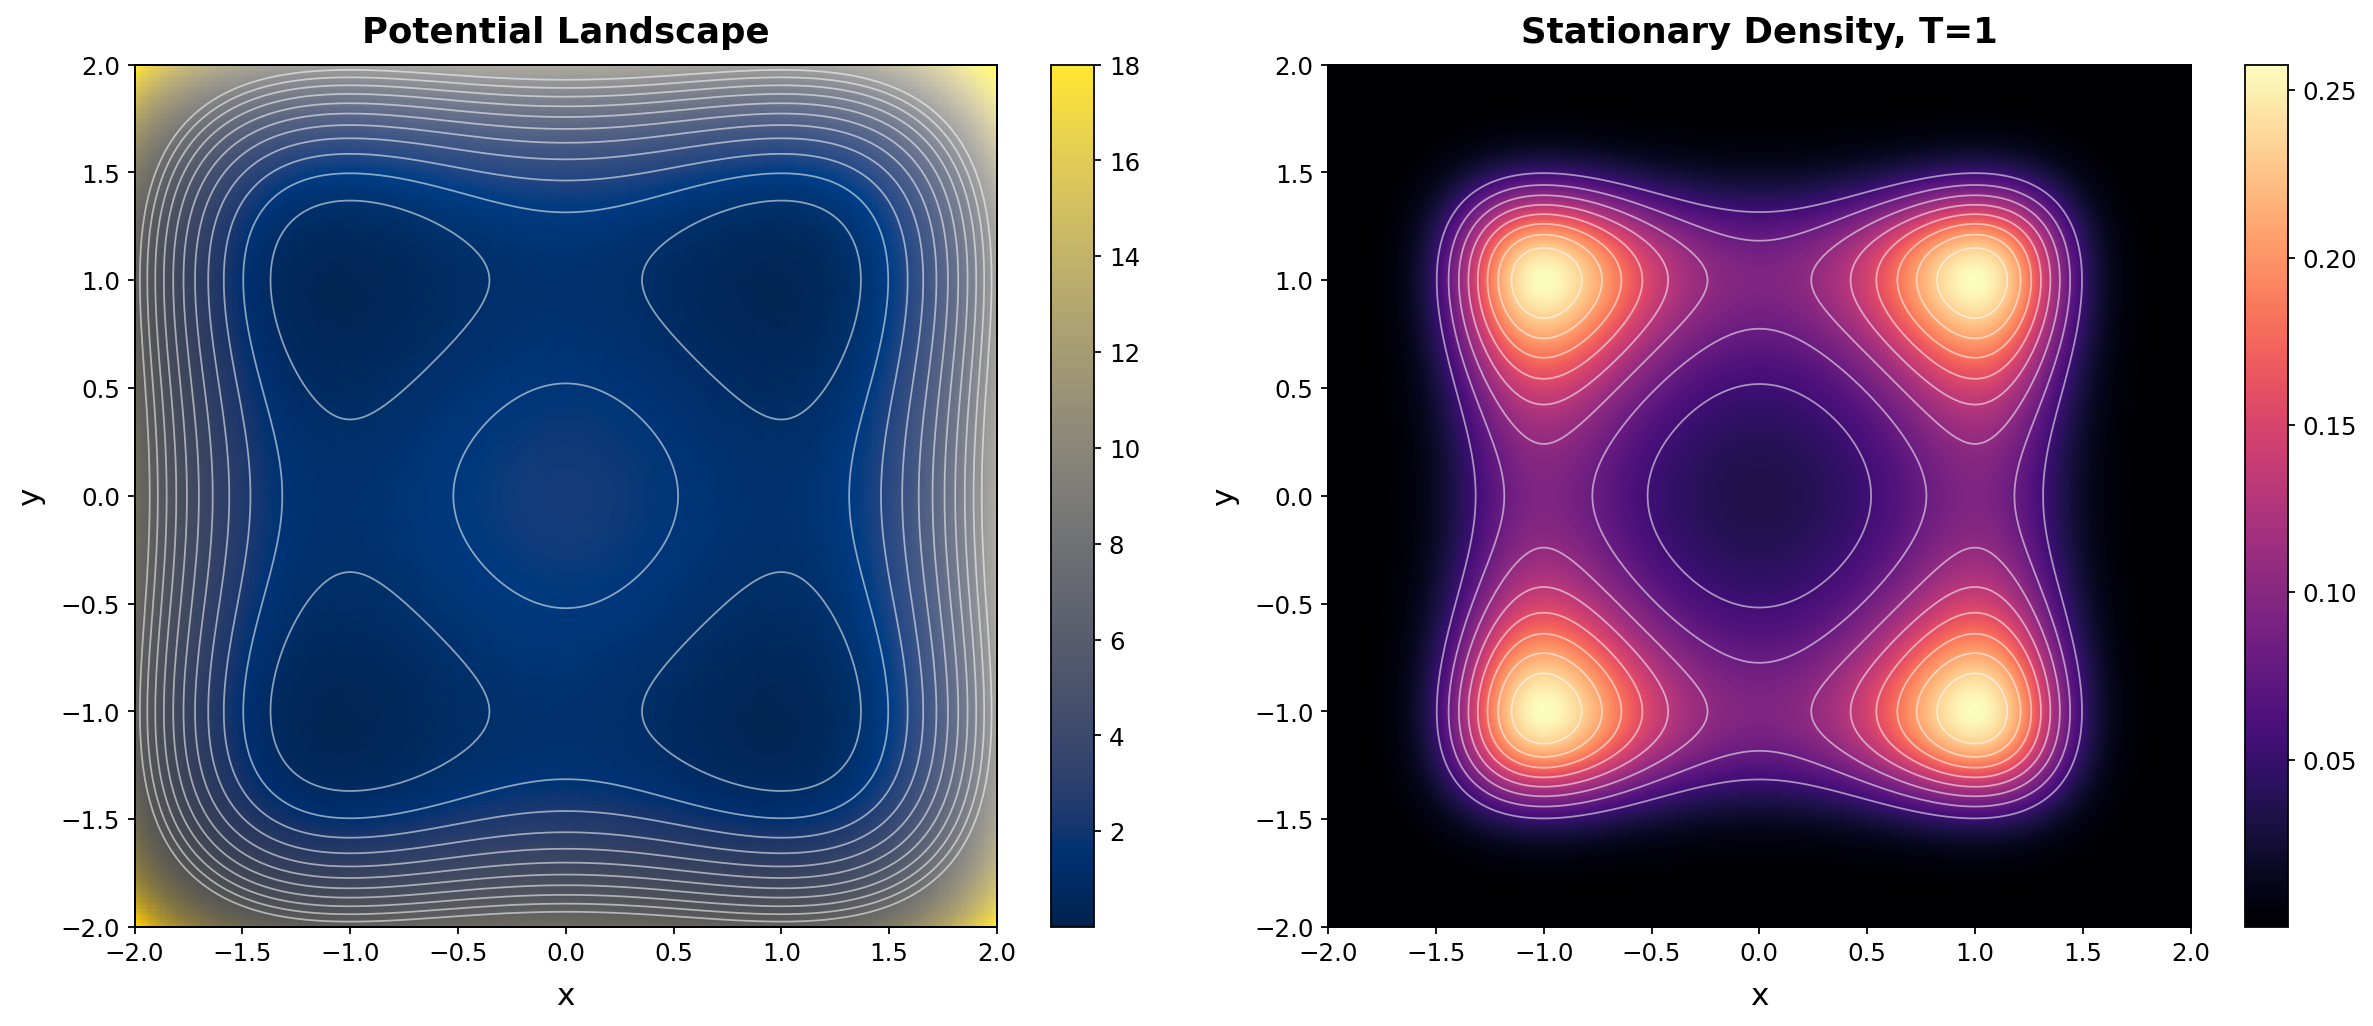

In [4]:
from matplotlib.colors import LightSource


fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_TWO_PANEL, constrained_layout=True)
fig.patch.set_facecolor('white')

# ========== Panel 1: Potential landscape as shaded relief ==========
ax1 = axes[0]
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(V_grid, cmap=plt.cm.cividis, vert_exag=0.55, blend_mode='soft')
im1 = ax1.imshow(rgb, origin='lower', extent=extent, aspect='equal')
contour_levels = np.linspace(V_grid.min(), np.percentile(V_grid, 92), 12)
ax1.contour(
    X_grid,
    Y_grid,
    V_grid,
    levels=contour_levels,
    colors='white',
    linewidths=0.8,
    alpha=0.55,
)
ax1.set_title('Potential Landscape', fontsize=FONT_TITLE, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_aspect('equal')
ax1.grid(False)

# Keep the colorbar clean: ticks only, no right-side text label.
scalar1 = plt.cm.ScalarMappable(cmap='cividis')
scalar1.set_array(V_grid)
cbar1 = fig.colorbar(scalar1, ax=ax1, fraction=0.046, pad=0.035)
cbar1.ax.tick_params(labelsize=FONT_SMALL, length=3)
cbar1.set_label('')

# ========== Panel 2: Stationary distribution as density map ==========
ax2 = axes[1]
im2 = ax2.imshow(
    density_grid,
    origin='lower',
    extent=extent,
    cmap='magma',
    aspect='equal',
    interpolation='bicubic',
)
density_levels = np.linspace(np.percentile(density_grid, 55), density_grid.max(), 9)
ax2.contour(
    X_grid,
    Y_grid,
    density_grid,
    levels=density_levels,
    colors='white',
    linewidths=0.8,
    alpha=0.55,
)
ax2.set_title(f'Stationary Density, T={potential.T}', fontsize=FONT_TITLE, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.set_aspect('equal')
ax2.grid(False)

# Keep the colorbar clean: ticks only, no right-side text label.
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.035)
cbar2.ax.tick_params(labelsize=FONT_SMALL, length=3)
cbar2.set_label('')

for ax in axes:
    ax.tick_params(axis='both', labelsize=FONT_TICK, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(0.9)

plt.show()



In [5]:
print('\n' + '='*60)
print('Potential Analysis:')
print('='*60)
print(f'Energy minima: V(+/-1, +/-1) = {potential.V(np.array([[1.0, 1.0]]))[0]:.4f}')
print(f'Central saddle: V(0, 0) = {potential.V(np.array([[0.0, 0.0]]))[0]:.4f}')
print(f'Side saddles: V(+/-1, 0) = {potential.V(np.array([[1.0, 0.0]]))[0]:.4f}')
print(f'Energy difference: DeltaV = {potential.V(np.array([[0.0, 0.0]]))[0] - potential.V(np.array([[1.0, 1.0]]))[0]:.4f}')
print(f'Temperature parameter: T = {potential.T}')
print('\nStationary distribution concentrates around four energy minima.')
print('='*60)



Potential Analysis:
Energy minima: V(+/-1, +/-1) = 0.0000
Central saddle: V(0, 0) = 2.0000
Side saddles: V(+/-1, 0) = 1.0000
Energy difference: DeltaV = 2.0000
Temperature parameter: T = 1

Stationary distribution concentrates around four energy minima.


## Verify Stationary Distribution Normalization

Check that the stationary distribution is properly normalized ($\int \pi(x) dx = 1$)

In [6]:
# Verify normalization of stationary distribution
# Numerically integrate pi(x) over the entire domain

# Use a fine grid for accurate integration
x_int = np.linspace(-3, 3, 300)
y_int = np.linspace(-3, 3, 300)
X_int, Y_int = np.meshgrid(x_int, y_int)
dx = x_int[1] - x_int[0]
dy = y_int[1] - y_int[0]

# Compute density on integration grid
density_int = potential.stationary_density(X_int, Y_int)

# Numerical integration using trapezoidal rule
integral = np.sum(density_int) * dx * dy

print("="*60)
print("Normalization Verification:")
print("="*60)
print(f"Numerical integral of pi(x) over domain: {integral:.6f}")
print(f"Expected value: 1.0")
print(f"Relative error: {abs(integral - 1.0):.2e}")
print("="*60)

if abs(integral - 1.0) < 0.01:
    print("Check: Distribution is properly normalized!")
else:
    print("Warning: Distribution normalization may be inaccurate")
    print("  (This could be due to finite integration domain)")
print("="*60)


Normalization Verification:
Numerical integral of pi(x) over domain: 1.004012
Expected value: 1.0
Relative error: 4.01e-03
Check: Distribution is properly normalized!


## Generate Training Data: (X_tar, X_tar_next)

Sample X_tar from stationary distribution $\pi(x)$, then evolve to X_tar_next using Langevin dynamics:
$$dX = -\nabla V(X)dt + \sqrt{2}dW$$

In [7]:
# ============================================================
# Step 1: Generate Time Series Trajectory using Langevin Dynamics
# ============================================================

def generate_langevin_trajectory(potential, n_samples=2500, dt=0.1, n_substeps=10, burnin=1000):
    """
    Generate a single long trajectory from Langevin dynamics
    
    SDE: dX = -gradV(X)dt + sqrt(2)dW
    
    Parameters:
        potential: FourWellPotential instance
        n_samples: Number of trajectory points to generate
        dt: Time step between saved points
        n_substeps: Number of sub-steps for numerical stability per dt
        burnin: Number of initial steps to discard (thermalization)
    
    Returns:
        trajectory: Array of shape (n_samples, 2) - consecutive time series points
    """
    # Initialize at a random position
    X_curr = np.random.randn(2) * 0.5
    
    trajectory = []
    n_total = burnin + n_samples
    dt_sub = dt / n_substeps
    
    print(f"Generating Langevin trajectory:")
    print(f"  - Total time steps: {n_total}")
    print(f"  - Burnin steps: {burnin}")
    print(f"  - Trajectory length: {n_samples}")
    print(f"  - dt = {dt}, sub-steps = {n_substeps}, dt_sub = {dt_sub:.6f}")
    
    for i in range(n_total):
        # Evolve for one time step (with n_substeps)
        for _ in range(n_substeps):
            # Drift term: -gradV(X)
            grad_V = potential.grad_V(X_curr.reshape(1, -1))
            drift = -grad_V[0]
            
            # Diffusion term: sqrt(2 * dt_sub) * Gaussian noise
            noise = np.sqrt(2.0 * dt_sub) * np.random.randn(2)
            
            # Euler-Maruyama update
            X_curr = X_curr + drift * dt_sub + noise
        
        # Store trajectory point after burnin
        if i >= burnin:
            trajectory.append(X_curr.copy())
        
        # Progress indicator
        if (i + 1) % 500 == 0:
            print(f"  Progress: {i+1}/{n_total} steps", end='\r')
    
    print(f"\n  Trajectory generation complete!")
    return np.array(trajectory)

# Generate trajectory data
n_samples = 10000
dt = 0.01  # Time step between consecutive points
n_substeps = 10  # Numerical stability
burnin = 1000  # Thermalization period

print("="*60)
print("Generating X_tar as a time series trajectory...")
print("="*60)
X_tar = generate_langevin_trajectory(potential, n_samples=n_samples, dt=dt, 
                                     n_substeps=n_substeps, burnin=burnin)
print(f"\nX_tar shape: {X_tar.shape}")
print(f"X_tar range: x in [{X_tar[:, 0].min():.2f}, {X_tar[:, 0].max():.2f}], "
      f"y in [{X_tar[:, 1].min():.2f}, {X_tar[:, 1].max():.2f}]")
print(f"\nOK: Data type: CONSECUTIVE TIME SERIES (not i.i.d. samples)")
print(f"  X_tar[i] -> X_tar[i+1] are temporally correlated")
print("="*60)


Generating X_tar as a time series trajectory...
Generating Langevin trajectory:
  - Total time steps: 11000
  - Burnin steps: 1000
  - Trajectory length: 10000
  - dt = 0.01, sub-steps = 10, dt_sub = 0.001000
  Progress: 11000/11000 steps
  Trajectory generation complete!

X_tar shape: (10000, 2)
X_tar range: x in [-1.74, 1.78], y in [-1.81, 1.81]

OK: Data type: CONSECUTIVE TIME SERIES (not i.i.d. samples)
  X_tar[i] -> X_tar[i+1] are temporally correlated


In [8]:
# ============================================================
# Step 2: Create X_tar_next from consecutive trajectory points
# ============================================================

print("="*60)
print("Creating training pairs (X_tar, X_tar_next) from trajectory...")
print("="*60)
print(f"Method: Consecutive time series points")
print(f"  X_tar[i] at time t_i")
print(f"  X_tar_next[i] at time t_(i+1) = t_i + dt")

# Simply shift the trajectory by one time step
X_tar_next = X_tar[1:].copy()  # Points from t=1 to t=2500
X_tar = X_tar[:-1].copy()      # Points from t=0 to t=2499

print(f"\nX_tar shape: {X_tar.shape}")
print(f"X_tar_next shape: {X_tar_next.shape}")
print(f"\nTraining pairs: {X_tar.shape[0]}")
print(f"Time lag: dt = {dt}")
print(f"\nOK: Each pair (X_tar[i], X_tar_next[i]) represents:")
print(f"  one step evolution under Langevin dynamics")
print("="*60)


Creating training pairs (X_tar, X_tar_next) from trajectory...
Method: Consecutive time series points
  X_tar[i] at time t_i
  X_tar_next[i] at time t_(i+1) = t_i + dt

X_tar shape: (9999, 2)
X_tar_next shape: (9999, 2)

Training pairs: 9999
Time lag: dt = 0.01

OK: Each pair (X_tar[i], X_tar_next[i]) represents:
  one step evolution under Langevin dynamics


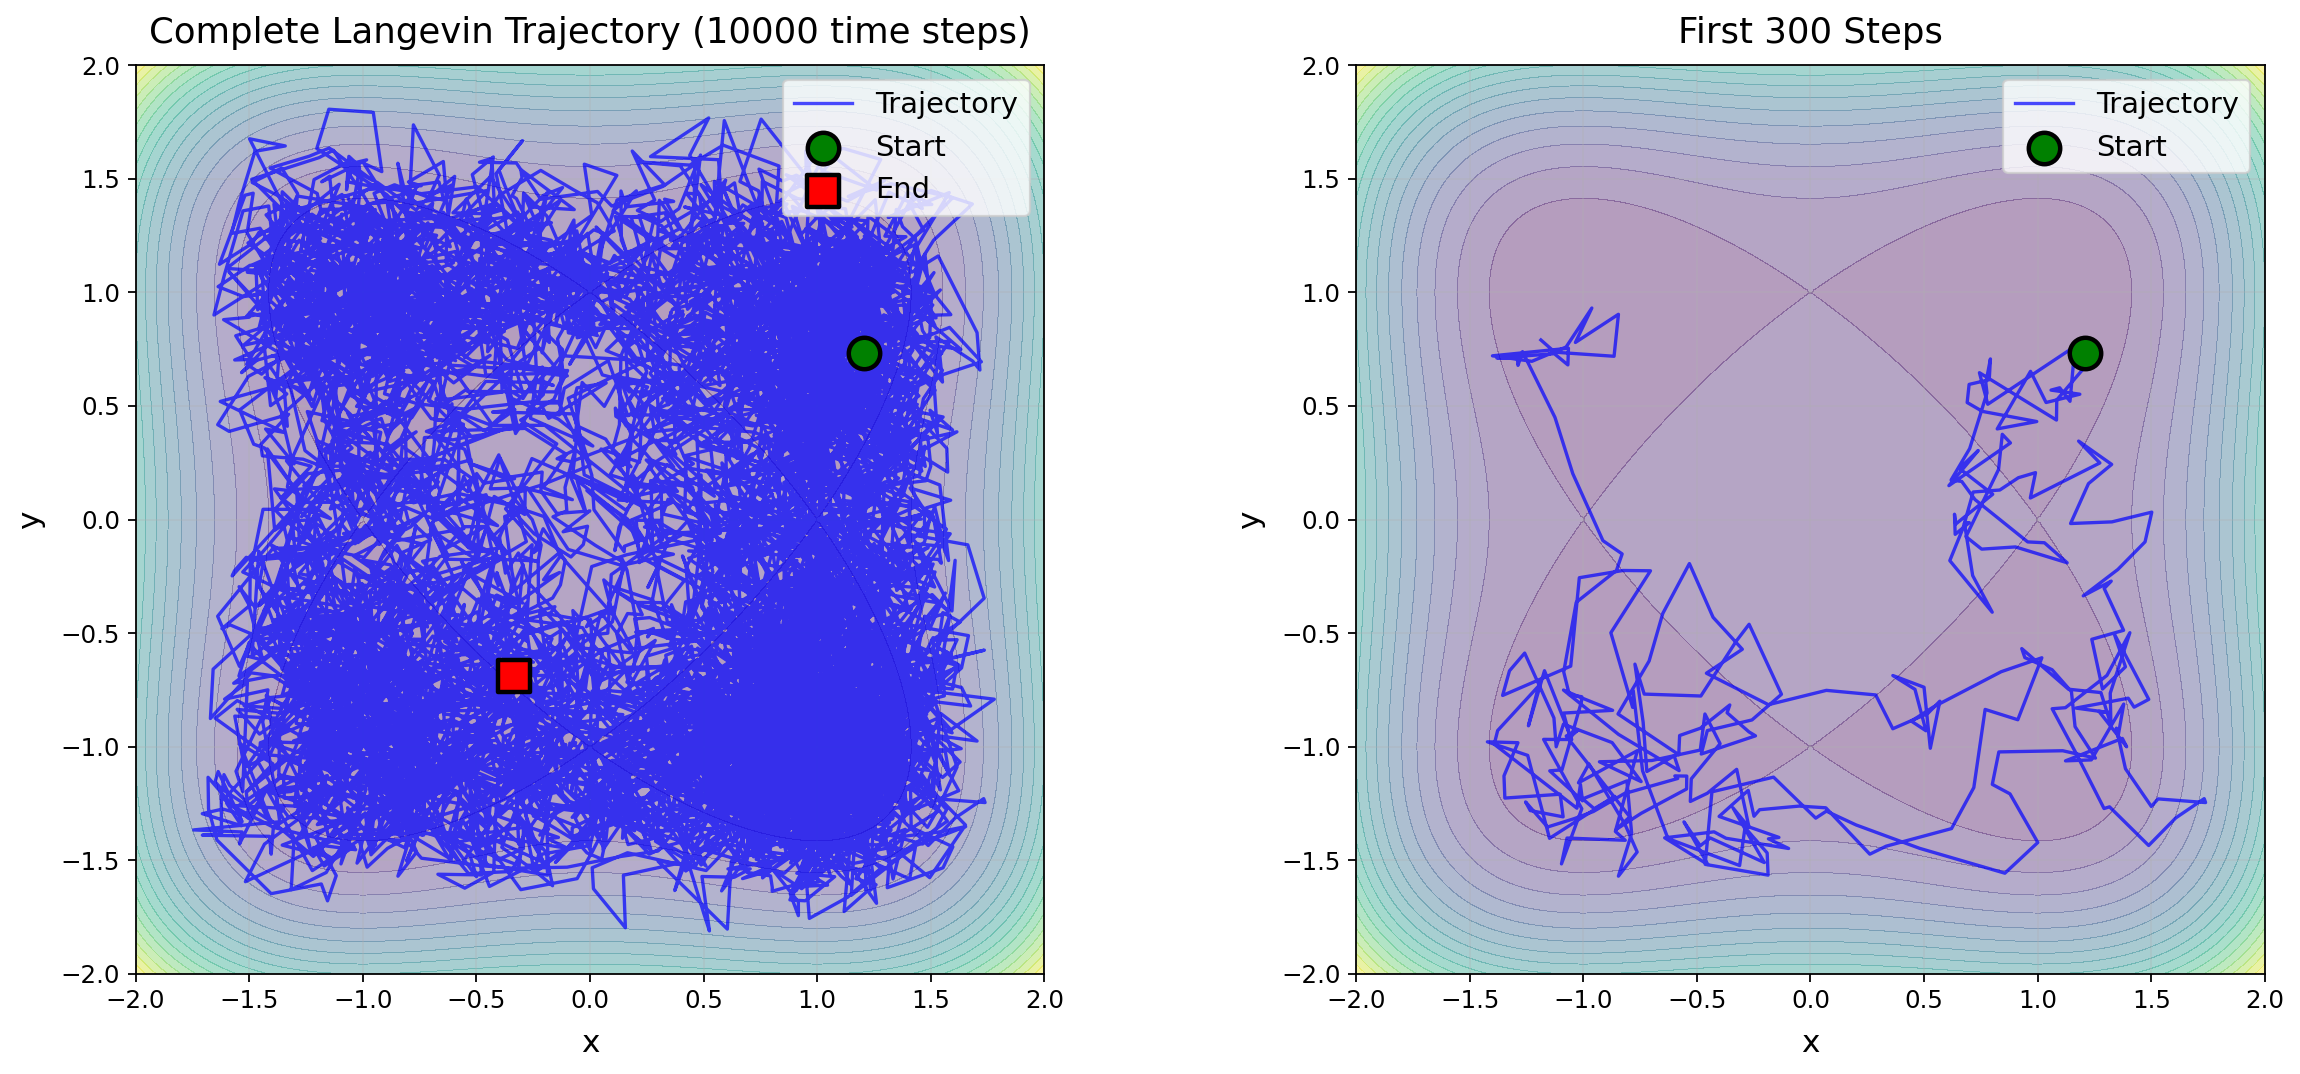

In [9]:
# ============================================================
# Visualize Time Series Trajectory
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_TWO_PANEL_TALL)

# ========== Subplot 1: Complete Trajectory ==========
ax1 = axes[0]

# Plot potential contour as background
contourf1 = ax1.contourf(X_grid, Y_grid, V_grid, levels=20, cmap='viridis', alpha=0.4)

# Plot the trajectory as a simple blue line
ax1.plot(X_tar[:, 0], X_tar[:, 1], 'b-', linewidth=1.5, alpha=0.7, label='Trajectory')

# Mark start and end points
ax1.scatter(X_tar[0, 0], X_tar[0, 1], c='green', s=200, marker='o', 
           edgecolors='black', linewidth=2, label='Start', zorder=10)
ax1.scatter(X_tar[-1, 0], X_tar[-1, 1], c='red', s=200, marker='s', 
           edgecolors='black', linewidth=2, label='End', zorder=10)

ax1.set_xlabel('x', fontsize=FONT_LABEL)
ax1.set_ylabel('y', fontsize=FONT_LABEL)
ax1.set_title(f'Complete Langevin Trajectory ({len(X_tar)+1} time steps)', fontsize=FONT_TITLE)
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_aspect('equal')
ax1.legend(loc='upper right', fontsize=FONT_BASE)
ax1.grid(True, alpha=0.3)

# ========== Subplot 2: First 300 Steps ==========
ax2 = axes[1]
n_zoom = min(300, len(X_tar))

# Plot potential contour as background
contourf2 = ax2.contourf(X_grid, Y_grid, V_grid, levels=20, cmap='viridis', alpha=0.4)

# Plot the trajectory as a simple blue line (first 300 steps)
ax2.plot(X_tar[:n_zoom, 0], X_tar[:n_zoom, 1], 'b-', linewidth=1.5, alpha=0.7, label='Trajectory')

# Mark start point only
ax2.scatter(X_tar[0, 0], X_tar[0, 1], c='green', s=200, marker='o', 
           edgecolors='black', linewidth=2, label='Start', zorder=10)

ax2.set_xlabel('x', fontsize=FONT_LABEL)
ax2.set_ylabel('y', fontsize=FONT_LABEL)
ax2.set_title(f'First {n_zoom} Steps', fontsize=FONT_TITLE)
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.set_aspect('equal')
ax2.legend(loc='upper right', fontsize=FONT_BASE)
ax2.grid(True, alpha=0.3)

fig.tight_layout(pad=LAYOUT_PAD)
plt.show()


In [10]:
print("\n" + "="*60)
print("Time Series Trajectory")
print("="*60)
print(f"Total trajectory length: {len(X_tar)+1} time steps")
print(f"Time interval: dt = {dt}")
print(f"Total simulation time: {len(X_tar) * dt:.1f} time units")
print("="*60)



Time Series Trajectory
Total trajectory length: 10000 time steps
Time interval: dt = 0.01
Total simulation time: 100.0 time units


## Archived Exploratory Code

This notebook used to contain a large commented-out exploratory implementation here.
It has been removed from the executable path so the main experiment is easier to rerun and maintain.

In [11]:
# ============================================================
# Diagnostic: Check Training Data Distribution Across 4 Wells
# ============================================================

well_centers = WELL_CENTERS
well_radius = WELL_RADIUS
well_labels = WELL_LABELS

print("="*70)
print("TRAINING DATA DISTRIBUTION IN 4 WELLS")
print("="*70)

training_basin_counts, outside_wells = compute_well_counts(X_tar, well_centers, well_radius)
total_samples = len(X_tar)
for label, count in zip(well_labels, training_basin_counts):
    percentage = 100.0 * count / total_samples
    print(f"{label:20s}: {count:5d} samples ({percentage:5.1f}%)")

total_in_wells = sum(training_basin_counts)

print("-"*70)
print(f"{'Total in wells':20s}: {total_in_wells:5d} samples ({100.0*total_in_wells/total_samples:5.1f}%)")
print(f"{'Outside wells':20s}: {outside_wells:5d} samples ({100.0*outside_wells/total_samples:5.1f}%)")
print(f"{'Total samples':20s}: {total_samples:5d}")
print("="*70)

TRAINING DATA DISTRIBUTION IN 4 WELLS
Well 1 (-1,-1)      :   683 samples (  6.8%)
Well 2 (-1,+1)      :   650 samples (  6.5%)
Well 3 (+1,-1)      :  1773 samples ( 17.7%)
Well 4 (+1,+1)      :   876 samples (  8.8%)
----------------------------------------------------------------------
Total in wells      :  3982 samples ( 39.8%)
Outside wells       :  6017 samples ( 60.2%)
Total samples       :  9999


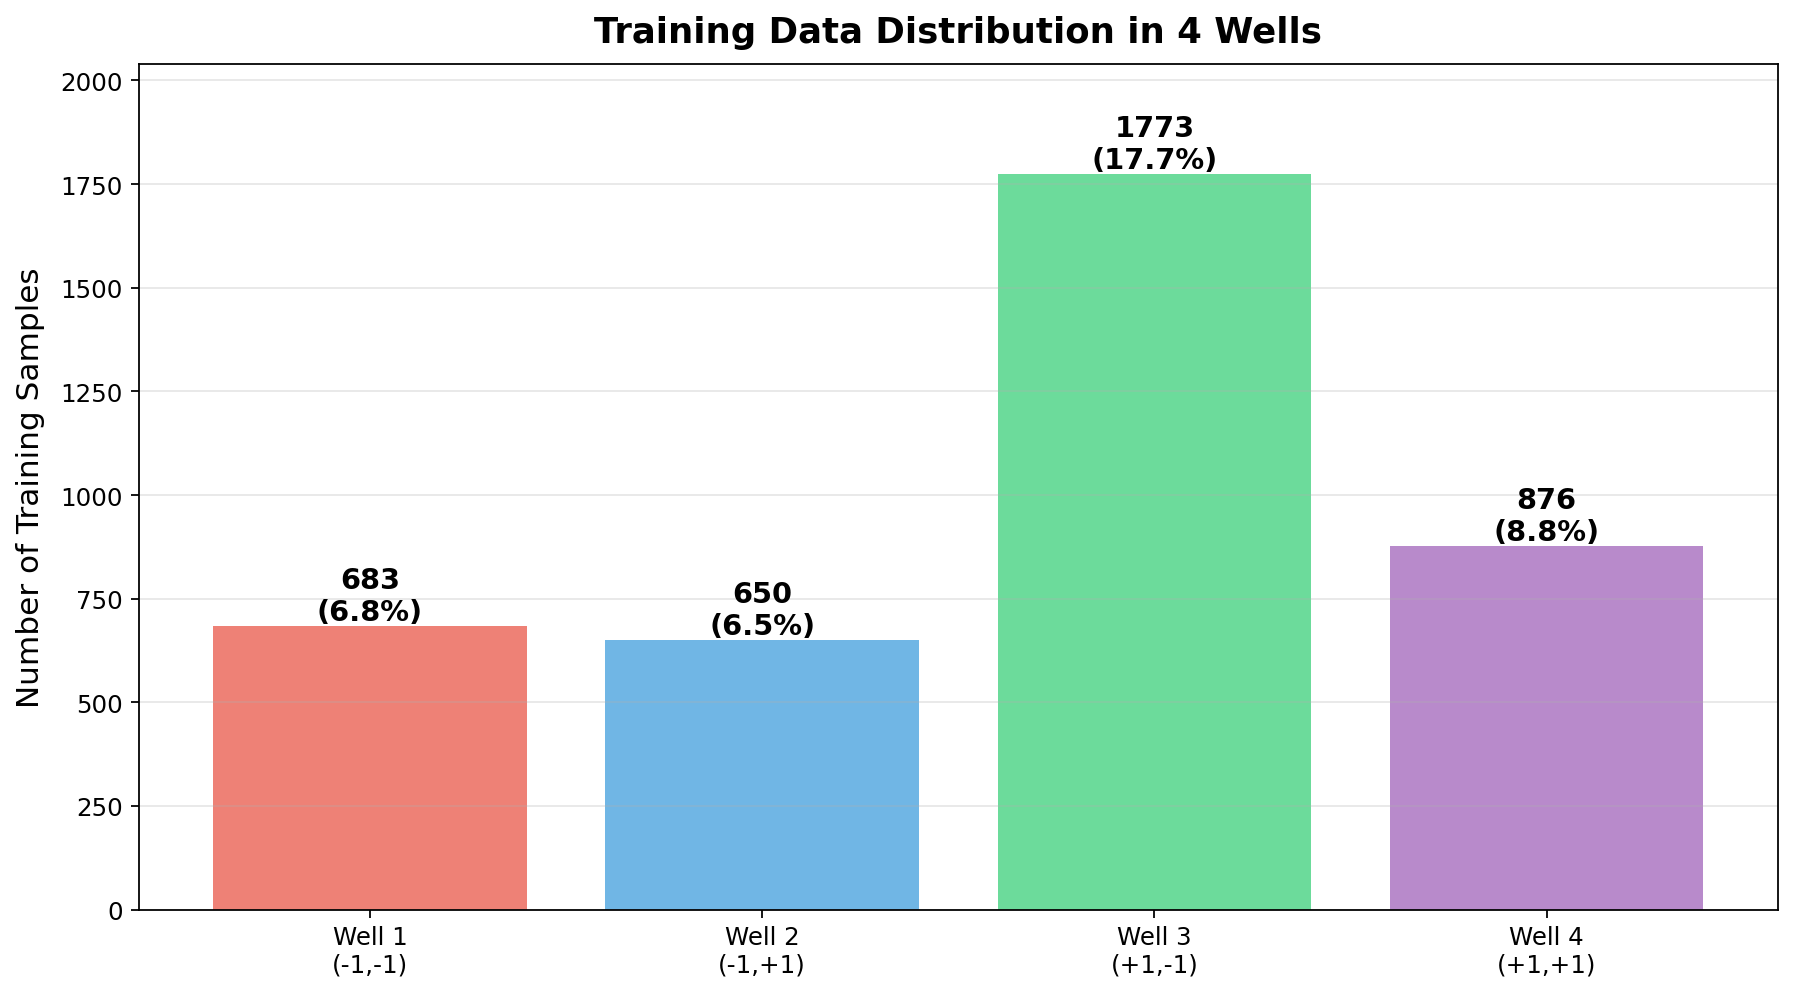

In [12]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)
x_positions = np.arange(len(well_labels))
bars = ax.bar(x_positions, training_basin_counts, color=WELL_COLORS, alpha=0.7)

for bar, count in zip(bars, training_basin_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({100.0*count/total_samples:.1f}%)',
            ha='center', va='bottom', fontsize=FONT_BASE, fontweight='bold')

ax.set_ylabel('Number of Training Samples', fontsize=FONT_LABEL)
ax.set_title('Training Data Distribution in 4 Wells', fontsize=FONT_TITLE, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels(WELL_LABELS_SHORT, fontsize=FONT_TICK)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(training_basin_counts) * 1.15)

fig.tight_layout(pad=LAYOUT_PAD)
plt.show()

In [13]:
# Check imbalance
max_count = max(training_basin_counts)
min_count = min(training_basin_counts)
imbalance_ratio = max_count / (min_count + 1e-10)

print(f"\nWARNING:  IMBALANCE ANALYSIS:")
print(f"   Max samples in one well: {max_count}")
print(f"   Min samples in one well: {min_count}")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}x")

if imbalance_ratio > 3.0:
    print(f"\nWARNING: WARNING: Severe imbalance detected! (ratio > 3x)")
    print(f"   This likely explains why some wells don't get particles.")
    print(f"   Solution: Increase simulation time or re-generate trajectory.")
elif imbalance_ratio > 1.5:
    print(f"\nCAUTION: CAUTION: Moderate imbalance detected (ratio > 1.5x)")
    print(f"   Some wells may attract fewer particles.")
else:
    print(f"\nOK: Data distribution is reasonably balanced.")



   Max samples in one well: 1773
   Min samples in one well: 650
   Imbalance ratio: 2.73x

CAUTION: CAUTION: Moderate imbalance detected (ratio > 1.5x)
   Some wells may attract fewer particles.


## Archived Exploratory Code

This notebook used to contain a large commented-out exploratory implementation here.
It has been removed from the executable path so the main experiment is easier to rerun and maintain.

## Archived Exploratory Code

This notebook used to contain a large commented-out exploratory implementation here.
It has been removed from the executable path so the main experiment is easier to rerun and maintain.

In [14]:
# ============================================================
# DM Method: Diffusion Maps for Langevin Generator Construction
# (PyTorch implementation; uses the selected CUDA device when available)
# ============================================================

# Device is selected once in the setup cell and reused here.

# Preconditions
if 'X_tar' not in globals() or 'X_tar_next' not in globals():
    raise RuntimeError('X_tar and X_tar_next must be computed before running DM method.')

n = X_tar.shape[0]

# The dense n x n NumPy copies below are only useful for ad-hoc inspection.
# Keeping them off avoids several extra 10000 x 10000 host transfers.
keep_dm_dense_numpy_arrays = False

# Only the leading DM modes are used downstream, so avoid a full 10000 x 10000 SVD by default.
dm_use_truncated_svd = True
dm_svd_rank = min(1000, n)
dm_svd_niter = 2
dm_eigenvalues_to_print = 50

dm_total_stages = 8 if keep_dm_dense_numpy_arrays else 7
# Keep this cell print-only: tqdm's elapsed clock is misleading for blocking dense SVD calls.
dm_stage_bar = None
dm_stage_start = time.monotonic()

def mark_dm_stage(message):
    elapsed = format_seconds(time.monotonic() - dm_stage_start)
    if dm_stage_bar is not None:
        dm_stage_bar.update(1)
        dm_stage_bar.set_postfix(stage=message, elapsed=elapsed, refresh=True)
    else:
        print(f'[DM Method] {message} ({elapsed})')

def sync_compute_device():
    if device_compute.type == 'cuda':
        torch.cuda.synchronize(device_compute)

def run_dm_timed_step(description, func):
    """Time a single blocking torch call; PyTorch does not expose SVD progress."""
    sync_compute_device()
    print(f'{description}: started...')
    start = time.monotonic()
    try:
        result = func()
        sync_compute_device()
        return result
    finally:
        elapsed = format_seconds(time.monotonic() - start)
        print(f'{description}: finished in {elapsed}')

# Move data to the selected torch device
X_tar_gpu = torch.tensor(X_tar, dtype=torch.float64, device=device_compute)
mark_dm_stage('data on device')

# Step 1: Build Gaussian kernel on the selected torch device
sq_tar_gpu = torch.sum(X_tar_gpu ** 2, dim=1)
H_gpu = sq_tar_gpu[:, None] + sq_tar_gpu[None, :] - 2 * (X_tar_gpu @ X_tar_gpu.T)
epsilon = float((torch.median(H_gpu) * (c_epsilon / np.log(n + 1))).detach().cpu().item())
print(f"DM Method: Computed adaptive epsilon = {epsilon:.6f} (using c_epsilon = {c_epsilon})")
mark_dm_stage('pairwise distances + epsilon')

# Gaussian kernel on the selected torch device
data_kernel_gpu = torch.exp(-H_gpu / (2 * epsilon))
mark_dm_stage('Gaussian kernel')

# Step 2: Anisotropic normalization on the selected torch device
p_x_gpu = torch.sqrt(torch.sum(data_kernel_gpu, dim=1))
p_y_gpu = p_x_gpu.clone()
data_kernel_norm_gpu = data_kernel_gpu / p_x_gpu[:, None] / p_y_gpu[None, :]
D_y_gpu = torch.sum(data_kernel_norm_gpu, dim=0)
mark_dm_stage('anisotropic normalization')

# Step 3: Random-walk symmetric normalization on the selected torch device
rw_kernel_gpu = data_kernel_norm_gpu / D_y_gpu[:, None]
mark_dm_stage('random-walk kernel')

# Step 4: SVD on the selected torch device to get spectrum
# The randomized truncated SVD is much cheaper when only leading modes are needed.
if dm_use_truncated_svd and dm_svd_rank < min(rw_kernel_gpu.shape):
    print(f'DM Method: using truncated randomized SVD with rank={dm_svd_rank}, niter={dm_svd_niter}')
    phi_gpu, s_gpu, _ = run_dm_timed_step(
        'DM Method truncated SVD',
        lambda: torch.svd_lowrank(rw_kernel_gpu, q=dm_svd_rank, niter=dm_svd_niter),
    )
else:
    print('DM Method: using full SVD')
    phi_gpu, s_gpu, _ = run_dm_timed_step(
        'DM Method full SVD',
        lambda: torch.linalg.svd(rw_kernel_gpu, full_matrices=False),
    )
sort_idx_gpu = torch.argsort(s_gpu, descending=True)
s_gpu = s_gpu[sort_idx_gpu]
phi_gpu = phi_gpu[:, sort_idx_gpu]
lambda_ns = s_gpu.cpu().numpy()  # Singular values (eigenvalues of symmetric matrix)
phi = phi_gpu.cpu().numpy()
mark_dm_stage('SVD + host copy')

# Step 5: Construct generator eigenvalues
lambda_gen_dm = (lambda_ns - 1.0) / epsilon

# Step 6: Build inverse generator weights (for KSWGD)
tol = 1e-6
lambda_ns_inv = np.zeros_like(lambda_ns)
mask = lambda_ns >= tol
lambda_ns_inv[mask] = epsilon / (lambda_ns[mask] + 0.001)

# Store results for KSWGD
eigvals_K_dm = lambda_ns.copy()
eigvecs_K_dm = phi.copy()
lambda_gen_full = lambda_gen_dm.copy()
mark_dm_stage('generator weights')

D_y = D_y_gpu.cpu().numpy()
p_x = p_x_gpu.cpu().numpy()
p_y = p_y_gpu.cpu().numpy()
if keep_dm_dense_numpy_arrays:
    H = H_gpu.cpu().numpy()
    data_kernel = data_kernel_gpu.cpu().numpy()
    data_kernel_norm = data_kernel_norm_gpu.cpu().numpy()
    rw_kernel = rw_kernel_gpu.cpu().numpy()
    mark_dm_stage('dense NumPy compatibility arrays')
else:
    H = data_kernel = data_kernel_norm = rw_kernel = None
    mark_dm_stage('essential host arrays')

if dm_stage_bar is not None:
    dm_stage_bar.close()

# Clean up accelerator memory when CUDA is active
del X_tar_gpu, sq_tar_gpu, H_gpu, data_kernel_gpu, p_x_gpu, p_y_gpu
del data_kernel_norm_gpu, D_y_gpu, rw_kernel_gpu, phi_gpu, s_gpu

if device_compute.type == 'cuda':
    torch.cuda.empty_cache()

print(f"Computed DM spectral modes: {len(eigvals_K_dm)} of {n} total")
print(f"Max magnitude: {np.max(np.abs(eigvals_K_dm)):.4f}")
print(f"Computed eigenvalues outside unit circle: {np.sum(np.abs(eigvals_K_dm) > 1)}")

# Sort eigenvalues by real part (descending order)
sorted_real_dm = np.sort(eigvals_K_dm.real)[::-1]

print("\n" + "="*50)
n_print_eigs = min(dm_eigenvalues_to_print, len(sorted_real_dm))
print(f"Top {n_print_eigs} eigenvalues (Real part, sorted from large to small):")
print("="*50)
for i, real_part in enumerate(sorted_real_dm[:n_print_eigs]):
    print(f"{i+1:3d}. {real_part:+.6f}")
if len(sorted_real_dm) > n_print_eigs:
    print(f"... omitted {len(sorted_real_dm) - n_print_eigs} smaller computed eigenvalues")

[DM Method] data on device (00:00)
DM Method: Computed adaptive epsilon = 0.146556 (using c_epsilon = 0.5)
[DM Method] pairwise distances + epsilon (00:00)
[DM Method] Gaussian kernel (00:00)
[DM Method] anisotropic normalization (00:00)
[DM Method] random-walk kernel (00:00)
DM Method: using truncated randomized SVD with rank=1000, niter=2
DM Method truncated SVD: started...
DM Method truncated SVD: finished in 00:03
[DM Method] SVD + host copy (00:04)
[DM Method] generator weights (00:04)
[DM Method] essential host arrays (00:04)
Computed DM spectral modes: 1000 of 9999 total
Max magnitude: 1.0029
Computed eigenvalues outside unit circle: 1

Top 50 eigenvalues (Real part, sorted from large to small):
  1. +1.002871
  2. +0.956837
  3. +0.944829
  4. +0.898828
  5. +0.648912
  6. +0.613979
  7. +0.598922
  8. +0.581885
  9. +0.429994
 10. +0.414469
 11. +0.411558
 12. +0.392379
 13. +0.375508
 14. +0.283237
 15. +0.278550
 16. +0.265573
 17. +0.251302
 18. +0.250389
 19. +0.244518
 20

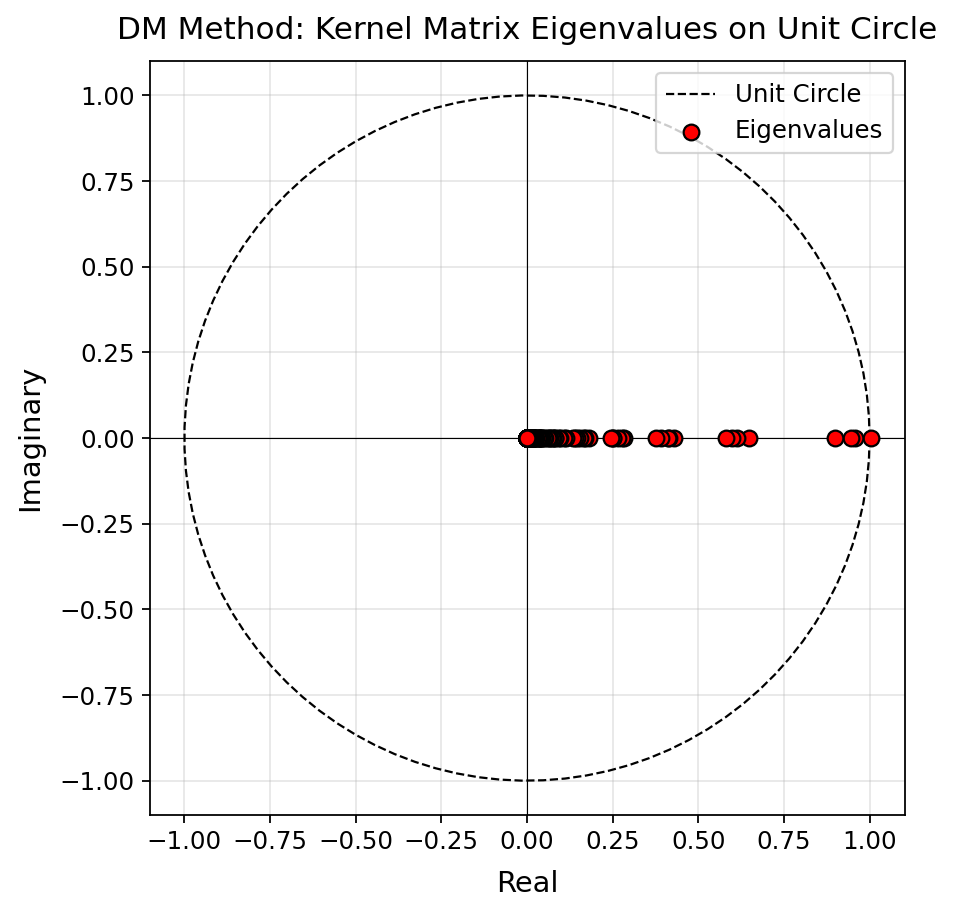

In [15]:
# ============================================================
# Visualization: DM eigenvalues on the unit circle
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)

# Plot unit circle
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1, label='Unit Circle')

# Plot eigenvalues
ax.scatter(eigvals_K_dm.real, eigvals_K_dm.imag, c='red', s=50, marker='o', 
           edgecolors='black', linewidths=1, label='Eigenvalues', zorder=3)

# Set equal aspect ratio and labels
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Real', fontsize=FONT_BASE)
ax.set_ylabel('Imaginary', fontsize=FONT_BASE)
ax.set_title('DM Method: Kernel Matrix Eigenvalues on Unit Circle', fontsize=FONT_LABEL)
ax.legend(fontsize=FONT_SMALL)

fig.tight_layout(pad=LAYOUT_PAD)
plt.show()


## DMPS Analysis: KL Divergence & Boltzmann Sampling

1. Track KL divergence between particle distribution and true Boltzmann distribution during gradient descent
2. Sample from Boltzmann distribution $\pi(x) \propto e^{-V(x)}$ to show spread around well bottoms

In [16]:
# ============================================================
# Helpers: KL Divergence, kernels, and shared KSWGD runner
# ============================================================

from scipy.stats import gaussian_kde


def sample_from_boltzmann(potential, n_samples, x_range=(-2, 2), y_range=(-2, 2), n_mcmc=50000, burnin=5000):
    """Sample from Boltzmann distribution pi(x) proportional to exp(-V(x)/T)."""
    samples = []
    x_curr = np.array([0.0, 0.0])
    proposal_std = 0.5

    for i in range(n_mcmc + burnin):
        x_prop = x_curr + proposal_std * np.random.randn(2)
        if x_range[0] <= x_prop[0] <= x_range[1] and y_range[0] <= x_prop[1] <= y_range[1]:
            V_curr = potential.V(x_curr.reshape(1, -1))[0]
            V_prop = potential.V(x_prop.reshape(1, -1))[0]
            log_alpha = -(V_prop - V_curr) / potential.T
            if np.log(np.random.rand()) < log_alpha:
                x_curr = x_prop
        if i >= burnin:
            samples.append(x_curr.copy())

    samples = np.array(samples)
    indices = np.random.choice(len(samples), size=n_samples, replace=False)
    return samples[indices]


def compute_kl_divergence_kde(particles, potential, x_range=(-2, 2), y_range=(-2, 2), n_grid=50):
    """Compute grid-approximated D_KL(q || pi), estimating q by KDE."""
    x_eval = np.linspace(x_range[0], x_range[1], n_grid)
    y_eval = np.linspace(y_range[0], y_range[1], n_grid)
    X_eval, Y_eval = np.meshgrid(x_eval, y_eval)
    positions = np.vstack([X_eval.ravel(), Y_eval.ravel()])

    dx = (x_range[1] - x_range[0]) / n_grid
    dy = (y_range[1] - y_range[0]) / n_grid

    V_grid = potential.V(X_eval, Y_eval)
    pi_unnorm = np.exp(-V_grid / potential.T)
    Z = np.sum(pi_unnorm) * dx * dy
    pi_flat = (pi_unnorm / Z).ravel()

    try:
        kde = gaussian_kde(particles.T, bw_method='scott')
        q_flat = kde(positions)
        q_flat = q_flat / (np.sum(q_flat) * dx * dy)
    except Exception:
        return 100.0

    eps = 1e-10
    q_safe = np.maximum(q_flat, eps)
    pi_safe = np.maximum(pi_flat, eps)
    kl = np.sum(q_flat * np.log(q_safe / pi_safe)) * dx * dy
    return max(kl, 0)


def evaluate_kernel_at_points_gpu(X_query, X_data, epsilon_val, p_x_val, D_y_val):
    """Torch version of normalized kernel evaluation (using float64 for precision)."""
    if not isinstance(X_query, torch.Tensor):
        X_query = torch.from_numpy(X_query).double().to(device_compute)
    if not isinstance(X_data, torch.Tensor):
        X_data = torch.from_numpy(X_data).double().to(device_compute)
    if not isinstance(p_x_val, torch.Tensor):
        p_x_val = torch.from_numpy(p_x_val).double().to(device_compute)
    if not isinstance(D_y_val, torch.Tensor):
        D_y_val = torch.from_numpy(D_y_val).double().to(device_compute)

    sq_query = torch.sum(X_query ** 2, dim=1)
    sq_data = torch.sum(X_data ** 2, dim=1)
    H = sq_query[:, None] + sq_data[None, :] - 2 * (X_query @ X_data.T)
    K_raw = torch.exp(-H / (2 * epsilon_val))
    p_query = torch.sqrt(torch.sum(K_raw, dim=1))
    K_norm = K_raw / p_query[:, None] / p_x_val[None, :]
    return K_norm / D_y_val[None, :]


def compute_kernel_gradient_gpu(X_query, X_data, epsilon_val, p_x_val):
    """Torch version of kernel gradient computation (using float64 for precision)."""
    if not isinstance(X_query, torch.Tensor):
        X_query = torch.from_numpy(X_query).double().to(device_compute)
    if not isinstance(X_data, torch.Tensor):
        X_data = torch.from_numpy(X_data).double().to(device_compute)
    if not isinstance(p_x_val, torch.Tensor):
        p_x_val = torch.from_numpy(p_x_val).double().to(device_compute)

    diff = X_query[:, None, :] - X_data[None, :, :]
    sq_query = torch.sum(X_query ** 2, dim=1)
    sq_data = torch.sum(X_data ** 2, dim=1)
    H = sq_query[:, None] + sq_data[None, :] - 2 * (X_query @ X_data.T)
    K_raw = torch.exp(-H / (2 * epsilon_val))
    grad_K_raw = -K_raw[:, :, None] * diff / epsilon_val
    p_query = torch.sqrt(torch.sum(K_raw, dim=1, keepdim=True))
    return grad_K_raw / p_query[:, :, None] / p_x_val[None, :, None]


def run_kswgd_with_spectrum(
    method_name,
    X_init,
    X_train_gpu,
    p_x_train_gpu,
    D_y_train_gpu,
    epsilon_val,
    eigvecs_on_train,
    lambda_gen_full_values,
    eigvals_for_mode_selection,
    fixed_mode_count,
    eig_threshold_value,
    n_skip_modes,
    n_iter,
    step_size,
    record_every,
    potential_obj,
):
    """Run the shared KSWGD update loop for either DMPS or SDMD spectra."""
    if eigvals_for_mode_selection is None:
        eigvals_for_mode_selection = lambda_gen_full_values
    eigvals_after_skip = np.asarray(eigvals_for_mode_selection)[n_skip_modes:]

    if fixed_mode_count is not None:
        k_modes_local = min(fixed_mode_count, len(eigvals_after_skip))
        print(f"Using fixed mode count: {k_modes_local}")
    else:
        valid_mask = eigvals_after_skip.real > eig_threshold_value
        k_modes_local = int(np.sum(valid_mask))
        print(f"Using threshold {eig_threshold_value}, got {k_modes_local} modes")

    mode_start = n_skip_modes
    mode_end = mode_start + k_modes_local
    print(f"{method_name} modes: {k_modes_local} (from {mode_start+1} to {mode_end})")

    lambda_gen_selected = lambda_gen_full_values[mode_start:mode_end]
    lambda_gen_inv_selected = np.zeros(k_modes_local, dtype=complex)
    mask_nonzero = np.abs(lambda_gen_selected) > 1e-6
    lambda_gen_inv_selected[mask_nonzero] = 1.0 / lambda_gen_selected[mask_nonzero]

    eigvecs_selected_gpu = torch.from_numpy(
        np.real(eigvecs_on_train[:, mode_start:mode_end])
    ).double().to(device_compute)
    lambda_gen_inv_selected_gpu = torch.from_numpy(lambda_gen_inv_selected).to(device_compute).to(torch.complex128)

    n_particles_local = X_init.shape[0]
    n_records_local = n_iter // record_every + 1
    X_traj = np.zeros((n_particles_local, 2, n_iter + 1))
    X_traj[:, :, 0] = X_init.copy()

    metrics = {
        'steps': [],
        'well_coverage': [],
        'avg_potential': [],
        'movement_rate': [],
    }

    coverage_0, avg_V_0, _ = compute_particle_metrics(X_traj[:, :, 0], potential_obj)
    metrics['steps'].append(0)
    metrics['well_coverage'].append(coverage_0)
    metrics['avg_potential'].append(avg_V_0)
    metrics['movement_rate'].append(0.0)

    print(f"Torch tensors prepared for {method_name} on: {device_compute}")
    print(f"Particles: {n_particles_local}")
    print(f"Iterations: {n_iter}")
    print(f"Recording interval: {record_every} steps")
    print(f"Total records: {n_records_local}")
    print(f"\nInitial state (step 0):")
    print(f"  Well coverage: {coverage_0:.2f}%")
    print(f"  Avg potential: {avg_V_0:.4f}")

    iter_bar = progress_range(
        range(n_iter),
        desc=method_name,
        unit='iter',
        dynamic_ncols=True,
        mininterval=1.0,
    )

    for t in iter_bar:
        X_curr = X_traj[:, :, t]
        X_curr_gpu = torch.from_numpy(X_curr).double().to(device_compute)

        K_curr_gpu = evaluate_kernel_at_points_gpu(
            X_curr_gpu, X_train_gpu, epsilon_val, p_x_train_gpu, D_y_train_gpu
        )
        c_gpu = eigvecs_selected_gpu.T @ K_curr_gpu.T
        c_inv_gpu = lambda_gen_inv_selected_gpu[:, None] * c_gpu.to(torch.complex128)
        f_inv_gpu = eigvecs_selected_gpu @ c_inv_gpu.real

        grad_K_gpu = compute_kernel_gradient_gpu(X_curr_gpu, X_train_gpu, epsilon_val, p_x_train_gpu)
        grad_driving_gpu = torch.zeros((n_particles_local, 2), dtype=torch.float64, device=device_compute)
        for d_idx in range(2):
            grad_driving_gpu[:, d_idx] = torch.sum(grad_K_gpu[:, :, d_idx] * f_inv_gpu.T, dim=1)

        X_next_gpu = X_curr_gpu - step_size * grad_driving_gpu
        X_traj[:, :, t + 1] = X_next_gpu.cpu().numpy()

        if (t + 1) % record_every == 0:
            X_prev = X_traj[:, :, t]
            X_next = X_traj[:, :, t + 1]
            coverage, avg_V, movement = compute_particle_metrics(X_next, potential_obj, X_prev)
            metrics['steps'].append(t + 1)
            metrics['well_coverage'].append(coverage)
            metrics['avg_potential'].append(avg_V)
            metrics['movement_rate'].append(movement)

            if hasattr(iter_bar, 'set_postfix'):
                iter_bar.set_postfix(
                    coverage=f'{coverage:.1f}%',
                    avg_V=f'{avg_V:.3f}',
                    movement=f'{movement:.2e}',
                    refresh=False,
                )
        elif not hasattr(iter_bar, 'set_postfix') and ((t + 1) % 500 == 0 or t == 0):
            print(f"\r  [{method_name}] Iteration {t+1}/{n_iter}  ", end='', flush=True)

    print()
    print(f"{method_name} iteration complete!")

    for key in ['steps', 'well_coverage', 'avg_potential', 'movement_rate']:
        metrics[key] = np.array(metrics[key])

    return X_traj, metrics, k_modes_local, n_records_local


print("Helper functions initialized.")
print("Torch kernel helper functions initialized.")
print("Shared KSWGD runner initialized.")

Helper functions initialized.
Torch kernel helper functions initialized.
Shared KSWGD runner initialized.


## Convergence Analysis: DMPS with Metrics Tracking

Run DMPS for n_iter_kswgd (currently 10000) steps and track convergence metrics every 100 steps

## KSWGD Global Parameters

Define shared parameters for both DMPS and Koopman(SDMD) methods:

In [17]:
# ============================================================
# DMPS: Run shared KSWGD loop with Diffusion Maps spectrum
# ============================================================

print("="*60)
print(f"DMPS: Running {n_iter_kswgd} iterations with metrics tracking...")
print("="*60)

well_centers = WELL_CENTERS
well_radius = WELL_RADIUS

if random_seed is not None:
    np.random.seed(random_seed)
    print(f"Using random seed: {random_seed}")
else:
    print("Random seed: None (using non-deterministic randomness)")

gaussian_mean = np.array([0.0, 0.0])
gaussian_std = 1.0
X_init_gaussian = np.random.normal(
    loc=gaussian_mean,
    scale=gaussian_std,
    size=(n_init_particles, 2),
)
X_kswgd_init = X_init_gaussian.copy()

initial_counts, _ = compute_well_counts(X_init_gaussian, well_centers, well_radius)
n_inside_wells = sum(initial_counts)

print(f"Initialized {X_kswgd_init.shape[0]} particles from 2D Gaussian")
print(f"  Mean: {gaussian_mean}, Std: {gaussian_std}")
print(f"  Particles inside wells: {n_inside_wells}/{n_init_particles} (kept, not filtered)")

X_tar_gpu = torch.from_numpy(X_tar).double().to(device_compute)
p_x_gpu = torch.from_numpy(p_x).double().to(device_compute)
D_y_gpu = torch.from_numpy(D_y).double().to(device_compute)

X_kswgd_traj_dm, metrics_dm, k_modes, n_records = run_kswgd_with_spectrum(
    method_name='DMPS',
    X_init=X_kswgd_init,
    X_train_gpu=X_tar_gpu,
    p_x_train_gpu=p_x_gpu,
    D_y_train_gpu=D_y_gpu,
    epsilon_val=epsilon,
    eigvecs_on_train=eigvecs_K_dm,
    lambda_gen_full_values=lambda_gen_full,
    eigvals_for_mode_selection=eigvals_K_dm,
    fixed_mode_count=k_modes_dm_fixed,
    eig_threshold_value=eig_threshold,
    n_skip_modes=n_skip,
    n_iter=n_iter_kswgd,
    step_size=h_kswgd,
    record_every=record_interval,
    potential_obj=potential,
)

final_coverage = metrics_dm['well_coverage'][-1]
final_potential = metrics_dm['avg_potential'][-1]
final_movement = metrics_dm['movement_rate'][-1]

print(f"\n{'='*60}")
print("DMPS Final Results:")
print(f"{'='*60}")
print(f"Final well coverage: {final_coverage:.2f}%")
print(f"Final avg potential: {final_potential:.4f}")
print(f"Final movement rate: {final_movement:.6f}")
print(f"Total records: {len(metrics_dm['steps'])}")
print(f"{'='*60}")
print("\nDMPS metrics saved in 'metrics_dm' dictionary")

DMPS: Running 10000 iterations with metrics tracking...
Using random seed: 2
Initialized 2000 particles from 2D Gaussian
  Mean: [0. 0.], Std: 1.0
  Particles inside wells: 220/2000 (kept, not filtered)
Using fixed mode count: 480
DMPS modes: 480 (from 2 to 481)
Torch tensors prepared for DMPS on: cuda:0
Particles: 2000
Iterations: 10000
Recording interval: 100 steps
Total records: 101

Initial state (step 0):
  Well coverage: 11.00%
  Avg potential: 4.4475


DMPS: 100%|██████████| 10000/10000 [17:23<00:00,  9.58iter/s, avg_V=3.565, coverage=25.4%, movement=1.39e-05]


DMPS iteration complete!

DMPS Final Results:
Final well coverage: 25.40%
Final avg potential: 3.5654
Final movement rate: 0.000014
Total records: 101

DMPS metrics saved in 'metrics_dm' dictionary


In [18]:
# ============================================================
# SDMD: Stochastic Dynamic Mode Decomposition with Dictionary Learning
# ============================================================

if device_compute.type == 'cuda':
    torch.cuda.empty_cache()

import solver_sdmd_torch_gpu
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch

# Keep the SDMD module on the device selected once in the setup cell.
solver_sdmd_torch_gpu.device = device
print(f"SDMD solver device: {solver_sdmd_torch_gpu.device}")

# Use consecutive trajectory pairs as SDMD training data
X = X_tar  # 2D features
Y = X_tar_next  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
train_cut = int(0.7 * len_all)
data_x_train = X[:train_cut]
data_x_valid = X[train_cut + 1:]

data_y_train = Y[:train_cut]
data_y_valid = Y[train_cut + 1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)



#### SDMD Test ####
checkpoint_file = 'quadruple_well_2d_example_ckpt001.torch'

basis_function = KoopmanNNTorch(input_size=2, layer_sizes=[50, 50], n_psi_train=47).to(device_compute)


solver = KoopmanSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    fnn_checkpoint_file='example_fnn001.torch',
    a_b_file='a_b_example_quadruple_well.jbl',
    generator_batch_size=2,
    fnn_batch_size=32,
    delta_t=dt,
)

solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8,
)

# Results from solver_edmd/solver_resdmd
evalues_sdmd = solver.eigenvalues.T
efuns_sdmd = solver.eigenfunctions(X)
evectors_sdmd = solver.eigenvectors.T
# kpm_modes = solver.compute_mode().T
N_dict_sdmd = np.shape(evalues_sdmd)[0]
Psi_X_sdmd = solver.get_Psi_X()
Psi_Y_sdmd = solver.get_Psi_Y()
Koopman_matrix_K_sdmd = solver.K

outputs_sdmd = {
    'efuns': efuns_sdmd,
    'evalues': evalues_sdmd,
    'evectors': evectors_sdmd,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict_sdmd,
    'K': Koopman_matrix_K_sdmd,
    # 'Psi_X': Psi_X_sdmd,
    # 'Psi_Y': Psi_Y_sdmd,
    }

print("SDMD eigenvalues shape", evalues_sdmd.shape)
print("SDMD eigenvalues", evalues_sdmd)
print("SDMD eigenvectors shape", evectors_sdmd.shape)
print("SDMD eigenvectors", evectors_sdmd)

# ============================================================
# Construct Generator Eigenvalues and Inverse Weights (for KSWGD)
# ============================================================
print("\n" + "="*60)
print("Constructing Generator Inverse for KSWGD...")
print("="*60)

# Extract real part of eigenvalues (SDMD eigenvalues are already computed)
lambda_ns_sdmd = evalues_sdmd.real

# Construct generator eigenvalues: lambda_gen = (lambda_K - 1) / dt
lambda_gen_sdmd = (lambda_ns_sdmd - 1.0) / dt

# Build inverse generator weights (for KSWGD)
tol_sdmd = 1e-6
lambda_ns_inv_sdmd = np.zeros_like(lambda_ns_sdmd)
mask_sdmd = lambda_ns_sdmd >= tol_sdmd
lambda_ns_inv_sdmd[mask_sdmd] = dt / (lambda_ns_sdmd[mask_sdmd] + 0.001)

# Store results for KSWGD (following DM method naming convention)
eigvals_K_sdmd = lambda_ns_sdmd.copy()
eigvecs_K_sdmd = efuns_sdmd.copy()  # OK: Use eigenfunctions (values on data points)!
lambda_gen_full_sdmd = lambda_gen_sdmd.copy()

print(f"  - eigvals_K_sdmd shape: {eigvals_K_sdmd.shape}")
print(f"  - eigvecs_K_sdmd shape: {eigvecs_K_sdmd.shape}")
print("="*60)


SDMD solver device: cuda:0
Shape of X: (9999, 2)
Shape of Y: (9999, 2)
(6999, 2)
Epoch: 1 	Training Loss: 0.131369 	Validation Loss: 0.022959
Saving model, validation loss improved: 0.022959 < 10000.000000
Epoch: 2 	Training Loss: 0.021773 	Validation Loss: 0.019598
Saving model, validation loss improved: 0.019598 < 0.022959
Epoch: 3 	Training Loss: 0.020475 	Validation Loss: 0.019205
Saving model, validation loss improved: 0.019205 < 0.019598
Epoch: 4 	Training Loss: 0.020044 	Validation Loss: 0.019193
Saving model, validation loss improved: 0.019193 < 0.019205
Epoch: 5 	Training Loss: 0.019910 	Validation Loss: 0.018925
Saving model, validation loss improved: 0.018925 < 0.019193
Epoch: 6 	Training Loss: 0.019991 	Validation Loss: 0.019003
Epoch: 7 	Training Loss: 0.019796 	Validation Loss: 0.018841
Saving model, validation loss improved: 0.018841 < 0.018925
Epoch: 8 	Training Loss: 0.019824 	Validation Loss: 0.019046
Epoch: 9 	Training Loss: 0.019684 	Validation Loss: 0.018861
Epoch:

Processing batches:   0%|          | 0/110 [00:00<?, ?batch/s]/workspace/solver_sdmd_torch_gpu.py:546: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  batch_J = vmap(jac_fn)(batch_inputs)  # (batch_size, F, D)
/workspace/solver_sdmd_torch_gpu.py:547: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  batch_H = vmap(hess_fn)(batch_inputs)  # 

saving FNN a and b to:  a_b_example_quadruple_well.jbl
Outer Epoch 1/6


Processing batches: 100%|██████████| 110/110 [00:01<00:00, 91.48batch/s]
/workspace/solver_sdmd_torch_gpu.py:359: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/workspace/solver_sdmd_torch_gpu.py:398: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1 	Training Loss: 0.001309 val loss: 0.001296
Saving model, val loss improved from 1000000000000000.000000 to 0.001296
Epoch: 2 	Training Loss: 0.001278 val loss: 0.001265
Saving model, val loss improved from 0.001296 to 0.001265
EarlyStopping counter: 1 out of 7
Epoch 1 time: 1.44 seconds
Outer Epoch 2/6


...

Epoch: 1 	Training Loss: 0.001159 val loss: 0.001149
Saving model, val loss improved from 0.001167 to 0.001149
Epoch: 2 	Training Loss: 0.001138 val loss: 0.001128
Saving model, val loss improved from 0.001149 to 0.001128
EarlyStopping counter: 1 out of 7
Epoch 4 time: 1.60 seconds
Outer Epoch 5/6


Processing batches: 100%|██████████| 110/110 [00:01<00:00, 78.15batch/s]


Epoch: 1 	Training Loss: 0.001122 val loss: 0.001112
Saving model, val loss improved from 0.001128 to 0.001112
Epoch: 2 	Training Loss: 0.001103 val loss: 0.001093
Saving model, val loss improved from 0.001112 to 0.001093
EarlyStopping counter: 1 out of 7
Epoch 5 time: 1.70 seconds
Outer Epoch 6/6


Processing batches: 100%|██████████| 110/110 [00:01<00:00, 75.00batch/s]


Epoch: 1 	Training Loss: 0.001089 val loss: 0.001080
Saving model, val loss improved from 0.001093 to 0.001080
Epoch: 2 	Training Loss: 0.001073 val loss: 0.001063
Saving model, val loss improved from 0.001080 to 0.001063
EarlyStopping counter: 1 out of 7
Epoch 6 time: 1.75 seconds
SDMD eigenvalues shape (50,)
SDMD eigenvalues [ 9.99998906e-01+0.00000000e+00j  9.93026971e-01+0.00000000e+00j
  9.89723674e-01+0.00000000e+00j  9.61708887e-01+0.00000000e+00j
  9.15350620e-01+0.00000000e+00j  9.00157746e-01+0.00000000e+00j
  8.91872722e-01+0.00000000e+00j  8.36935084e-01+0.00000000e+00j
  7.82355732e-01+0.00000000e+00j  7.05658962e-01+0.00000000e+00j
  1.97541226e-01+0.00000000e+00j  1.87391440e-01+0.00000000e+00j
  8.88324236e-02+0.00000000e+00j  4.00845215e-02+0.00000000e+00j
  2.34275007e-02+0.00000000e+00j  1.09528075e-02+0.00000000e+00j
  5.48902578e-03+0.00000000e+00j  2.52536820e-03+0.00000000e+00j
  1.09489357e-03+0.00000000e+00j  6.84767193e-04+0.00000000e+00j
  1.84455687e-04+0.00

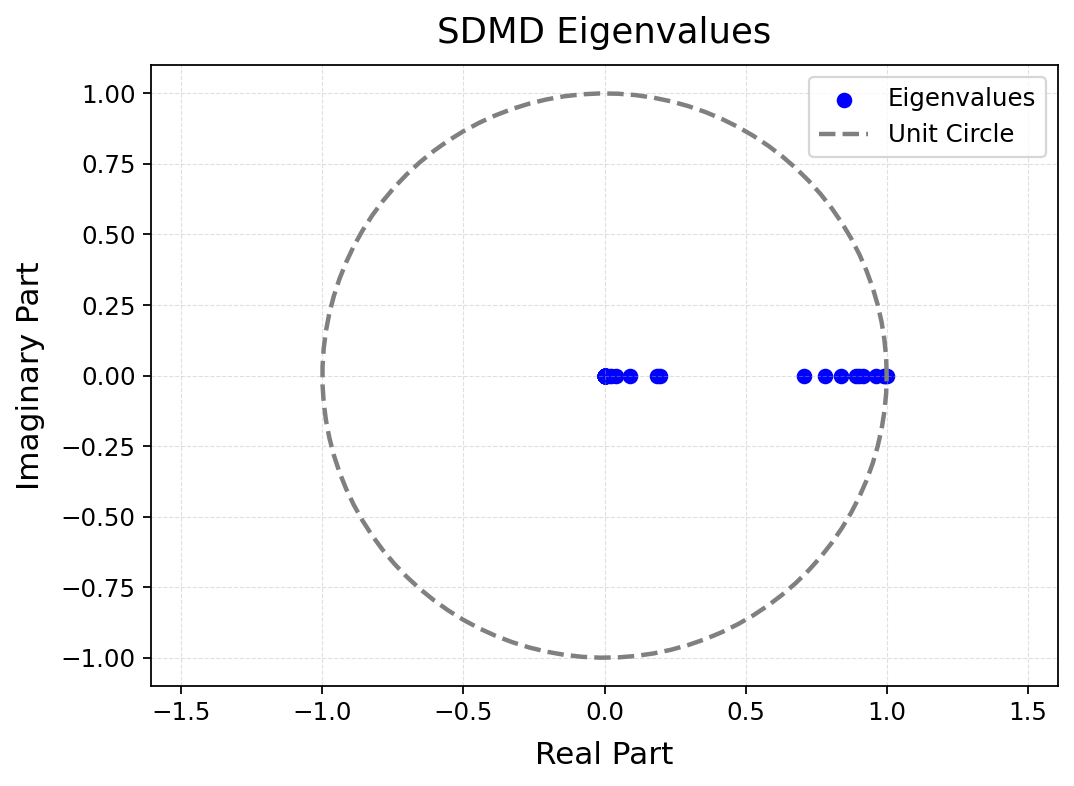

In [19]:
# ============================================================
# Visualization: SDMD eigenvalues on the unit circle
# ============================================================

# Plot eigenvalues on unit circle
real_parts = evalues_sdmd.real
imag_parts = evalues_sdmd.imag

# Create the plot
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
ax.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

ax.set_title('SDMD Eigenvalues')
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')
ax.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.4)
ax.legend(loc='upper right')
fig.tight_layout(pad=LAYOUT_PAD)
plt.show()


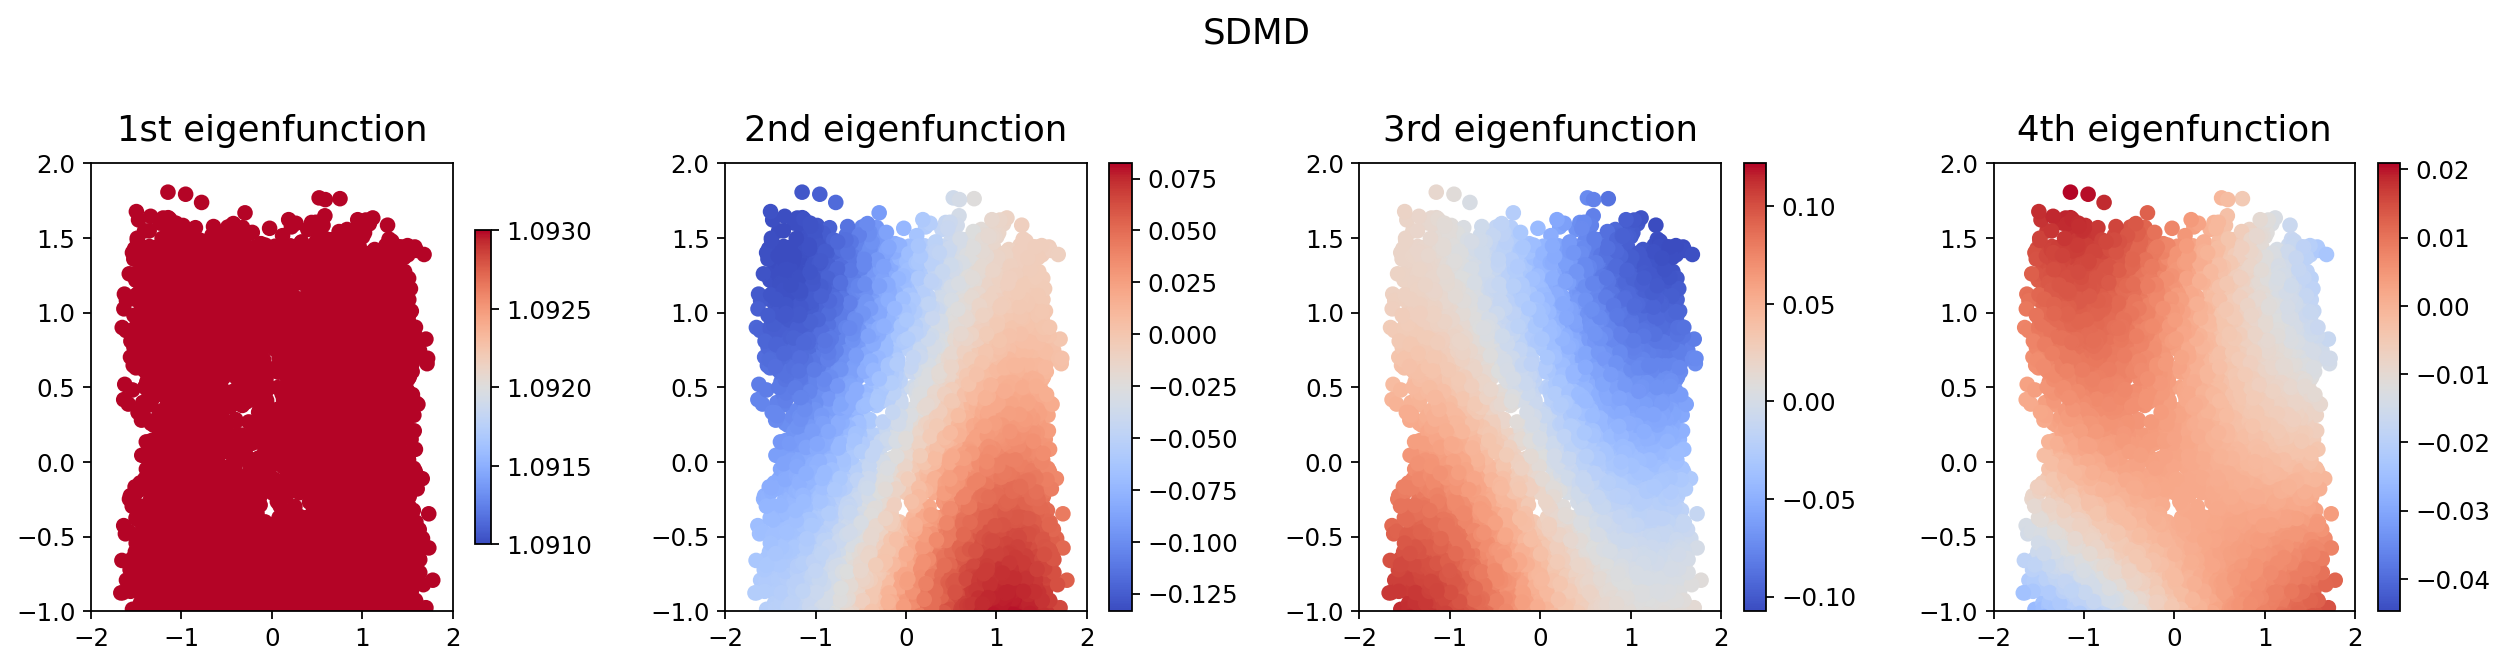

In [20]:
# ============================================================
# Visualization: SDMD eigenfunctions
# ============================================================

# Plot eigenfunctions
fig, axs = plt.subplots(1, 4, figsize=FIGSIZE_FOUR_PANEL)

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns_sdmd)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns_sdmd)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns_sdmd)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns_sdmd)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# Plot for the 4th eigenfunction
scatter4 = axs[3].scatter(*X.T, c=np.real(efuns_sdmd)[:, 3], cmap='coolwarm')
axs[3].set_title('4th eigenfunction')
axs[3].set_xlim(-2, 2)
axs[3].set_ylim(-1, 2)
cbar4 = fig.colorbar(scatter4, ax=axs[3])

fig.suptitle('SDMD', fontsize=FONT_TITLE)
fig.tight_layout(pad=LAYOUT_PAD)
plt.show()


## SDMD Analysis: KL Divergence & Boltzmann Sampling

1. Track KL divergence between particle distribution and true Boltzmann distribution during gradient descent
2. Sample from Boltzmann distribution $\pi(x) \propto e^{-V(x)}$ to show spread around well bottoms

In [21]:
# ============================================================
# Koopman(SDMD): Run shared KSWGD loop with learned SDMD spectrum
# ============================================================

print("="*60)
print(f"Koopman(SDMD): Running {n_iter_kswgd} iterations...")
print("="*60)

X_kswgd_traj_sdmd, metrics_sdmd, k_modes_sdmd, _ = run_kswgd_with_spectrum(
    method_name='SDMD KSWGD',
    X_init=X_kswgd_init,
    X_train_gpu=X_tar_gpu,
    p_x_train_gpu=p_x_gpu,
    D_y_train_gpu=D_y_gpu,
    epsilon_val=epsilon,
    eigvecs_on_train=eigvecs_K_sdmd,
    lambda_gen_full_values=lambda_gen_full_sdmd,
    eigvals_for_mode_selection=eigvals_K_sdmd,
    fixed_mode_count=k_modes_sdmd_fixed,
    eig_threshold_value=eig_threshold,
    n_skip_modes=n_skip,
    n_iter=n_iter_kswgd,
    step_size=h_kswgd,
    record_every=record_interval,
    potential_obj=potential,
)

Koopman(SDMD): Running 10000 iterations...
Using fixed mode count: 49
SDMD KSWGD modes: 49 (from 2 to 50)
Torch tensors prepared for SDMD KSWGD on: cuda:0
Particles: 2000
Iterations: 10000
Recording interval: 100 steps
Total records: 101

Initial state (step 0):
  Well coverage: 11.00%
  Avg potential: 4.4475


SDMD KSWGD: 100%|██████████| 10000/10000 [06:29<00:00, 25.67iter/s, avg_V=1.874, coverage=91.8%, movement=1.68e-05]


SDMD KSWGD iteration complete!


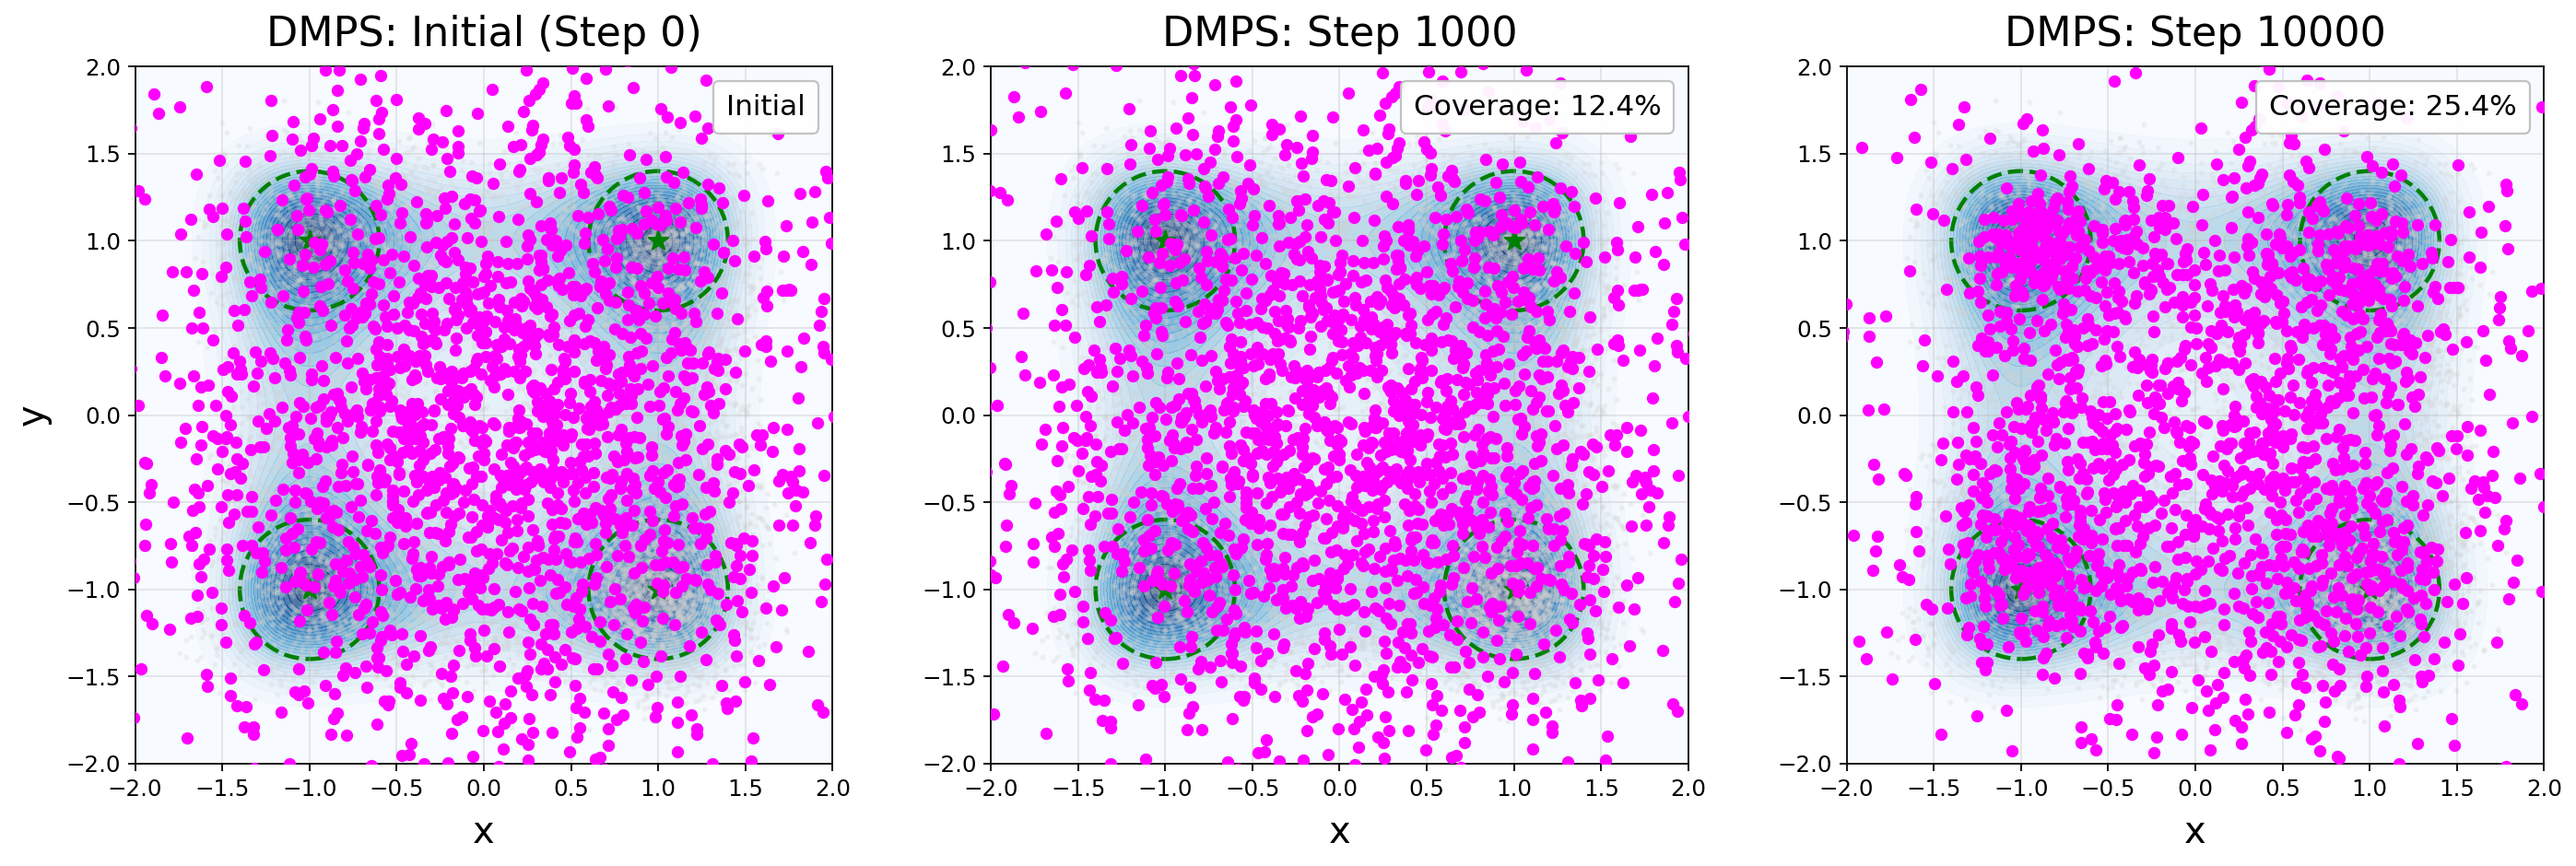

In [22]:
# ============================================================
# Visualization: DMPS at steps 0, 1000, n_iter_kswgd
# ============================================================

snapshot_steps = [0, 1000, n_iter_kswgd]
plot_particle_snapshots(
    X_kswgd_traj_dm,
    snapshot_steps,
    'DMPS',
    density_grid,
    X_grid,
    Y_grid,
    X_reference=X_tar,
    metrics=metrics_dm,
)

coverage_1000 = metrics_dm['well_coverage'][step_index(metrics_dm, 1000)]

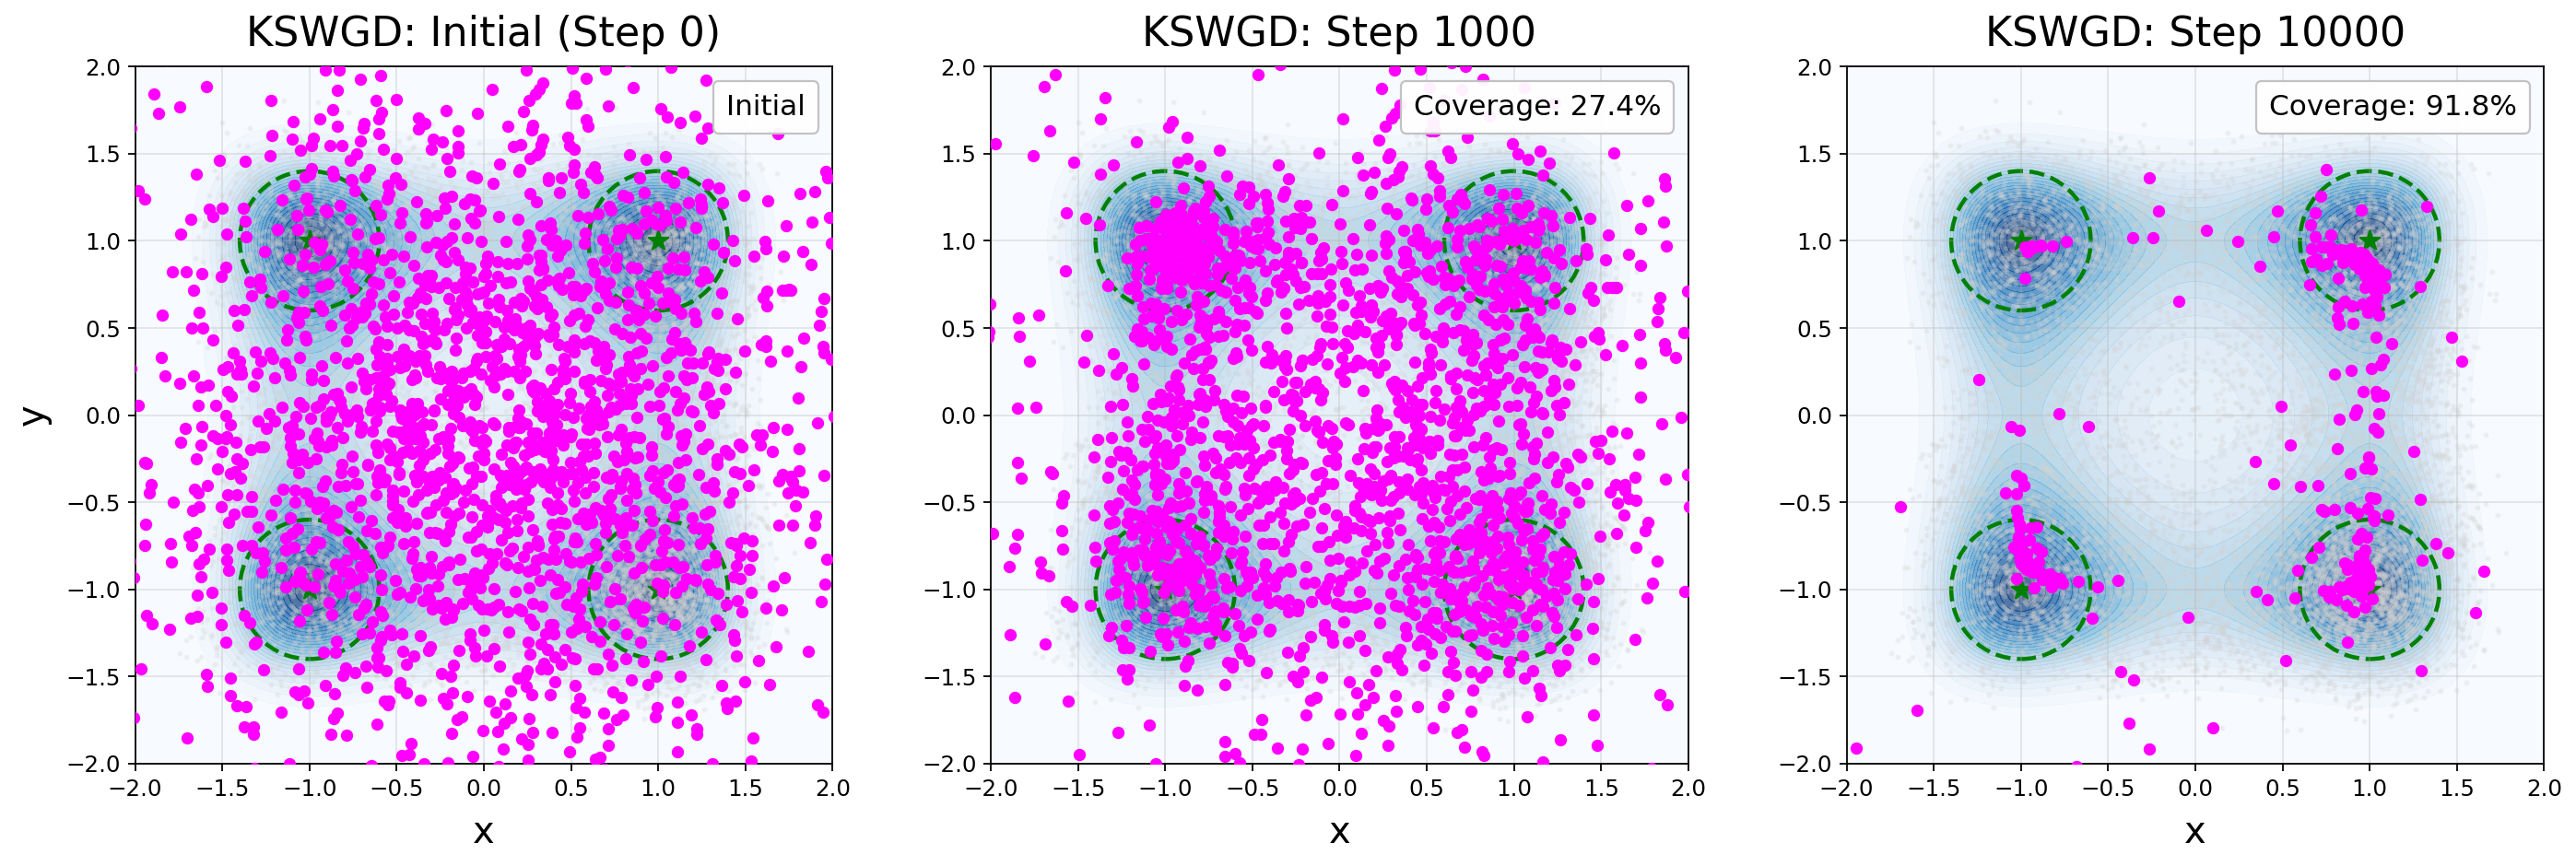

In [23]:
# ============================================================
# Visualization: KSWGD at steps 0, 1000, n_iter_kswgd
# ============================================================

plot_particle_snapshots(
    X_kswgd_traj_sdmd,
    snapshot_steps,
    'KSWGD',
    density_grid,
    X_grid,
    Y_grid,
    X_reference=X_tar,
    metrics=metrics_sdmd,
)

coverage_1000_sdmd = metrics_sdmd['well_coverage'][step_index(metrics_sdmd, 1000)]

In [24]:
print(f"KSWGD coverage: Step 1000={coverage_1000_sdmd:.2f}%, Step {n_iter_kswgd}={metrics_sdmd['well_coverage'][-1]:.2f}%")


KSWGD coverage: Step 1000=27.40%, Step 10000=91.85%


In [25]:
# ============================================================
# Count particles in each basin at final step
# ============================================================

particles_final = X_kswgd_traj_sdmd[:, :, n_iter_kswgd]
basin_labels = ['Bottom-Left (-1,-1)', 'Top-Left (-1,+1)', 'Bottom-Right (+1,-1)', 'Top-Right (+1,+1)']
basin_counts, outside_basins = compute_well_counts(particles_final, well_centers, well_radius)
total_particles = len(particles_final)
total_in_basins = sum(basin_counts)

print("="*70)
print(f"PARTICLE DISTRIBUTION IN BASINS (KSWGD at Step {n_iter_kswgd})")
print("="*70)

for i, (label, count) in enumerate(zip(basin_labels, basin_counts)):
    percentage = 100.0 * count / total_particles
    print(f"Basin {i+1} {label:25s}: {count:4d} particles ({percentage:5.1f}%)")

print("-"*70)
print(f"{'Total in basins':29s}: {total_in_basins:4d} particles ({100.0*total_in_basins/total_particles:5.1f}%)")
print(f"{'Outside basins':29s}: {outside_basins:4d} particles ({100.0*outside_basins/total_particles:5.1f}%)")
print(f"{'Total particles':29s}: {total_particles:4d} particles")
print("="*70)

PARTICLE DISTRIBUTION IN BASINS (KSWGD at Step 10000)
Basin 1 Bottom-Left (-1,-1)      :  473 particles ( 23.6%)
Basin 2 Top-Left (-1,+1)         :  492 particles ( 24.6%)
Basin 3 Bottom-Right (+1,-1)     :  522 particles ( 26.1%)
Basin 4 Top-Right (+1,+1)        :  350 particles ( 17.5%)
----------------------------------------------------------------------
Total in basins              : 1837 particles ( 91.8%)
Outside basins               :  163 particles (  8.2%)
Total particles              : 2000 particles


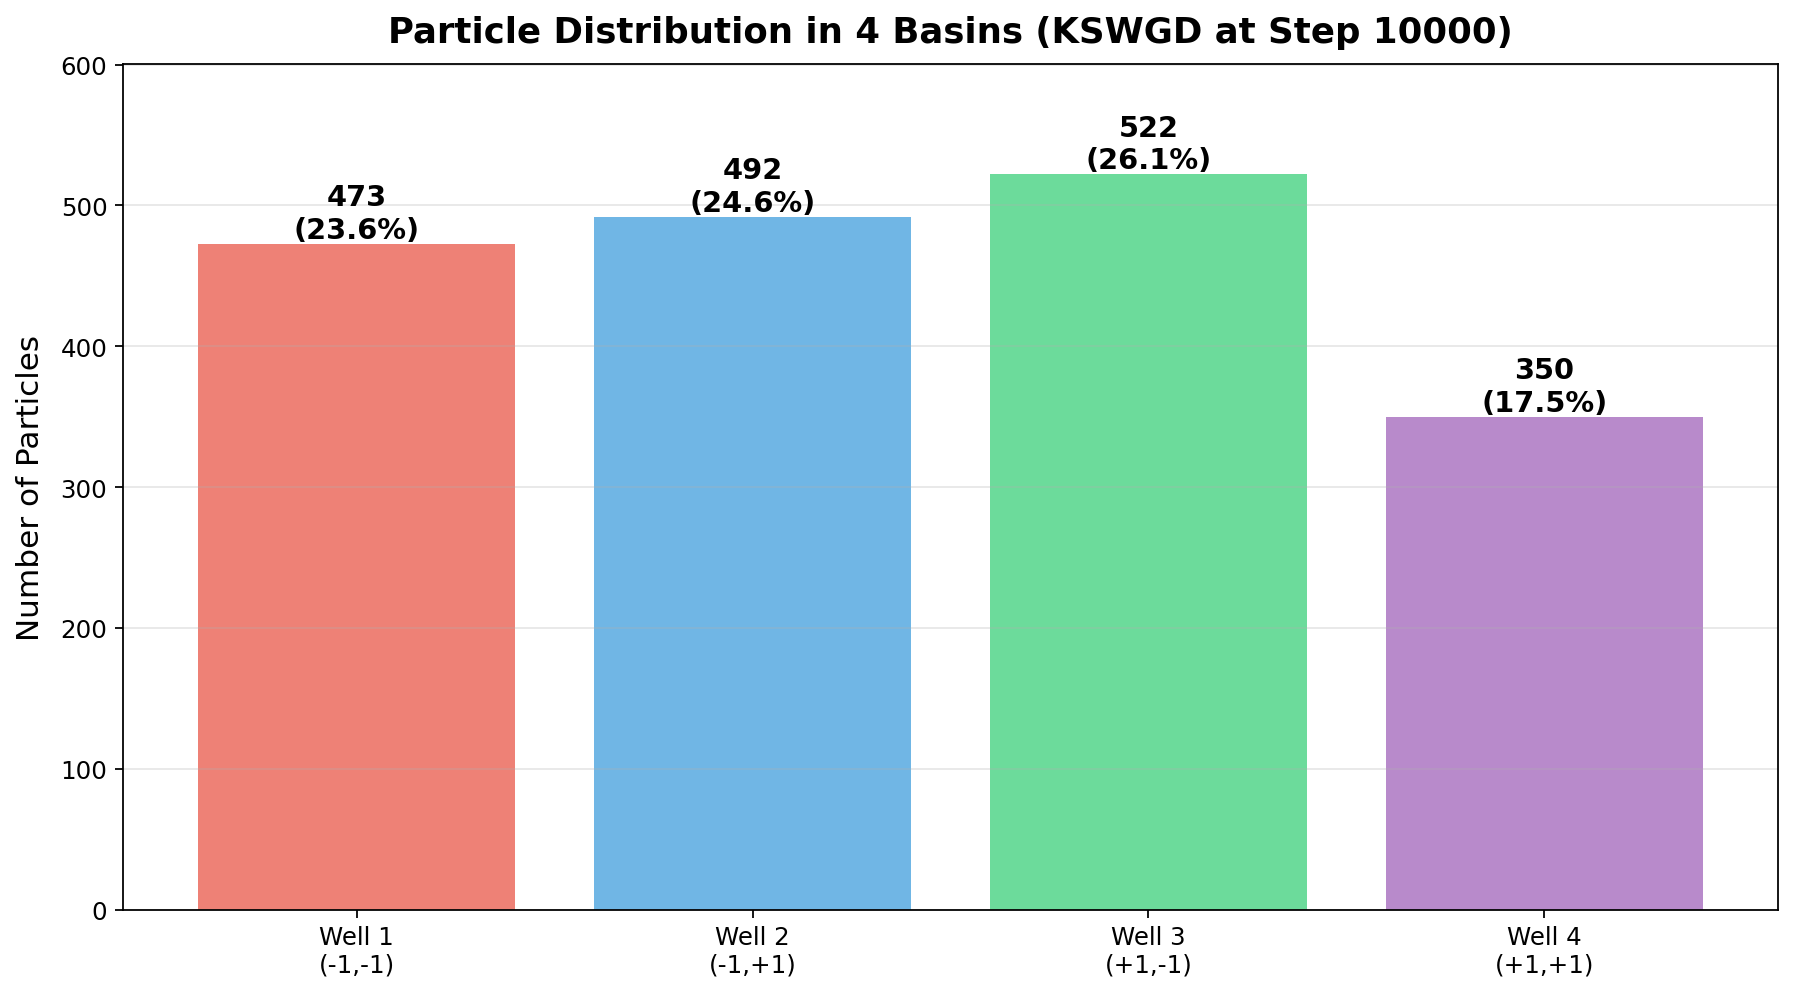

In [26]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)
x_positions = np.arange(len(basin_labels))
bars = ax.bar(x_positions, basin_counts, color=WELL_COLORS, alpha=0.7)

for bar, count in zip(bars, basin_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({100.0*count/total_particles:.1f}%)',
            ha='center', va='bottom', fontsize=FONT_BASE, fontweight='bold')

ax.set_ylabel('Number of Particles', fontsize=FONT_LABEL)
ax.set_title(f'Particle Distribution in 4 Basins (KSWGD at Step {n_iter_kswgd})', fontsize=FONT_TITLE, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels(WELL_LABELS_SHORT, fontsize=FONT_TICK)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(basin_counts) * 1.15)

fig.tight_layout(pad=LAYOUT_PAD)
plt.show()

In [27]:
# ============================================================
# Parameter Analysis: Key Questions Answered
# ============================================================

print("="*80)
print("KEY PARAMETER ANALYSIS")
print("="*80)

# 1. Training data volume and basis function count
n_samples = X_tar.shape[0]
print(f"\n1. Training Data Size vs Koopman Dictionary Size:")
print(f"   - Training data samples: {n_samples}")
print(f"   - Current dictionary size (N_dict_sdmd): {N_dict_sdmd}")
print(f"   - Data/Dictionary ratio: {n_samples / N_dict_sdmd:.2f}")
print(f"   - Theoretical optimum: Dictionary size ~ sqrt{n_samples} ~ {int(np.sqrt(n_samples))}")
print(f"   - Recommendation: Dictionary size 50-200 is reasonable (current: {N_dict_sdmd})")
print(f"   - Current N_dict_sdmd = {N_dict_sdmd} is {'reasonable' if 50 <= N_dict_sdmd <= 200 else 'needs adjustment'}")

# 2. Iteration settings
print(f"\n2. Iteration Settings:")
print(f"   - Total iterations: n_iter_kswgd = {n_iter_kswgd}")
print(f"   - Recording interval: record_interval = {record_interval}")
print(f"   - Total recording points: {n_records}")
print(f"   - Step size: h_kswgd = {h_kswgd}")

# 3. Mode selection method
print(f"\n3. DMPS and Koopman Spectrum Computation Method:")
print(f"   - Method: Threshold-based (NOT fixed truncation)")
print(f"   - DM eigenvalue threshold: eig_threshold = {eig_threshold}")
print(f"   - DM total eigenvalues: {len(eigvals_K_dm)}")
print(f"   - DM skipped modes: n_skip={n_skip} (stationary mode)")
print(f"   - DM retained modes (k_modes): {k_modes}")
print(f"   - SDMD retained modes (k_modes_sdmd): {k_modes_sdmd}")
print(f"   - Note: Retains all eigenvalues with real part > {eig_threshold}, not fixed truncation")

# 4. Gaussian initialization
print(f"\n4. Gaussian Initialization Parameters:")
print(f"   - Initial sampling count: n_init_particles = {n_init_particles}")
print(f"   - Gaussian distribution mean: gaussian_mean = {gaussian_mean}")
print(f"   - Gaussian distribution std: gaussian_std = {gaussian_std}")
print(f"   - Filtered particle count (X_kswgd_init): {X_kswgd_init.shape[0]}")
print(f"   - Variable controlling particle count: n_init_particles (current = {n_init_particles})")
print(f"   - Variable controlling distribution range: gaussian_std (current = {gaussian_std})")
print(f"   - Actual particles used ~ {100 * X_kswgd_init.shape[0] / n_init_particles:.1f}% of initial sampling")

# 5. Other important parameters
print(f"\n5. Other Key Parameters:")
print(f"   - Kernel bandwidth: epsilon = {epsilon:.6f}")
print(f"   - Well radius: well_radius = {well_radius}")
print(f"   - Number of wells: {len(well_centers)}")

# 6. Data/Dictionary ratio analysis
print(f"\n6. Basis Function Count Recommendations:")
print(f"   - Current data volume: {n_samples} samples")
print(f"   - Optimal basis function count (sqrtn): {int(np.sqrt(n_samples))}")
print(f"   - Safe range (0.5sqrtn ~ 2sqrtn): {int(0.5*np.sqrt(n_samples))} ~ {int(2*np.sqrt(n_samples))}")
data_ratio = n_samples / N_dict_sdmd
if data_ratio < 50:
    print(f"   WARNING: Data/Dict ratio = {data_ratio:.1f} < 50, possible overfitting. Recommend reducing dictionary size.")
elif data_ratio > 200:
    print(f"   OK: Data/Dict ratio = {data_ratio:.1f} > 200, very safe but may underfit")
else:
    print(f"   OK: Data/Dict ratio = {data_ratio:.1f} is in a reasonable range")

print("="*80)


KEY PARAMETER ANALYSIS

1. Training Data Size vs Koopman Dictionary Size:
   - Training data samples: 9999
   - Current dictionary size (N_dict_sdmd): 50
   - Data/Dictionary ratio: 199.98
   - Theoretical optimum: Dictionary size ~ sqrt9999 ~ 99
   - Recommendation: Dictionary size 50-200 is reasonable (current: 50)
   - Current N_dict_sdmd = 50 is reasonable

2. Iteration Settings:
   - Total iterations: n_iter_kswgd = 10000
   - Recording interval: record_interval = 100
   - Total recording points: 101
   - Step size: h_kswgd = 0.02

3. DMPS and Koopman Spectrum Computation Method:
   - Method: Threshold-based (NOT fixed truncation)
   - DM eigenvalue threshold: eig_threshold = 0.001
   - DM total eigenvalues: 1000
   - DM skipped modes: n_skip=1 (stationary mode)
   - DM retained modes (k_modes): 480
   - SDMD retained modes (k_modes_sdmd): 49
   - Note: Retains all eigenvalues with real part > 0.001, not fixed truncation

4. Gaussian Initialization Parameters:
   - Initial samplin

In [28]:
# ============================================================
# Density Heat Map Comparison: Training Data vs Boltzmann vs KSWGD vs DMPS
# Using KDE for smooth density visualization
# ============================================================

n_grid_kde = 100
x_eval = np.linspace(-2, 2, n_grid_kde)
y_eval = np.linspace(-2, 2, n_grid_kde)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval)
positions = np.vstack([X_eval.ravel(), Y_eval.ravel()])
grid_shape = (n_grid_kde, n_grid_kde)

print("Computing KDE for training data...")
density_train, kde_train = kde_density_on_grid(X_tar, positions, grid_shape)

print("Computing true Boltzmann distribution...")
density_boltzmann = potential.stationary_density(X_eval, Y_eval)

print(f"Computing KDE for DMPS (step {n_iter_kswgd})...")
X_dmps_final = X_kswgd_traj_dm[:, :, n_iter_kswgd]
density_dmps, kde_dmps = kde_density_on_grid(X_dmps_final, positions, grid_shape)

print(f"Computing KDE for KSWGD (step {n_iter_kswgd})...")
X_kswgd_final = X_kswgd_traj_sdmd[:, :, n_iter_kswgd]
density_kswgd, kde_kswgd = kde_density_on_grid(X_kswgd_final, positions, grid_shape)

Computing KDE for training data...
Computing true Boltzmann distribution...
Computing KDE for DMPS (step 10000)...
Computing KDE for KSWGD (step 10000)...


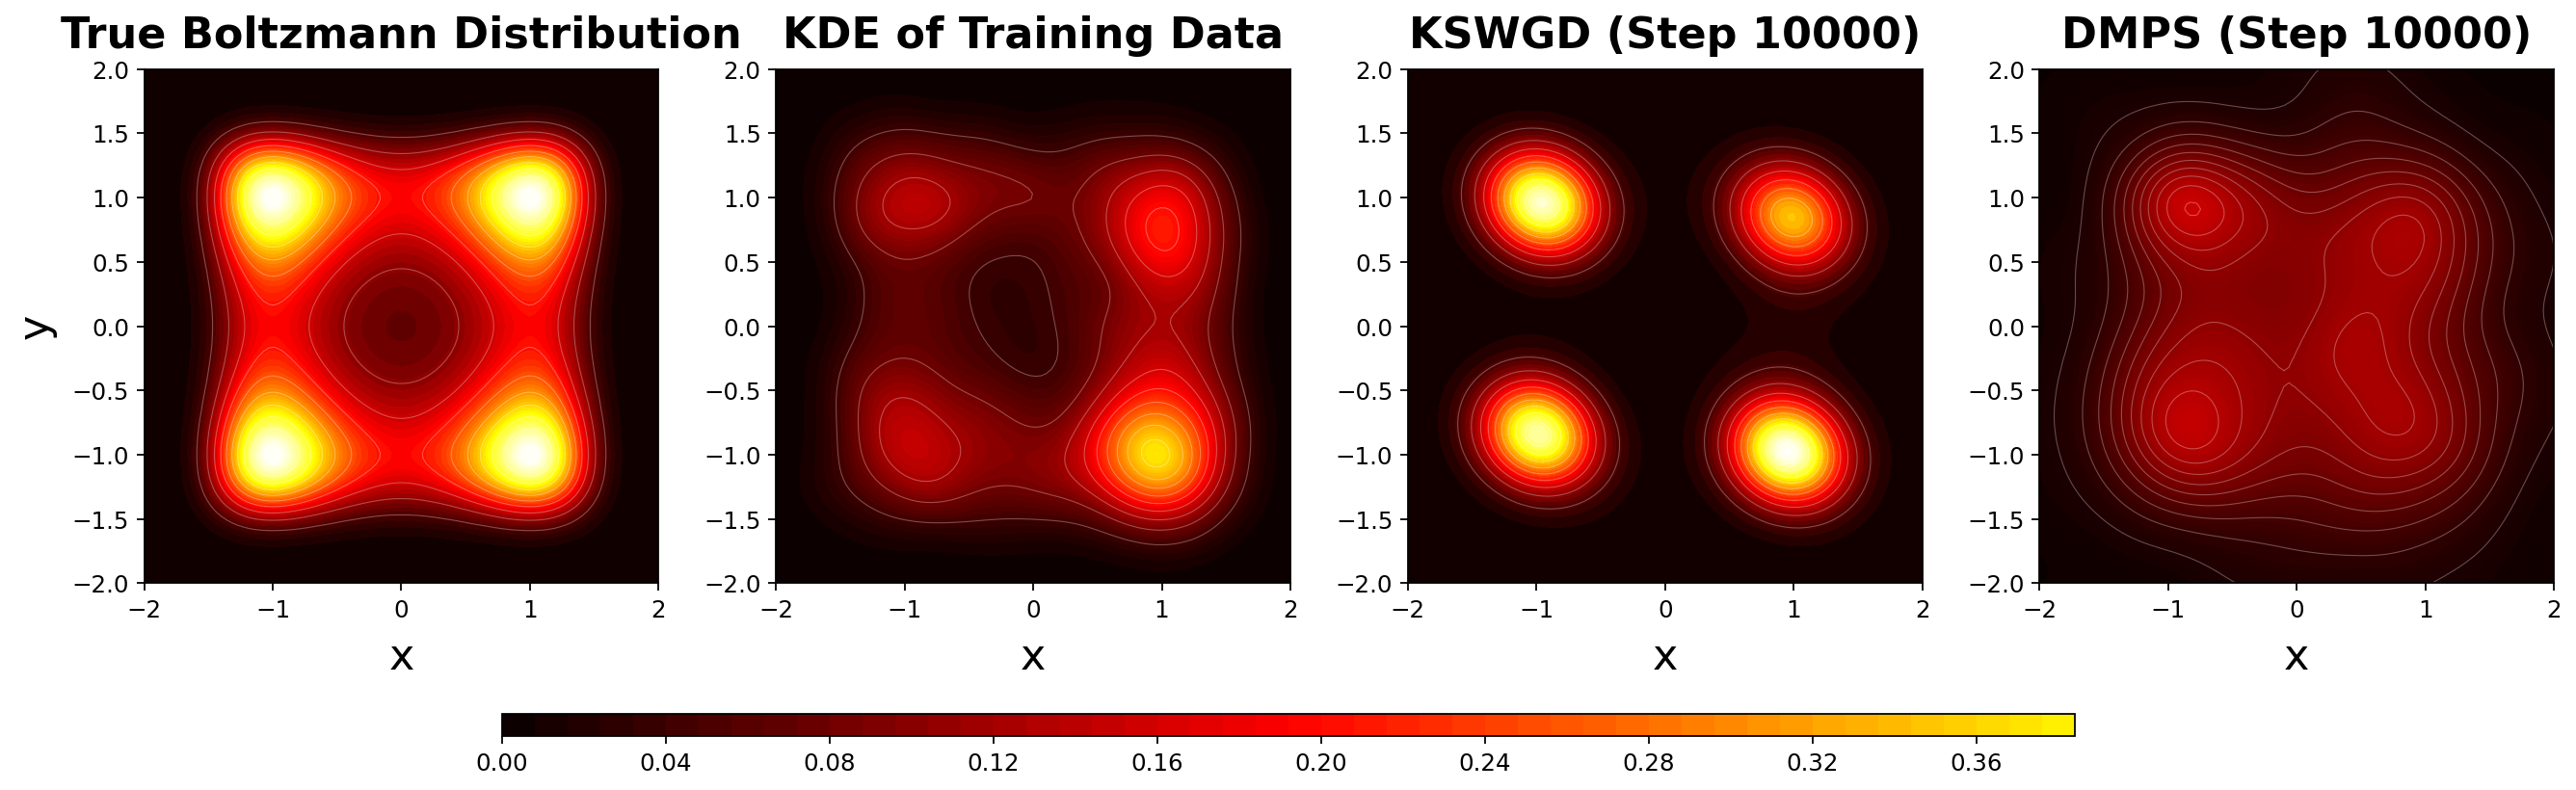

In [29]:
# ============================================================
# Visualization: 4 Heat Maps (1x4 row)
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=FIGSIZE_THREE_METRICS)

# Common colorbar range for fair comparison (excluding Boltzmann which has different scale)
vmin_kde = 0
vmax_kde = max(density_train.max(), density_dmps.max(), density_kswgd.max())

# ----- Plot 1: True Boltzmann Distribution -----
ax1 = axes[0]
im1_boltz = ax1.contourf(X_eval, Y_eval, density_boltzmann, levels=50, cmap='hot')
ax1.contour(X_eval, Y_eval, density_boltzmann, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax1.set_xlabel('x', fontsize=FONT_PANEL_TITLE)
ax1.set_ylabel('y', fontsize=FONT_PANEL_TITLE)
ax1.set_title('True Boltzmann Distribution', fontsize=FONT_PANEL_TITLE, fontweight='bold')
ax1.set_xlim(-2, 2)
ax1.set_ylim(-2, 2)
ax1.set_aspect('equal')
ax1.tick_params(axis='both', labelsize=FONT_TICK)

# ----- Plot 2: Training Data -----
ax2 = axes[1]
im2 = ax2.contourf(X_eval, Y_eval, density_train, levels=50, cmap='hot', vmin=vmin_kde, vmax=vmax_kde)
ax2.contour(X_eval, Y_eval, density_train, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('x', fontsize=FONT_PANEL_TITLE)
ax2.set_title('KDE of Training Data', fontsize=FONT_PANEL_TITLE, fontweight='bold')
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.set_aspect('equal')
ax2.tick_params(axis='both', labelsize=FONT_TICK)

# ----- Plot 3: KSWGD at final step -----
ax3 = axes[2]
im3 = ax3.contourf(X_eval, Y_eval, density_kswgd, levels=50, cmap='hot', vmin=vmin_kde, vmax=vmax_kde)
ax3.contour(X_eval, Y_eval, density_kswgd, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax3.set_xlabel('x', fontsize=FONT_PANEL_TITLE)
ax3.set_title(f'KSWGD (Step {n_iter_kswgd})', fontsize=FONT_PANEL_TITLE, fontweight='bold')
ax3.set_xlim(-2, 2)
ax3.set_ylim(-2, 2)
ax3.set_aspect('equal')
ax3.tick_params(axis='both', labelsize=FONT_TICK)

# ----- Plot 4: DMPS at final step -----
ax4 = axes[3]
im4 = ax4.contourf(X_eval, Y_eval, density_dmps, levels=50, cmap='hot', vmin=vmin_kde, vmax=vmax_kde)
ax4.contour(X_eval, Y_eval, density_dmps, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax4.set_xlabel('x', fontsize=FONT_PANEL_TITLE)
ax4.set_title(f'DMPS (Step {n_iter_kswgd})', fontsize=FONT_PANEL_TITLE, fontweight='bold')
ax4.set_xlim(-2, 2)
ax4.set_ylim(-2, 2)
ax4.set_aspect('equal')
ax4.tick_params(axis='both', labelsize=FONT_TICK)

# Add shared colorbar for the three KDE-based plots (bottom, centered)
fig.tight_layout(pad=LAYOUT_PAD)
plt.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.2, 0.095, 0.6, 0.025])  # [left, bottom, width, height] - centered under all 4 plots
cbar = fig.colorbar(im2, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=FONT_TICK)

plt.show()


In [30]:
# ============================================================
# Print Statistics
# ============================================================
print("\n" + "="*70)
print("DENSITY STATISTICS (KDE)")
print("="*70)

# Print bandwidth information
print(f"\nKDE Bandwidth (Scott's rule):")
print(f"  - Training Data: {kde_train.factor:.6f}")
print(f"  - KSWGD:         {kde_kswgd.factor:.6f}")
print(f"  - DMPS:          {kde_dmps.factor:.6f}")

print(f"\nTraining Data (Time Series):")
print(f"  - Max density: {density_train.max():.4f}")
print(f"  - Mean density: {density_train.mean():.4f}")
print(f"  - Samples: {X_tar.shape[0]}")

print(f"\nTrue Boltzmann Distribution:")
print(f"  - Max density: {density_boltzmann.max():.4f}")
print(f"  - Mean density: {density_boltzmann.mean():.4f}")

print(f"\nKSWGD (Step {n_iter_kswgd}):")
print(f"  - Max density: {density_kswgd.max():.4f}")
print(f"  - Mean density: {density_kswgd.mean():.4f}")
print(f"  - Particles: {X_kswgd_final.shape[0]}")

print(f"\nDMPS (Step {n_iter_kswgd}):")
print(f"  - Max density: {density_dmps.max():.4f}")
print(f"  - Mean density: {density_dmps.mean():.4f}")
print(f"  - Particles: {X_dmps_final.shape[0]}")
print("="*70)



DENSITY STATISTICS (KDE)

KDE Bandwidth (Scott's rule):
  - Training Data: 0.215447
  - KSWGD:         0.281727
  - DMPS:          0.281727

Training Data (Time Series):
  - Max density: 0.3763
  - Mean density: 0.0612
  - Samples: 9999

True Boltzmann Distribution:
  - Max density: 0.2575
  - Mean density: 0.0615

KSWGD (Step 10000):
  - Max density: 0.5279
  - Mean density: 0.0593
  - Particles: 2000

DMPS (Step 10000):
  - Max density: 0.1514
  - Mean density: 0.0568
  - Particles: 2000


## Convergence Comparison: DMPS vs Koopman(SDMD)

Visualize convergence metrics over iterations to compare the two methods

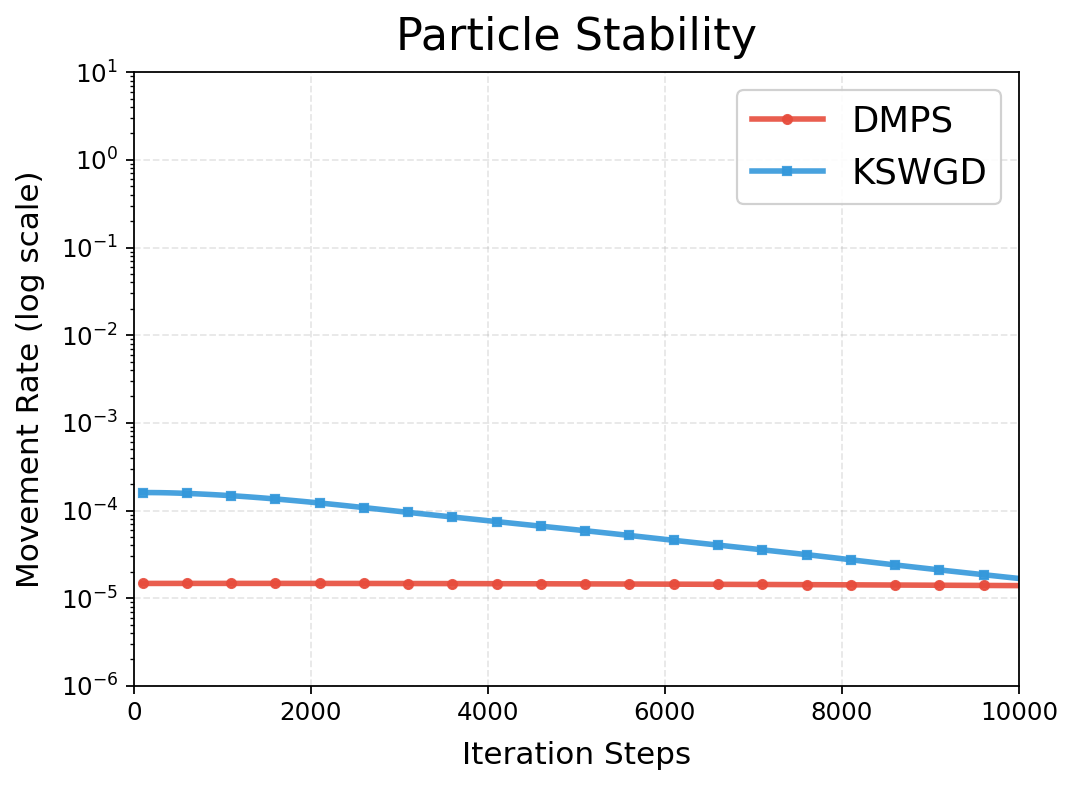

In [31]:
# ============================================================
# Convergence Comparison Visualization: Movement Rate
# ============================================================

fig, ax3 = plt.subplots(1, 1, figsize=FIGSIZE_SINGLE)

# Color scheme
color_dm = '#E74C3C'      # Red for DMPS
color_sdmd = '#3498DB'    # Blue for Koopman(SDMD)

# ========== Movement Rate (Displacement per Step) ==========

ax3.plot(metrics_dm['steps'][1:], metrics_dm['movement_rate'][1:],  # Skip step 0 (movement=0)
         color=color_dm, linewidth=2.5, marker='o', markersize=4, 
         markevery=5, label='DMPS', alpha=0.9)

ax3.plot(metrics_sdmd['steps'][1:], metrics_sdmd['movement_rate'][1:], 
         color=color_sdmd, linewidth=2.5, marker='s', markersize=4, 
         markevery=5, label='KSWGD', alpha=0.9)

# # Mark 1000 steps
# ax3.axvline(x=1000, color='gray', linestyle='--', linewidth=1, alpha=0.5)
# ax3.text(1000, ax3.get_ylim()[1] * 0.95, '1000 steps', 
#          ha='center', va='top', fontsize=FONT_SMALL, color='gray')

ax3.set_xlabel('Iteration Steps', fontsize=FONT_LABEL)
ax3.set_ylabel('Movement Rate (log scale)', fontsize=FONT_LABEL)
ax3.set_title('Particle Stability', fontsize=FONT_PANEL_TITLE)
ax3.set_xlim(0, n_iter_kswgd)
ax3.set_yscale('log')  # Use log scale to show small changes
ax3.set_ylim(1e-6, 1e1)  # Fixed Y-axis range to reduce visual emphasis on differences
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(loc='upper right', fontsize=FONT_TITLE, framealpha=0.9)

fig.tight_layout(pad=LAYOUT_PAD)
plt.show()


In [32]:
# ============================================================
# Print Convergence Analysis Summary
# ============================================================

print("\n" + "="*70)
print("CONVERGENCE ANALYSIS SUMMARY")
print("="*70)

summary_step = 1000
idx_1000 = step_index(metrics_dm, summary_step)
idx_1000_sdmd = step_index(metrics_sdmd, summary_step)

print(f"\n AT {summary_step} STEPS:")
print("-" * 70)

print(f"\nDMPS:")
print(f"  - Well Coverage:    {metrics_dm['well_coverage'][idx_1000]:.2f}%")
print(f"  - Avg Potential:    {metrics_dm['avg_potential'][idx_1000]:.4f}")
print(f"  - Movement Rate:    {metrics_dm['movement_rate'][idx_1000]:.6f}")

print(f"\nKoopman(SDMD):")
print(f"  - Well Coverage:    {metrics_sdmd['well_coverage'][idx_1000_sdmd]:.2f}%")
print(f"  - Avg Potential:    {metrics_sdmd['avg_potential'][idx_1000_sdmd]:.4f}")
print(f"  - Movement Rate:    {metrics_sdmd['movement_rate'][idx_1000_sdmd]:.6f}")

print(f"\n AT {n_iter_kswgd} STEPS (FINAL):")
print("-" * 70)

print(f"\nDMPS:")
print(f"  - Well Coverage:    {metrics_dm['well_coverage'][-1]:.2f}%")
print(f"  - Avg Potential:    {metrics_dm['avg_potential'][-1]:.4f}")
print(f"  - Movement Rate:    {metrics_dm['movement_rate'][-1]:.6f}")

print(f"\nKoopman(SDMD):")
print(f"  - Well Coverage:    {metrics_sdmd['well_coverage'][-1]:.2f}%")
print(f"  - Avg Potential:    {metrics_sdmd['avg_potential'][-1]:.4f}")
print(f"  - Movement Rate:    {metrics_sdmd['movement_rate'][-1]:.6f}")

print("\n" + "="*70)
print("CONVERGENCE DETECTION")
print("="*70)

coverage_threshold = 95.0
movement_threshold = 0.01


def detect_convergence(metrics_dict, coverage_thresh=95.0, movement_thresh=0.01):
    """Detect first recorded step where convergence criteria are met."""
    steps = metrics_dict['steps']
    coverage = metrics_dict['well_coverage']
    movement = metrics_dict['movement_rate']

    for i in range(1, len(steps)):
        if coverage[i] >= coverage_thresh and movement[i] <= movement_thresh:
            return steps[i], i
    return None, None


conv_step_dm, conv_idx_dm = detect_convergence(metrics_dm, coverage_threshold, movement_threshold)
conv_step_sdmd, conv_idx_sdmd = detect_convergence(metrics_sdmd, coverage_threshold, movement_threshold)

print(f"\nCriteria: Coverage >= {coverage_threshold}% AND Movement <= {movement_threshold}")
print("-" * 70)

if conv_step_dm is not None:
    print(f"\nDMPS converged at step: {conv_step_dm}")
    print(f"  - Well Coverage:    {metrics_dm['well_coverage'][conv_idx_dm]:.2f}%")
    print(f"  - Movement Rate:    {metrics_dm['movement_rate'][conv_idx_dm]:.6f}")
else:
    print(f"\nDMPS: NOT fully converged by step {n_iter_kswgd}")
    print(f"  - Final Coverage:   {metrics_dm['well_coverage'][-1]:.2f}% (target: >={coverage_threshold}%)")
    print(f"  - Final Movement:   {metrics_dm['movement_rate'][-1]:.6f} (target: <={movement_threshold})")

if conv_step_sdmd is not None:
    print(f"\nKoopman(SDMD) converged at step: {conv_step_sdmd}")
    print(f"  - Well Coverage:    {metrics_sdmd['well_coverage'][conv_idx_sdmd]:.2f}%")
    print(f"  - Movement Rate:    {metrics_sdmd['movement_rate'][conv_idx_sdmd]:.6f}")
else:
    print(f"\nKoopman(SDMD): NOT fully converged by step {n_iter_kswgd}")
    print(f"  - Final Coverage:   {metrics_sdmd['well_coverage'][-1]:.2f}% (target: >={coverage_threshold}%)")
    print(f"  - Final Movement:   {metrics_sdmd['movement_rate'][-1]:.6f} (target: <={movement_threshold})")


CONVERGENCE ANALYSIS SUMMARY

 AT 1000 STEPS:
----------------------------------------------------------------------

DMPS:
  - Well Coverage:    12.40%
  - Avg Potential:    4.3413
  - Movement Rate:    0.000015

Koopman(SDMD):
  - Well Coverage:    27.40%
  - Avg Potential:    3.6363
  - Movement Rate:    0.000150

 AT 10000 STEPS (FINAL):
----------------------------------------------------------------------

DMPS:
  - Well Coverage:    25.40%
  - Avg Potential:    3.5654
  - Movement Rate:    0.000014

Koopman(SDMD):
  - Well Coverage:    91.85%
  - Avg Potential:    1.8739
  - Movement Rate:    0.000017

CONVERGENCE DETECTION

Criteria: Coverage >= 95.0% AND Movement <= 0.01
----------------------------------------------------------------------

DMPS: NOT fully converged by step 10000
  - Final Coverage:   25.40% (target: >=95.0%)
  - Final Movement:   0.000014 (target: <=0.01)

Koopman(SDMD): NOT fully converged by step 10000
  - Final Coverage:   91.85% (target: >=95.0%)
  - Fi

In [33]:
# ============================================================
# 4-Well Density Evolution Comparison: DMPS vs Koopman(SDMD)
# ============================================================

well_labels = WELL_LABELS_SHORT
well_colors = WELL_COLORS
time_steps = [0, 100, 300, 500, 1000, 1500, 2000, 2500, n_iter_kswgd]
time_steps = [step for step in time_steps if step <= n_iter_kswgd]

densities_dm = compute_well_densities(X_kswgd_traj_dm, time_steps, well_centers, well_radius)
densities_sdmd = compute_well_densities(X_kswgd_traj_sdmd, time_steps, well_centers, well_radius)

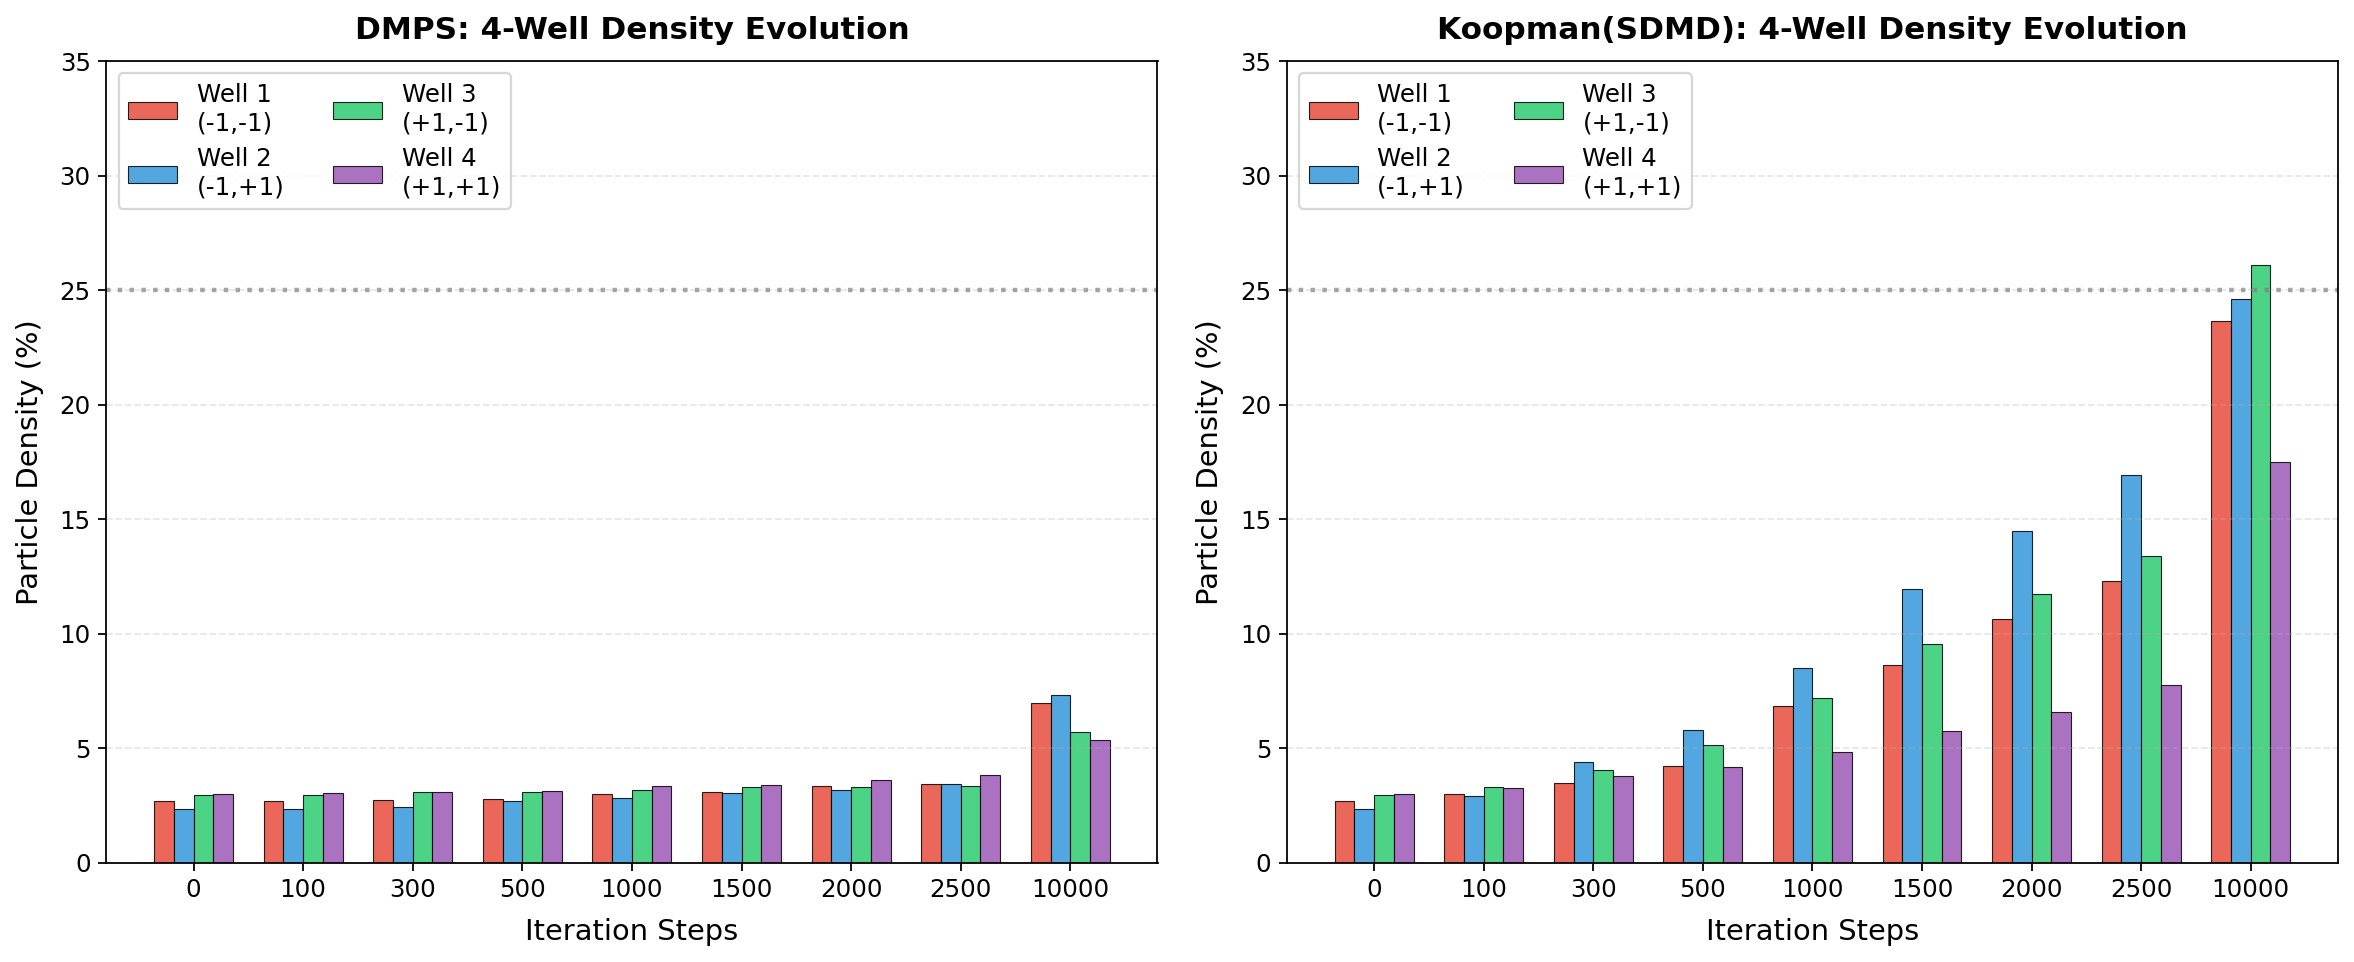

In [34]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_TWO_PANEL)

# Bar width and positions
n_times = len(time_steps)
n_wells = 4
bar_width = 0.18
x_base = np.arange(n_times)

# Plot 1: DMPS well densities over time
ax1 = axes[0]
for w_idx in range(n_wells):
    offset = (w_idx - 1.5) * bar_width
    bars = ax1.bar(x_base + offset, densities_dm[w_idx], bar_width, 
                   label=well_labels[w_idx], color=well_colors[w_idx], 
                   edgecolor='black', linewidth=0.5, alpha=0.85)
    
ax1.set_xlabel('Iteration Steps', fontsize=FONT_BASE)
ax1.set_ylabel('Particle Density (%)', fontsize=FONT_BASE)
ax1.set_title('DMPS: 4-Well Density Evolution', fontsize=FONT_LABEL, fontweight='bold')
ax1.set_xticks(x_base)
ax1.set_xticklabels([str(t) for t in time_steps], fontsize=FONT_SMALL)
ax1.legend(loc='upper left', fontsize=FONT_SMALL, ncol=2)
ax1.set_ylim(0, 35)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=25, color='gray', linestyle=':', alpha=0.7, label='Ideal (25%)')

# Plot 2: Koopman(SDMD) well densities over time
ax2 = axes[1]
for w_idx in range(n_wells):
    offset = (w_idx - 1.5) * bar_width
    bars = ax2.bar(x_base + offset, densities_sdmd[w_idx], bar_width, 
                   label=well_labels[w_idx], color=well_colors[w_idx], 
                   edgecolor='black', linewidth=0.5, alpha=0.85)
    
ax2.set_xlabel('Iteration Steps', fontsize=FONT_BASE)
ax2.set_ylabel('Particle Density (%)', fontsize=FONT_BASE)
ax2.set_title('Koopman(SDMD): 4-Well Density Evolution', fontsize=FONT_LABEL, fontweight='bold')
ax2.set_xticks(x_base)
ax2.set_xticklabels([str(t) for t in time_steps], fontsize=FONT_SMALL)
ax2.legend(loc='upper left', fontsize=FONT_SMALL, ncol=2)
ax2.set_ylim(0, 35)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=25, color='gray', linestyle=':', alpha=0.7, label='Ideal (25%)')

fig.tight_layout(pad=LAYOUT_PAD)
# plt.savefig('figures/4_well_density_evolution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [35]:
# Print summary table
print("\n" + "="*80)
print("4-Well Density Evolution Summary (% of particles in each well)")
print("="*80)
print(f"\n{'Step':<8}", end='')
for w_idx in range(n_wells):
    print(f"{'Well '+str(w_idx+1)+' (DM)':<14}{'Well '+str(w_idx+1)+' (SDMD)':<14}", end='')
print()
print("-"*80)
for t_idx, t in enumerate(time_steps):
    print(f"{t:<8}", end='')
    for w_idx in range(n_wells):
        print(f"{densities_dm[w_idx, t_idx]:<14.1f}{densities_sdmd[w_idx, t_idx]:<14.1f}", end='')
    print()
print("="*80)
print(f"\nTotal coverage at step {n_iter_kswgd}:")
print(f"  DMPS: {np.sum(densities_dm[:, -1]):.1f}%")
print(f"  Koopman(SDMD): {np.sum(densities_sdmd[:, -1]):.1f}%")



4-Well Density Evolution Summary (% of particles in each well)

Step    Well 1 (DM)   Well 1 (SDMD) Well 2 (DM)   Well 2 (SDMD) Well 3 (DM)   Well 3 (SDMD) Well 4 (DM)   Well 4 (SDMD) 
--------------------------------------------------------------------------------
0       2.7           2.7           2.4           2.4           3.0           3.0           3.0           3.0           
100     2.7           3.0           2.4           2.9           3.0           3.3           3.0           3.2           
300     2.8           3.5           2.5           4.4           3.1           4.0           3.1           3.8           
500     2.8           4.2           2.7           5.8           3.1           5.2           3.1           4.2           
1000    3.0           6.8           2.9           8.5           3.2           7.2           3.4           4.8           
1500    3.1           8.7           3.0           11.9          3.3           9.6           3.4           5.8           
2000   

In [36]:
# ============================================================
# KL Divergence Analysis: Training Data vs DMPS vs KSWGD(SDMD)
# ============================================================

print("="*60)
print("Computing KL Divergence for all methods...")
print("="*60)

# Sample iterations to evaluate (every 100 steps)
eval_steps = list(range(0, n_iter_kswgd + 1, 100))

# Compute KL divergence for Training Data (X_tar) as baseline
# This is a constant value representing how well the training data matches the true Boltzmann distribution
kl_training_data = compute_kl_divergence_kde(X_tar, potential)
print(f"\nTraining Data (X_tar) KL Divergence: {kl_training_data:.4f}")
print("  (This serves as a baseline - the best achievable KL)")

# Compute KL divergence for DMPS
kl_history_dm = []
print("\nDMPS KL Divergence:")
dm_kl_iter = progress_range(eval_steps, desc='DMPS KL', unit='step', dynamic_ncols=True, mininterval=1.0)
for t in dm_kl_iter:
    particles_t = X_kswgd_traj_dm[:, :, t]
    kl_t = compute_kl_divergence_kde(particles_t, potential)
    kl_history_dm.append(kl_t)
    if hasattr(dm_kl_iter, 'set_postfix'):
        dm_kl_iter.set_postfix(step=t, kl=f'{kl_t:.4f}', refresh=False)
    elif t % 500 == 0:
        print(f"  Step {t}: KL = {kl_t:.4f}")

# Compute KL divergence for KSWGD(SDMD)
kl_history_sdmd = []
print("\nKSWGD(SDMD) KL Divergence:")
sdmd_kl_iter = progress_range(eval_steps, desc='KSWGD KL', unit='step', dynamic_ncols=True, mininterval=1.0)
for t in sdmd_kl_iter:
    particles_t = X_kswgd_traj_sdmd[:, :, t]
    kl_t = compute_kl_divergence_kde(particles_t, potential)
    kl_history_sdmd.append(kl_t)
    if hasattr(sdmd_kl_iter, 'set_postfix'):
        sdmd_kl_iter.set_postfix(step=t, kl=f'{kl_t:.4f}', refresh=False)
    elif t % 500 == 0:
        print(f"  Step {t}: KL = {kl_t:.4f}")


Computing KL Divergence for all methods...

Training Data (X_tar) KL Divergence: 0.1151
  (This serves as a baseline - the best achievable KL)

DMPS KL Divergence:


DMPS KL: 100%|██████████| 101/101 [00:13<00:00,  7.35step/s, kl=0.3475, step=1e+4]



KSWGD(SDMD) KL Divergence:


KSWGD KL: 100%|██████████| 101/101 [00:14<00:00,  7.06step/s, kl=0.2580, step=1e+4]


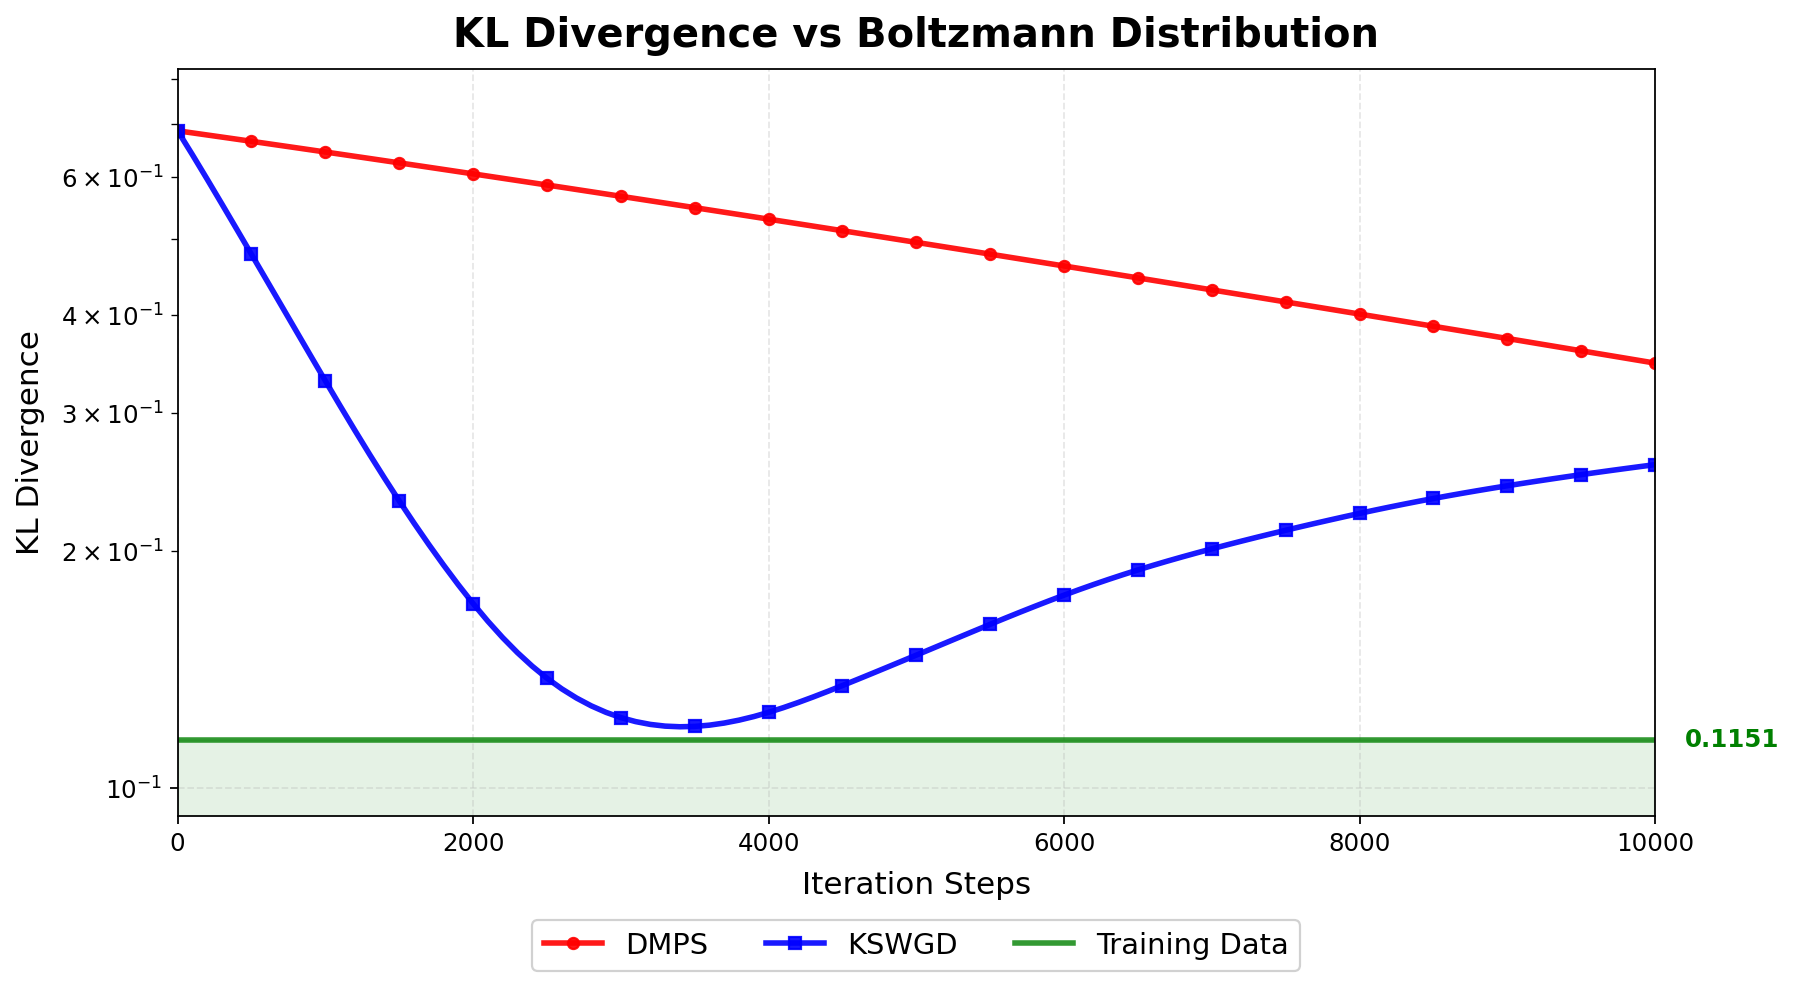

In [37]:
# ============================================================
# Visualization: KL Divergence Comparison (3 methods)
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)

# Plot DMPS and KSWGD
ax.plot(eval_steps, kl_history_dm, 'r-o', linewidth=2.5, markersize=5, 
        markevery=5, label='DMPS', alpha=0.9)
ax.plot(eval_steps, kl_history_sdmd, 'b-s', linewidth=2.5, markersize=5, 
        markevery=5, label='KSWGD', alpha=0.9)

# Plot Training Data baseline as horizontal line (no KL value in legend)
ax.axhline(y=kl_training_data, color='green', linestyle='-', linewidth=2.5, 
           label='Training Data', alpha=0.8)

# Add shaded region below the training data baseline
ax.fill_between(eval_steps, 0, kl_training_data, color='green', alpha=0.1)

# # Mark 1000 steps
# ax.axvline(x=1000, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
# ax.text(1050, ax.get_ylim()[1] * 0.5, '1000 steps', 
#         ha='left', va='center', fontsize=FONT_SMALL, color='gray', rotation=90)

ax.set_xlabel('Iteration Steps', fontsize=FONT_LABEL)
ax.set_ylabel('KL Divergence', fontsize=FONT_LABEL)
ax.set_title('KL Divergence vs Boltzmann Distribution', fontsize=FONT_SUPTITLE, fontweight='bold')
ax.set_xlim(0, n_iter_kswgd)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=FONT_BASE, loc='upper center', bbox_to_anchor=(0.5, -0.12), 
          ncol=3, framealpha=0.9, fancybox=True)
ax.set_yscale('log')

# Set y-axis limits to show more range and add minor ticks
ymin = min(min(kl_history_dm), min(kl_history_sdmd), kl_training_data) * 0.8
ymax = max(max(kl_history_dm), max(kl_history_sdmd)) * 1.2
ax.set_ylim(ymin, ymax)

# Add more y-axis ticks using LogLocator
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
ax.tick_params(axis='y', which='minor', length=3)

# Add Training Data KL value annotation on the y-axis (right side)
ax.annotate(f'{kl_training_data:.4f}', 
            xy=(n_iter_kswgd, kl_training_data), 
            xytext=(n_iter_kswgd * 1.02, kl_training_data),
            fontsize=FONT_TICK, color='green', fontweight='bold',
            va='center', ha='left',
            annotation_clip=False)

fig.tight_layout(pad=LAYOUT_PAD)
plt.show()


In [38]:
# Print summary
print("\n" + "="*80)
print("KL Divergence Summary (vs True Boltzmann Distribution):")
print("="*80)
print(f"{'Method':<25} {'Initial KL':>15} {'Final KL':>15} {'Reduction':>15}")
print("-"*80)
print(f"{'Training Data (X_tar)':<25} {kl_training_data:>15.4f} {kl_training_data:>15.4f} {'(baseline)':>15}")
print(f"{'DMPS':<25} {kl_history_dm[0]:>15.4f} {kl_history_dm[-1]:>15.4f} {kl_history_dm[0]-kl_history_dm[-1]:>15.4f}")
print(f"{'KSWGD(SDMD)':<25} {kl_history_sdmd[0]:>15.4f} {kl_history_sdmd[-1]:>15.4f} {kl_history_sdmd[0]-kl_history_sdmd[-1]:>15.4f}")
print("="*80)
print(f"\nNote: Training Data KL ({kl_training_data:.4f}) represents the empirical baseline.")
print(f"      Lower KL = closer to true Boltzmann distribution pi(x) proportional to exp(-V(x))")
if kl_history_dm[-1] < kl_training_data:
    print(f"\nOK: DMPS final KL ({kl_history_dm[-1]:.4f}) is BETTER than training data!")
if kl_history_sdmd[-1] < kl_training_data:
    print(f"OK: KSWGD final KL ({kl_history_sdmd[-1]:.4f}) is BETTER than training data!")



KL Divergence Summary (vs True Boltzmann Distribution):
Method                         Initial KL        Final KL       Reduction
--------------------------------------------------------------------------------
Training Data (X_tar)              0.1151          0.1151      (baseline)
DMPS                               0.6871          0.3475          0.3396
KSWGD(SDMD)                        0.6871          0.2580          0.4291

Note: Training Data KL (0.1151) represents the empirical baseline.
      Lower KL = closer to true Boltzmann distribution pi(x) proportional to exp(-V(x))


## Key Simulation Parameters Summary

This table summarizes the most important parameters used in the simulation:

| Parameter | Variable Name | Value | Description |
|-----------|--------------|-------|-------------|
| **Initialization** | | | |
| Initial particle count | `n_init_particles` | - | Number of particles sampled initially |
| Gaussian mean | `gaussian_mean` | [0, 0] | Center of Gaussian distribution |
| Gaussian std | `gaussian_std` | - | Standard deviation of Gaussian |
| Filtered particle count | `X_kswgd_init.shape[0]` | - | Particles after filtering (outside wells) |
| **Iteration Settings** | | | |
| Total iterations | `n_iter_kswgd` | - | Total gradient descent steps |
| Step size | `h_kswgd` | - | Gradient descent step size |
| Recording interval | `record_interval` | 100 | Steps between metric recordings |
| **Spectral Settings** | | | |
| Eigenvalue threshold | `eig_threshold` | 0.01 | Threshold for mode selection |
| DM modes retained | `k_modes` | - | Number of diffusion map modes |
| SDMD modes retained | `k_modes_sdmd` | - | Number of Koopman modes |
| **Dictionary Settings** | | | |
| Training samples | `n_samples` | - | Number of training data points |
| Dictionary size | `N_dict_sdmd` | - | Neural network dictionary basis count |
| Data/Dict ratio | `n_samples/N_dict_sdmd` | - | Determines overfitting risk |

In [39]:
# ============================================================
# Print Key Simulation Parameters
# ============================================================

print("="*80)
print("KEY SIMULATION PARAMETERS")
print("="*80)

print("\n1. INITIALIZATION PARAMETERS:")
print("-" * 80)
print(f"   Initial particle count (n_init_particles):     {n_init_particles}")
print(f"   Gaussian distribution mean (gaussian_mean):    {gaussian_mean}")
print(f"   Gaussian distribution std (gaussian_std):      {gaussian_std}")
print(f"   Filtered particle count (X_kswgd_init):        {X_kswgd_init.shape[0]}")
print(f"   Retention rate:                                {100 * X_kswgd_init.shape[0] / n_init_particles:.1f}%")

print("\n2. ITERATION SETTINGS:")
print("-" * 80)
print(f"   Total iterations (n_iter_kswgd):               {n_iter_kswgd}")
print(f"   Step size / learning rate (h_kswgd):           {h_kswgd}")
print(f"   Recording interval (record_interval):          {record_interval}")
print(f"   Total metric recordings:                       {n_records}")

print("\n3. SPECTRAL SETTINGS (MODE SELECTION):")
print("-" * 80)
print(f"   Eigenvalue threshold (eig_threshold):          {eig_threshold}")
print(f"   Mode selection method:                         Threshold-based (NOT truncation)")
print(f"   DM modes retained (k_modes):                   {k_modes}")
print(f"   SDMD modes retained (k_modes_sdmd):            {k_modes_sdmd}")
print(f"   DM skipped modes (n_skip):                     {n_skip} (stationary mode)")

print("\n4. DICTIONARY & DATA SETTINGS:")
print("-" * 80)
print(f"   Training data samples (n_samples):             {n_samples}")
print(f"   Dictionary size (N_dict_sdmd):                 {N_dict_sdmd}")
print(f"   Data/Dictionary ratio:                         {n_samples / N_dict_sdmd:.2f}")
print(f"   Optimal dict size (sqrtn_samples):                ~{int(np.sqrt(n_samples))}")
print(f"   Safe range (0.5sqrtn ~ 2sqrtn):                      {int(0.5*np.sqrt(n_samples))} ~ {int(2*np.sqrt(n_samples))}")

print("\n5. OTHER KEY PARAMETERS:")
print("-" * 80)
print(f"   Kernel bandwidth (epsilon):                    {epsilon:.6f}")
print(f"   Well radius (well_radius):                     {well_radius}")
print(f"   Number of wells:                               {len(well_centers)}")
print(f"   Well centers:                                  {well_centers.tolist()}")

print("\n" + "="*80)


KEY SIMULATION PARAMETERS

1. INITIALIZATION PARAMETERS:
--------------------------------------------------------------------------------
   Initial particle count (n_init_particles):     2000
   Gaussian distribution mean (gaussian_mean):    [0. 0.]
   Gaussian distribution std (gaussian_std):      1.0
   Filtered particle count (X_kswgd_init):        2000
   Retention rate:                                100.0%

2. ITERATION SETTINGS:
--------------------------------------------------------------------------------
   Total iterations (n_iter_kswgd):               10000
   Step size / learning rate (h_kswgd):           0.02
   Recording interval (record_interval):          100
   Total metric recordings:                       101

3. SPECTRAL SETTINGS (MODE SELECTION):
--------------------------------------------------------------------------------
   Eigenvalue threshold (eig_threshold):          0.001
   Mode selection method:                         Threshold-based (NOT truncation)

## Numerical Verification of Assumptions 4.2 and 4.6

This section adds an empirical verification for the two assumptions that matter most for the data-driven convergence result in the paper.

- Assumption 4.2 is checked for fixed truncation ranks $r$ by measuring the empirical spectral tail $\|(I-\widehat{\Pi}_r) f_t\|_{L^2_\pi}$ over time, where $f_t = \rho_t - 1$ and $\rho_t = d\mu_t / d\pi$ is estimated from the KSWGD particles.
- Assumption 4.6 is checked through the operator-error proxy
  $$\widehat{\varepsilon}_r(t) = \frac{|\langle f_t, \widehat{\delta}_r(f_t) \rangle_\pi|}{\|f_t\|_{L^2_\pi}^2}, \qquad \widehat{\delta}_r(f_t) := L\widehat{K}_r f_t - \widehat{\Pi}_r f_t,$$
  where $L = -\Delta + \nabla V \cdot \nabla$ is the exact Langevin generator for the quadruple-well system, and $\widehat{K}_r$ / $\widehat{\Pi}_r$ are built from the learned SDMD eigenfunctions.

Interpretation:
- The primary numerical check for Assumption 4.2 is whether, for a fixed rank $r$, the time-curve $t \mapsto \|(I-\widehat{\Pi}_r) f_t\|_{L^2_\pi}$ stays below an empirical constant $\widehat{\eta}_r := \max_t \|(I-\widehat{\Pi}_r) f_t\|_{L^2_\pi}$.
- The primary numerical check for Assumption 4.6 is whether, for a fixed rank $r$, the time-curve $t \mapsto \widehat{\varepsilon}_r(t)$ stays below an empirical constant $\max_t \widehat{\varepsilon}_r(t)$ and remains small compared with 1.

Note:
- This is an empirical verification, not a theorem-level proof. In particular, $\widehat{\Pi}_r$ is the empirical projector onto the SDMD subspace rather than the unknown exact projector $\Pi_r$ from the paper.
- A supplementary comparison across multiple $r$ values is kept only as a sensitivity analysis; it is not the main logical content of Assumption 4.2.


In [40]:
# ============================================================
# Empirical verification of Assumptions 4.2 and 4.6 for KSWGD
# ============================================================

from scipy.stats import gaussian_kde

print("=" * 80)
print("EMPIRICAL VERIFICATION OF ASSUMPTIONS 4.2 AND 4.6")
print("=" * 80)

# ------------------------------------------------------------
# Design choices
# ------------------------------------------------------------
# 1. Reference measure pi:
#    We use the exact Boltzmann density of the quadruple-well system, since V is known
#    in this notebook.
#
# 2. Current particle law mu_t:
#    We estimate dmu_t/dx with a KDE built from the KSWGD particles X_kswgd_traj_sdmd.
#
# 3. Density fluctuation:
#    rho_t = dmu_t / dpi, and f_t = rho_t - 1.
#
# 4. Assumption 4.2:
#    We approximate ||(I - Pi_r) f_t||_{L2_pi} by projecting f_t onto the span of the
#    first r learned SDMD eigenfunctions and measuring the residual. The main check
#    is: for a fixed r, does the whole time-curve stay below one empirical bound?
#
# 5. Assumption 4.6:
#    We build a proxy
#        delta_hat_r(f_t) = L K_hat_r f_t - Pi_hat_r f_t
#    where:
#      - L = -Delta + grad(V) dot grad is the exact positive Langevin generator
#      - K_hat_r and Pi_hat_r are constructed from the first r SDMD eigenfunctions
#    and evaluate
#        eps_hat_r(t) = |<f_t, delta_hat_r(f_t)>_pi| / ||f_t||_{L2_pi}^2.
#    Since the approximating object is fixed once r is fixed, the displayed summary
#    for Assumption 4.6 focuses on the empirical uniform-in-time envelope
#        hat_eps_r = sup_t eps_hat_r(t)
#    as a function of r. The time-resolved eps_hat_r(t) values are used only as an
#    intermediate computation of this empirical envelope.
#
# Caveat:
#    This is a finite-horizon empirical proxy check, not a theorem-level proof.
#    The main differences from the exact assumptions are:
#      - Pi_r is replaced by the learned SDMD projector Pi_hat_r,
#      - mu_t is KDE-smoothed to obtain a density proxy,
#      - maxima are taken over inspected snapshots rather than all t >= 0,
#      - L is applied on a finite grid through strong-form finite differences.

assump_seed = 123
rng = np.random.default_rng(assump_seed)

# Inspect a moderate number of time points so the cell remains practical to run.
eval_step_stride = 500
eval_steps_assump = np.arange(0, n_iter_kswgd + 1, eval_step_stride, dtype=int)
if eval_steps_assump[-1] != n_iter_kswgd:
    eval_steps_assump = np.append(eval_steps_assump, n_iter_kswgd)

# Truncation ranks to test.
available_sdmd_modes = eigvecs_K_sdmd.shape[1] - n_skip
r_values_default = [5, 10, 20, 30, 40]
r_values = [r for r in r_values_default if r <= available_sdmd_modes]
r_main = int(k_modes_sdmd) if 'k_modes_sdmd' in globals() else r_values[-1]
r_main = max(1, min(r_main, available_sdmd_modes))
r_values_all = sorted(set(r_values + [r_main]))
if not r_values_all:
    raise RuntimeError("No valid truncation rank is available for Assumption 4.2 / 4.6 verification.")

# ------------------------------------------------------------
# Assumption 4.2 uses an empirical L2(pi) inner product
# approximated by stationary training samples.
# ------------------------------------------------------------
n_mu_eval = min(2500, X_tar.shape[0])
mu_eval_idx = rng.choice(X_tar.shape[0], size=n_mu_eval, replace=False)
X_mu_eval = X_tar[mu_eval_idx]
pi_mu_eval = potential.stationary_density(X_mu_eval)
phi_mu_all = np.real(eigvecs_K_sdmd[mu_eval_idx, :])

# ------------------------------------------------------------
# Assumption 4.6 uses the exact generator on a regular grid.
# ------------------------------------------------------------
grid_n = 70
x_fd = np.linspace(-2.0, 2.0, grid_n)
y_fd = np.linspace(-2.0, 2.0, grid_n)
X_fd, Y_fd = np.meshgrid(x_fd, y_fd)
grid_points = np.column_stack([X_fd.ravel(), Y_fd.ravel()])
dx = x_fd[1] - x_fd[0]
dy = y_fd[1] - y_fd[0]
area_element = dx * dy

pi_grid = potential.stationary_density(X_fd, Y_fd)
pi_weights = pi_grid.ravel() * area_element

gradV_grid = potential.grad_V(grid_points)
gradV_x = gradV_grid[:, 0].reshape(grid_n, grid_n)
gradV_y = gradV_grid[:, 1].reshape(grid_n, grid_n)

# Evaluate learned SDMD eigenfunctions on the finite-difference grid.
phi_grid_all = np.real(solver.eigenfunctions(grid_points))

# Convert Koopman eigenvalues to positive Langevin-generator eigenvalues:
#   eta_k = (1 - lambda_k) / dt
eta_all = (1.0 - np.real(eigvals_K_sdmd)) / dt

print(f"Evaluation steps: {eval_steps_assump.tolist()}")
print(f"Empirical-mu sample size for Assumption 4.2: {n_mu_eval}")
print(f"Finite-difference grid for Assumption 4.6: {grid_n} x {grid_n}")
print(f"Main rank used in KSWGD / main assumption check: r = {r_main}")
print(f"Supplementary ranks tested: {r_values_all}")
print(f"Available SDMD modes after skipping stationary mode: {available_sdmd_modes}")
print(f"Total SDMD dictionary dimension before skip: {eigvecs_K_sdmd.shape[1]}")


def safe_kde_evaluate(particles, query_points):
    """Evaluate KDE robustly, with a small-noise fallback if covariance is singular."""
    try:
        kde = gaussian_kde(particles.T, bw_method='scott')
        values = kde(query_points.T)
    except np.linalg.LinAlgError:
        noisy_particles = particles + 1e-4 * np.random.randn(*particles.shape)
        kde = gaussian_kde(noisy_particles.T, bw_method='scott')
        values = kde(query_points.T)
    return np.maximum(values, 1e-14)


def sample_projector_residual(f_values, basis_values):
    """
    Empirical L2(pi) projection residual using stationary samples X_mu_eval.
    Since X_mu_eval ~ pi, the L2(pi) inner product is approximated by the sample average.
    """
    gram = (basis_values.T @ basis_values) / basis_values.shape[0]
    gram = gram + 1e-10 * np.eye(gram.shape[0])
    rhs = (basis_values.T @ f_values) / basis_values.shape[0]
    coeff = np.linalg.solve(gram, rhs)
    f_proj = basis_values @ coeff
    residual = f_values - f_proj
    return np.sqrt(np.mean(residual ** 2))


def weighted_projector(values, basis_values, weights):
    """
    Weighted L2(pi) projector on a grid, where weights approximate pi(x) dx.
    """
    weighted_basis = basis_values * weights[:, None]
    gram = basis_values.T @ weighted_basis
    gram = gram + 1e-10 * np.eye(gram.shape[0])
    rhs = basis_values.T @ (weights * values)
    coeff = np.linalg.solve(gram, rhs)
    projection = basis_values @ coeff
    return coeff, projection


def apply_positive_langevin_generator(u_grid, grad_x, grad_y, dx_val, dy_val):
    """
    Apply the positive Langevin generator
        L = -Delta + grad(V) dot grad
    to a scalar field on a regular 2D grid.
    """
    du_dx = np.gradient(u_grid, dx_val, axis=1)
    du_dy = np.gradient(u_grid, dy_val, axis=0)
    d2u_dx2 = np.gradient(du_dx, dx_val, axis=1)
    d2u_dy2 = np.gradient(du_dy, dy_val, axis=0)
    laplace_u = d2u_dx2 + d2u_dy2
    return -laplace_u + grad_x * du_dx + grad_y * du_dy


# Storage
tail_history = {r: [] for r in r_values_all}
eps46_history = {r: [] for r in r_values_all}

assump_iter = progress_range(eval_steps_assump, desc='Assumption diagnostics', unit='step', dynamic_ncols=True, mininterval=1.0)
for step in assump_iter:
    particles_t = X_kswgd_traj_sdmd[:, :, step]

    # KDE evaluations for sample-based and grid-based diagnostics.
    q_mu_eval = safe_kde_evaluate(particles_t, X_mu_eval)
    q_grid_eval = safe_kde_evaluate(particles_t, grid_points)

    # ---- Build f_t on stationary samples (Assumption 4.2) ----
    rho_mu = q_mu_eval / np.maximum(pi_mu_eval, 1e-14)
    rho_mu = rho_mu / np.mean(rho_mu)
    f_mu = rho_mu - 1.0

    # ---- Build f_t on the finite-difference grid (Assumption 4.6) ----
    rho_grid = q_grid_eval / np.maximum(pi_grid.ravel(), 1e-14)
    rho_grid = rho_grid / np.sum(rho_grid * pi_weights)
    f_grid = rho_grid - 1.0
    f_norm_sq = np.sum((f_grid ** 2) * pi_weights)

    for r in r_values_all:
        # ========================================================
        # Assumption 4.2: spectral tail proxy
        # ========================================================
        basis_mu = phi_mu_all[:, n_skip:n_skip + r]
        tail_norm = sample_projector_residual(f_mu, basis_mu)
        tail_history[r].append(tail_norm)

        # ========================================================
        # Assumption 4.6: operator approximation error proxy
        # ========================================================
        basis_grid = phi_grid_all[:, n_skip:n_skip + r]
        eta_r = np.maximum(eta_all[n_skip:n_skip + r], 1e-8)

        coeff_r, proj_r = weighted_projector(f_grid, basis_grid, pi_weights)
        k_hat_f_r = basis_grid @ (coeff_r / eta_r)
        l_k_hat_f_r = apply_positive_langevin_generator(
            k_hat_f_r.reshape(grid_n, grid_n),
            gradV_x,
            gradV_y,
            dx,
            dy,
        ).ravel()

        delta_hat_r = l_k_hat_f_r - proj_r
        eps46_inner_abs_t = np.abs(np.sum(f_grid * delta_hat_r * pi_weights))
        eps46_t = eps46_inner_abs_t / max(f_norm_sq, 1e-14)
        eps46_history[r].append(eps46_t)

    if hasattr(assump_iter, 'set_postfix'):
        assump_iter.set_postfix(step=int(step), refresh=False)

for r in r_values_all:
    tail_history[r] = np.array(tail_history[r])
    eps46_history[r] = np.array(eps46_history[r])

eta_hat_all = np.array([np.max(tail_history[r]) for r in r_values_all])
eps_hat_all = np.array([np.max(eps46_history[r]) for r in r_values_all])
alpha_hat_all = 1.0 - eps_hat_all
theory_floor_all = eta_hat_all ** 2 / np.maximum(alpha_hat_all, 1e-8)

eta_hat_main = np.max(tail_history[r_main])
eps_hat_main = np.max(eps46_history[r_main])
alpha_hat_main = 1.0 - eps_hat_main


EMPIRICAL VERIFICATION OF ASSUMPTIONS 4.2 AND 4.6
Evaluation steps: [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]
Empirical-mu sample size for Assumption 4.2: 2500
Finite-difference grid for Assumption 4.6: 70 x 70
Main rank used in KSWGD / main assumption check: r = 49
Supplementary ranks tested: [5, 10, 20, 30, 40, 49]
Available SDMD modes after skipping stationary mode: 49
Total SDMD dictionary dimension before skip: 50


Assumption diagnostics: 100%|██████████| 21/21 [00:06<00:00,  3.08step/s, step=1e+4]


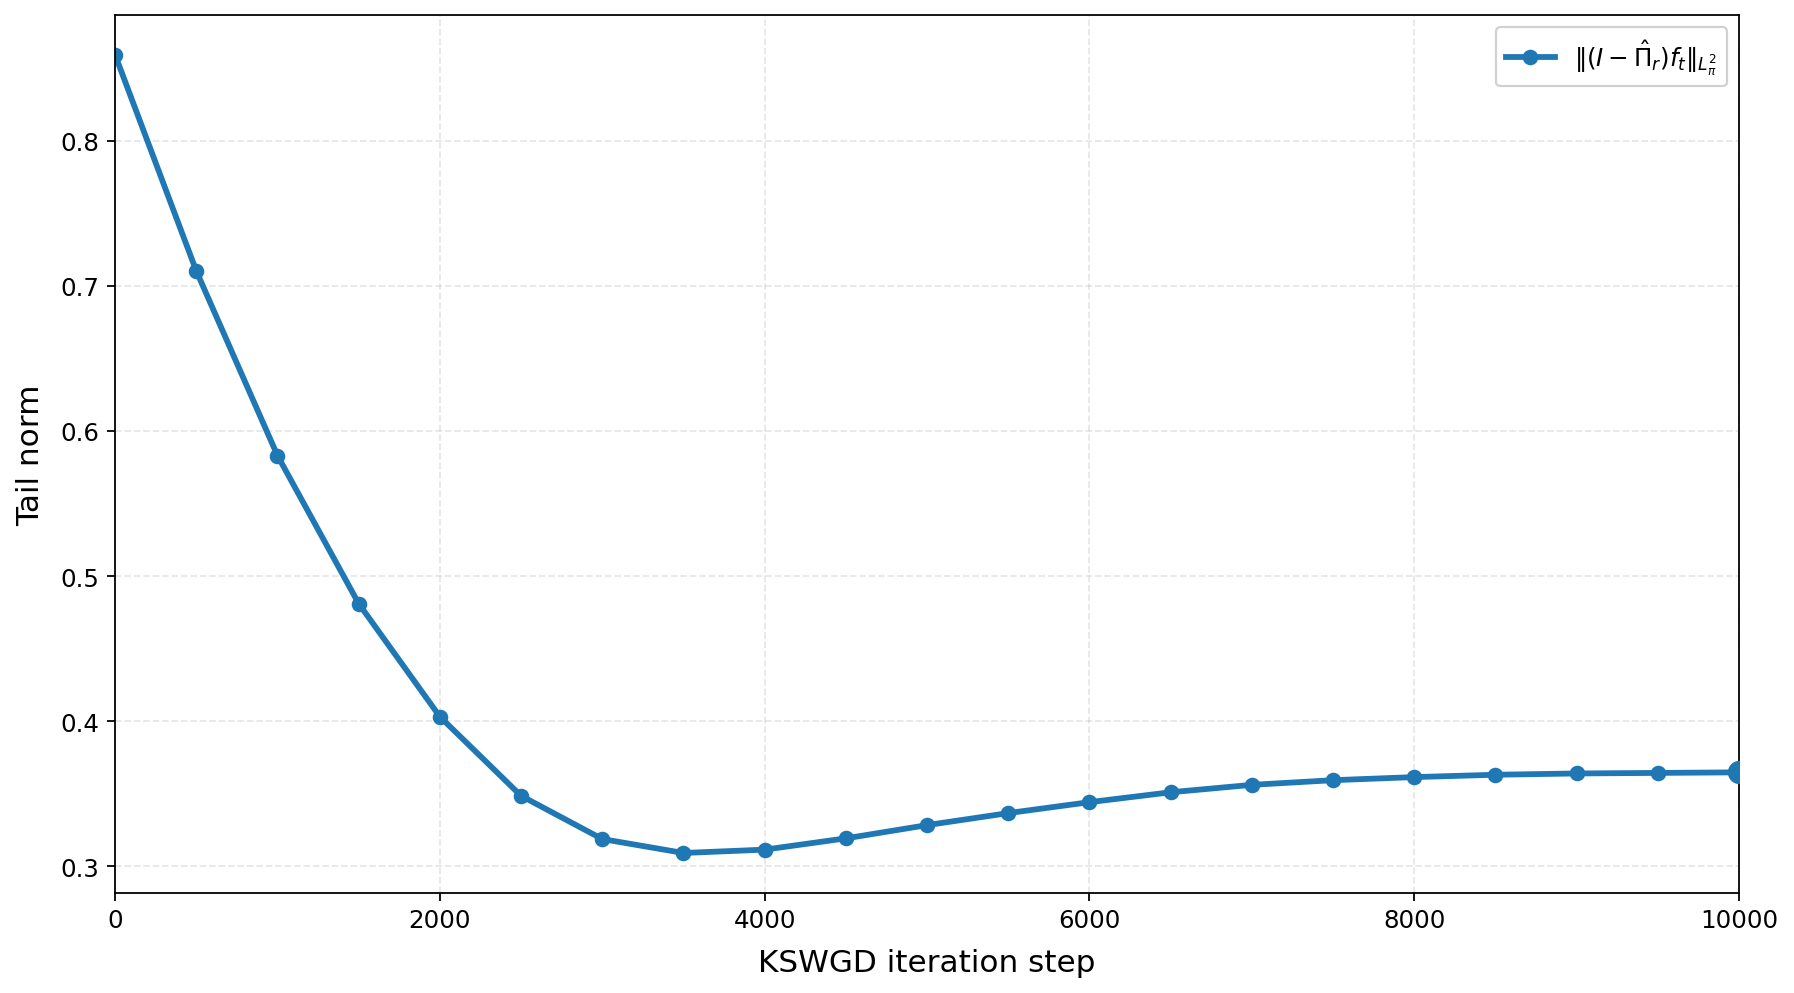

Caption text:
Assumption 4.2: fixed-r empirical spectral tail over time.
--------------------------------------------------------------------------------


In [41]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)
ax.plot(
    eval_steps_assump,
    tail_history[r_main],
    color='#1f77b4',
    linewidth=2.6,
    marker='o',
    markersize=6.0,
    label=r'$\|(I - \hat{\Pi}_r) f_t\|_{L^2_\pi}$',
)
ax.scatter(eval_steps_assump[-1], tail_history[r_main][-1], color='#1f77b4', s=90, zorder=5)
finalize_axis(ax, 'KSWGD iteration step', 'Tail norm', xlim=(0, n_iter_kswgd))
fig.tight_layout(pad=LAYOUT_PAD)
plt.show()
print_caption('Assumption 4.2: fixed-r empirical spectral tail over time.')

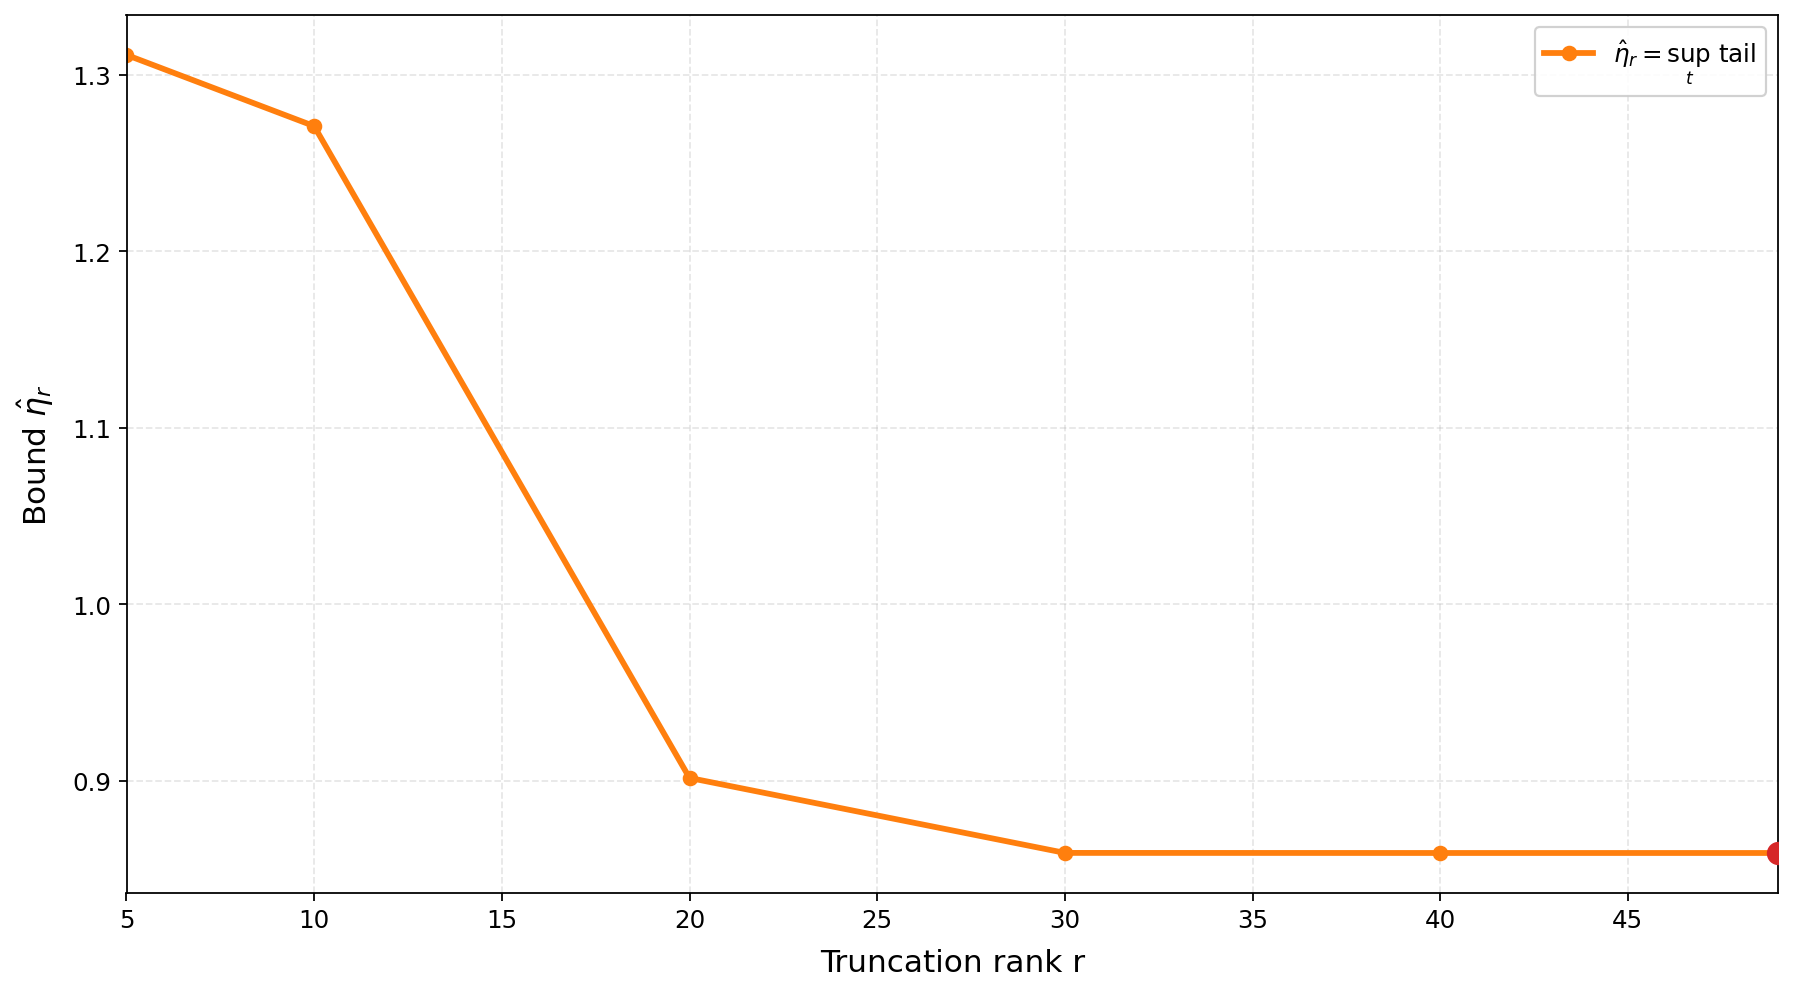

Caption text:
Assumption 4.2: empirical upper bound $\hat{\eta}_r$ across truncation ranks.
--------------------------------------------------------------------------------


In [42]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)
ax.plot(
    r_values_all,
    eta_hat_all,
    color='#ff7f0e',
    linewidth=2.6,
    marker='o',
    markersize=6.0,
    label=r'$\hat{\eta}_r=\sup_t$ tail',
)
ax.scatter([r_main], [eta_hat_main], color='#d62728', s=90, zorder=5)
finalize_axis(ax, 'Truncation rank r', r'Bound $\hat{\eta}_r$')
fig.tight_layout(pad=LAYOUT_PAD)
plt.show()
print_caption('Assumption 4.2: empirical upper bound $\\hat{\\eta}_r$ across truncation ranks.')

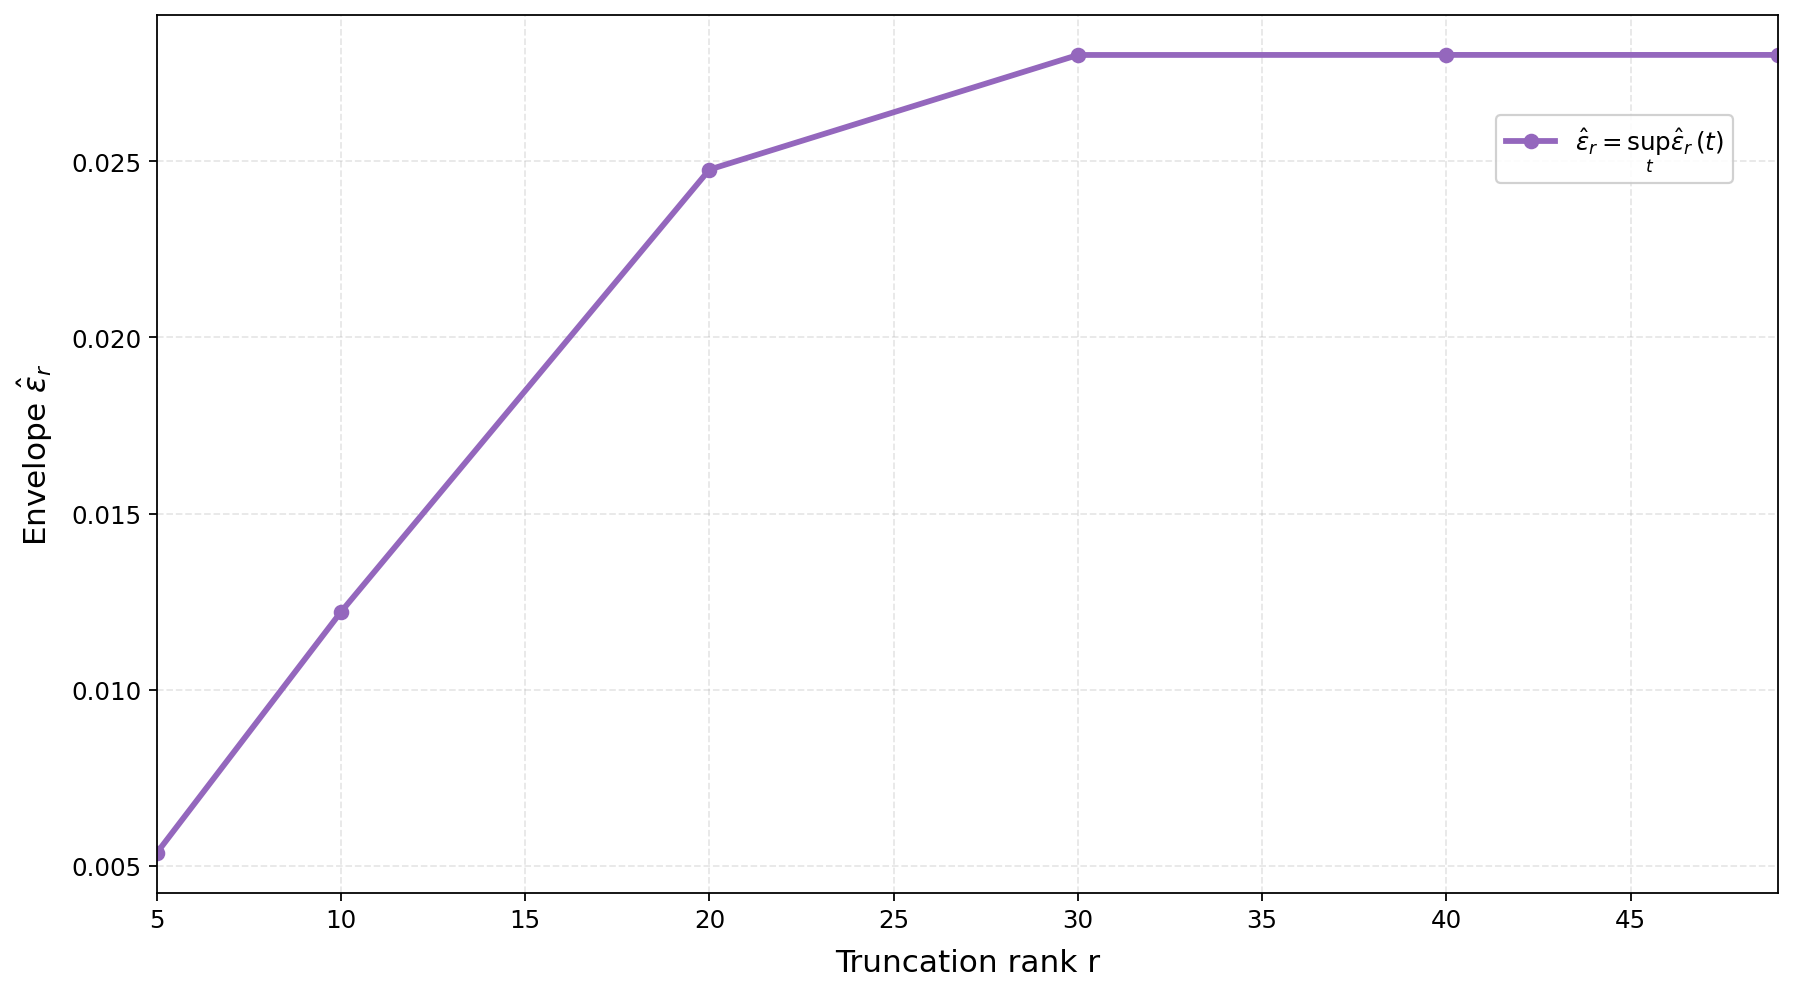

Caption text:
Assumption 4.6: empirical uniform-in-time operator-mismatch envelope $\hat{\varepsilon}_r = \sup_t \hat{\varepsilon}_r(t)$ across truncation ranks.
--------------------------------------------------------------------------------


In [43]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)
ax.plot(
    r_values_all,
    eps_hat_all,
    color='#9467bd',
    linewidth=2.6,
    marker='o',
    markersize=6.0,
    label=r'$\hat{\varepsilon}_r = \sup_t \hat{\varepsilon}_r(t)$',
)
finalize_axis(
    ax,
    'Truncation rank r',
    r'Envelope $\hat{\varepsilon}_r$',
    legend_kwargs=dict(loc='upper right', bbox_to_anchor=(0.98, 0.90), fontsize=FONT_LEGEND, framealpha=0.9),
)
fig.tight_layout(pad=LAYOUT_PAD)
plt.show()
print_caption('Assumption 4.6: empirical uniform-in-time operator-mismatch envelope $\\hat{\\varepsilon}_r = \\sup_t \\hat{\\varepsilon}_r(t)$ across truncation ranks.')

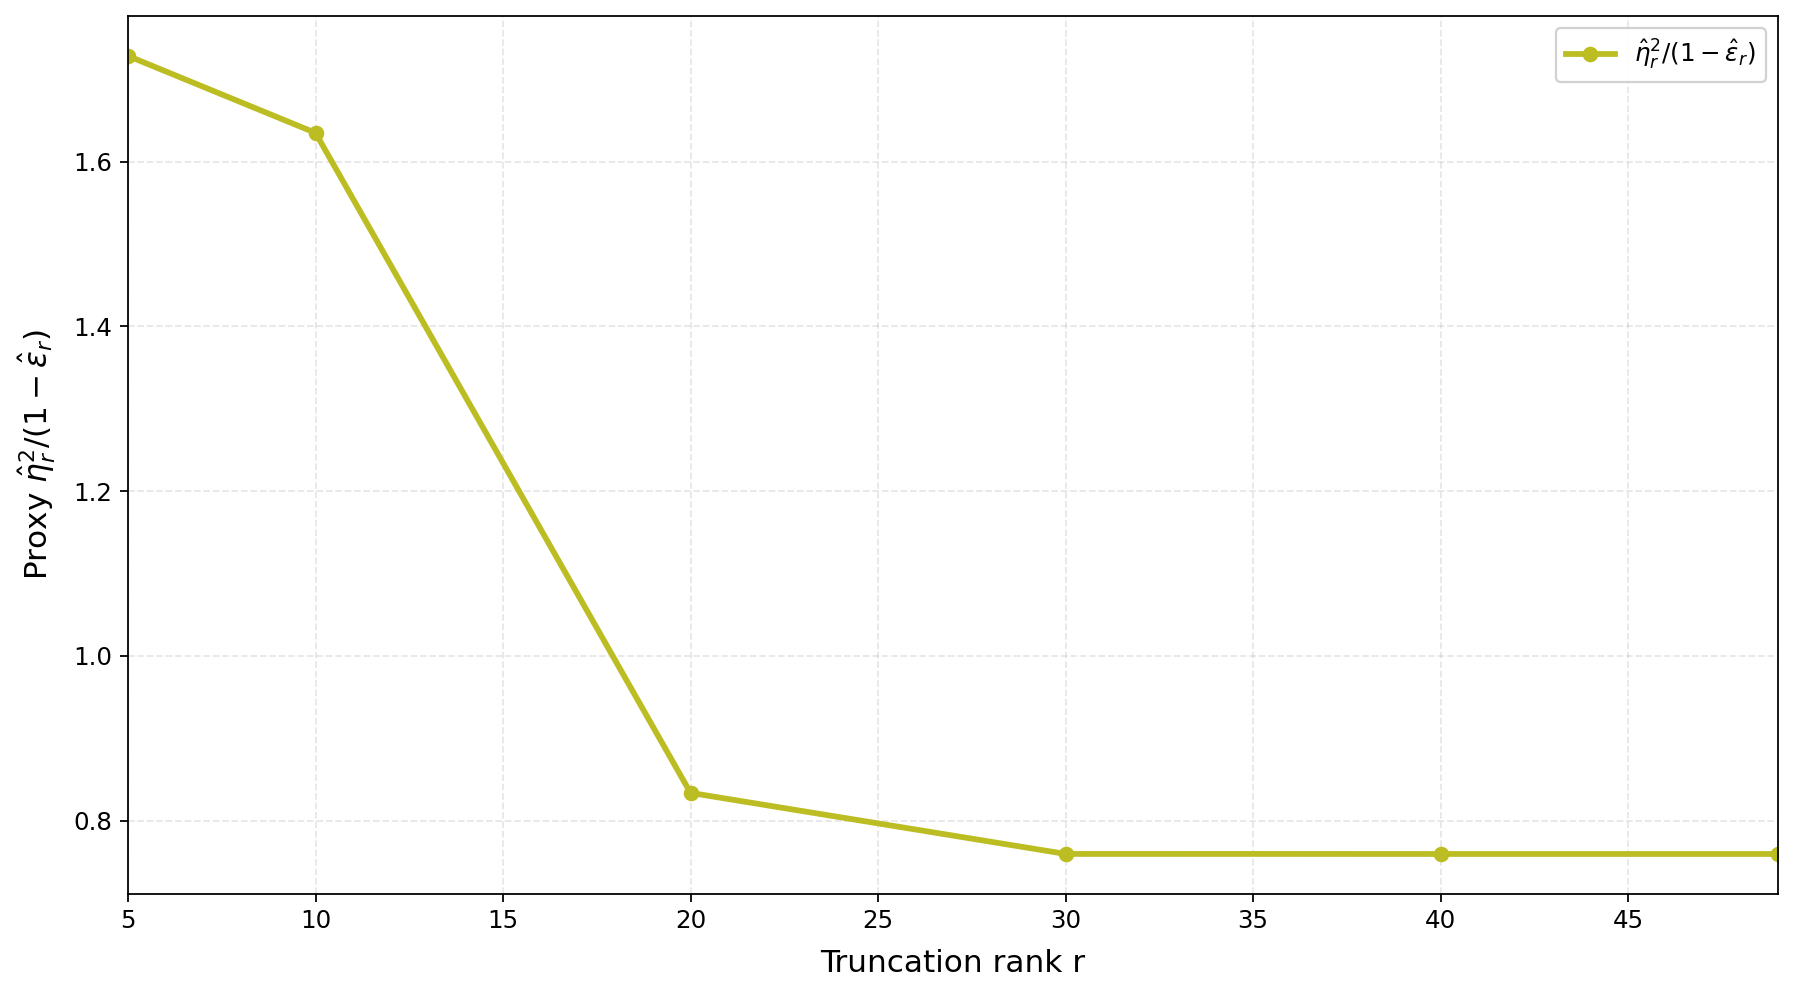

Caption text:
Theorem 4.8 surrogate bias floor $\hat{\eta}_r^2 / (1 - \hat{\varepsilon}_r)$ across truncation ranks.
--------------------------------------------------------------------------------


In [44]:
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE_WIDE)
ax.plot(
    r_values_all,
    theory_floor_all,
    color='#bcbd22',
    linewidth=2.6,
    marker='o',
    markersize=6.0,
    label=r'$\hat{\eta}_r^2 / (1 - \hat{\varepsilon}_r)$',
)
finalize_axis(
    ax,
    'Truncation rank r',
    r'Proxy $\hat{\eta}_r^2 / (1 - \hat{\varepsilon}_r)$',
)
fig.tight_layout(pad=LAYOUT_PAD)
plt.show()
print_caption('Theorem 4.8 surrogate bias floor $\\hat{\\eta}_r^2 / (1 - \\hat{\\varepsilon}_r)$ across truncation ranks.')

In [45]:
# ------------------------------------------------------------
# Text summary
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("ASSUMPTION 4.2: EMPIRICAL SPECTRAL-TAIL SUMMARY")
print("=" * 80)
print(f"Main fixed-r check: r = {r_main}")
print(f"Empirical upper bound hat_eta_r = max_t ||(I - Pi_hat_r) f_t|| = {eta_hat_main:.6f}")
for r in r_values_all:
    print(
        f"r = {r:2d} | "
        f"sup_t tail = {np.max(tail_history[r]):.6f} | "
        f"mean tail = {np.mean(tail_history[r]):.6f} | "
        f"final tail = {tail_history[r][-1]:.6f}"
    )

print("\nInterpretation:")
print("  - The main numerical question is whether the fixed-r time curve stays below")
print("    one empirical constant hat_eta_r; that is the direct analogue of the")
print("    supremum-over-time statement in Assumption 4.2 over the inspected window.")
print("  - The comparison across multiple r values is only a supplementary sensitivity")
print("    study and is not itself the assumption.")

print("\n" + "=" * 80)
print("ASSUMPTION 4.6: EMPIRICAL OPERATOR-ERROR SUMMARY")
print("=" * 80)
print(f"Main fixed-r check: r = {r_main}")
print(f"Empirical upper bound max_t eps_hat_r(t) = {eps_hat_main:.6e}")
print(f"Alpha proxy 1 - max_t eps_hat_r(t) = {alpha_hat_main:.6e}")
for r in r_values_all:
    print(
        f"r = {r:2d} | "
        f"sup_t eps_hat = {np.max(eps46_history[r]):.6e} | "
        f"mean eps_hat = {np.mean(eps46_history[r]):.6e} | "
        f"final eps_hat = {eps46_history[r][-1]:.6e}"
    )

print("\nInterpretation:")
print("  - For each fixed rank r, the learned operator approximation is fixed as well.")
print("  - The displayed quantity for Assumption 4.6 is the empirical envelope")
print("        hat_eps_r = sup_t eps_hat_r(t),")
print("    where eps_hat_r(t) = |<f_t, delta_hat_r(f_t)>_pi| / ||f_t||_L2(pi)^2.")
print("  - If the third plot rises with r and then saturates, that usually means later")
print("    SDMD modes reduce truncation bias but introduce additional operator-approximation")
print("    error or numerical noise; after some rank, that mismatch stops changing much.")
print("  - The fourth plot is the empirical proxy of the bias-floor term")
print("        eta_r^2 / (1 - eps_r)")
print("    appearing in Theorem 4.8, obtained by replacing eta_r and eps_r with their")
print("    empirical counterparts hat_eta_r and hat_eps_r.")
print("  - Smaller values in the fourth plot mean a better trade-off between truncation")
print("    error and operator-approximation error at that rank.")
print(f"  - Main-r theory floor surrogate hat_eta_r^2 / (1 - hat_eps_r): {eta_hat_main**2 / max(alpha_hat_main, 1e-8):.6e}")

print("\nFinite-horizon caveat:")
print("  - Maxima are taken over inspected snapshots only, not over all t >= 0.")
print("  - q_t is KDE-smoothed from particles, so rho_t is an empirical density proxy.")
print("  - Pi_hat_r is the learned SDMD projector, not the exact projector Pi_r from the theorem.")
print("  - L is applied on a finite grid via strong-form finite differences.")
print("=" * 80)



ASSUMPTION 4.2: EMPIRICAL SPECTRAL-TAIL SUMMARY
Main fixed-r check: r = 49
Empirical upper bound hat_eta_r = max_t ||(I - Pi_hat_r) f_t|| = 0.859191
r =  5 | sup_t tail = 1.311193 | mean tail = 0.571131 | final tail = 0.568167
r = 10 | sup_t tail = 1.270855 | mean tail = 0.539997 | final tail = 0.502689
r = 20 | sup_t tail = 0.901696 | mean tail = 0.431285 | final tail = 0.401324
r = 30 | sup_t tail = 0.859237 | mean tail = 0.406500 | final tail = 0.364700
r = 40 | sup_t tail = 0.859191 | mean tail = 0.406487 | final tail = 0.364692
r = 49 | sup_t tail = 0.859191 | mean tail = 0.406487 | final tail = 0.364692

Interpretation:
  - The main numerical question is whether the fixed-r time curve stays below
    one empirical constant hat_eta_r; that is the direct analogue of the
    supremum-over-time statement in Assumption 4.2 over the inspected window.
  - The comparison across multiple r values is only a supplementary sensitivity
    study and is not itself the assumption.

ASSUMPTION 